# **Optimized and Explainable Machine Learning for Coconut Fiber Concrete Strength Using SHAP, PDP, and ICE**

**Descriptive Analysis**

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# ==============================
# 1. Load dataset and saved split
# ==============================
df = pd.read_excel("Coconut fiber data.xlsx")

train_idx = np.load("train_idx.npy")
test_idx = np.load("test_idx.npy")

# Training/development dataset only
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Total samples:", len(df))
print("Training samples:", len(train_df))
print("Locked test samples:", len(test_df))

# Optional: verify no overlap between train and test indices
overlap = set(train_idx).intersection(set(test_idx))
print("Index overlap between train and test:", len(overlap))

# Optional: verify source separation, if Source column exists
if "Source" in df.columns:
    train_sources = set(train_df["Source"].unique())
    test_sources = set(test_df["Source"].unique())
    source_overlap = train_sources.intersection(test_sources)

    print("Training sources:", len(train_sources))
    print("Test sources:", len(test_sources))
    print("Overlapping sources:", len(source_overlap))
    print("Overlapping source names:", source_overlap)


# ======================================
# 2. Select variables for revised Table 2
# ======================================
columns_for_table = [
    "Cement (kg/m³)",
    "Fiber Length (mm)",
    "Fiber (%)",
    "NCA (kg/m³)",
    "RCA (%)",
    "FA (kg/m³)",
    "Water (kg/m³)",
    "Age (days)",
    "Compressive Strength (MPa)"
]

# Keep only columns that exist in the file
columns_for_table = [col for col in columns_for_table if col in train_df.columns]

units = {
    "Cement (kg/m³)": "kg/m³",
    "Fiber Length (mm)": "mm",
    "Fiber (%)": "%",
    "NCA (kg/m³)": "kg/m³",
    "RCA (%)": "%",
    "FA (kg/m³)": "kg/m³",
    "Water (kg/m³)": "kg/m³",
    "Age (days)": "Days",
    "Compressive Strength (MPa)": "MPa"
}

display_names = {
    "Cement (kg/m³)": "Cement",
    "Fiber Length (mm)": "Fiber Length",
    "Fiber (%)": "Fiber Content",
    "NCA (kg/m³)": "NCA",
    "RCA (%)": "RCA",
    "FA (kg/m³)": "FA",
    "Water (kg/m³)": "Water",
    "Age (days)": "Age",
    "Compressive Strength (MPa)": "CS"
}


# ======================================
# 3. Function for mode and range
# ======================================
def get_mode(series):
    mode_values = series.mode(dropna=True)
    if len(mode_values) == 0:
        return np.nan
    return mode_values.iloc[0]

def format_range(series):
    return f"{series.min():.2f}–{series.max():.2f}"


# ======================================
# 4. Compute descriptive statistics
# ======================================
rows = []

for col in columns_for_table:
    s = pd.to_numeric(train_df[col], errors="coerce").dropna()

    rows.append({
        "Parameters": display_names.get(col, col),
        "Unit": units.get(col, ""),
        "Range": format_range(s),
        "Mean": s.mean(),
        "Median": s.median(),
        "Mode": get_mode(s),
        "Std": s.std(ddof=1),
        "Variance": s.var(ddof=1),
        "Skewness": s.skew(),
        "Kurtosis": s.kurt()
    })

table2_train = pd.DataFrame(rows)

# Round numeric columns
numeric_cols = ["Mean", "Median", "Mode", "Std", "Variance", "Skewness", "Kurtosis"]
table2_train[numeric_cols] = table2_train[numeric_cols].round(2)

# Show table
display(table2_train)


# ======================================
# 5. Export revised Table 2
# ======================================
output_file = "Table_2_Training_Set_Descriptive_Statistics.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    table2_train.to_excel(writer, sheet_name="Table 2 Training EDA", index=False)

print(f"Saved revised Table 2 to: {output_file}")

Total samples: 586
Training samples: 410
Locked test samples: 176
Index overlap between train and test: 0


,Parameters,Unit,Range,Mean,Median,Mode,Std,Variance,Skewness,Kurtosis
0,Cement,kg/m³,255.00–550.00,406.82,400.00,320.0,78.59,6175.93,0.09,-1.29
1,Fiber Length,mm,0.00–200.00,38.25,35.00,50.0,33.99,1155.17,3.17,12.72
2,Fiber Content,%,0.00–12.00,1.95,1.50,1.0,1.82,3.32,1.69,4.78
3,NCA,kg/m³,0.00–1400.00,942.47,1075.00,1171.2,358.93,128830.51,-1.13,0.29
4,RCA,%,0.00–10.00,1.24,0.00,0.0,2.72,7.39,2.42,4.78
5,FA,kg/m³,560.00–1052.00,752.37,710.40,710.4,121.04,14649.78,0.62,-0.16
6,Water,kg/m³,160.00–300.00,196.49,180.00,175.0,34.17,1167.92,1.56,1.85
7,Age,Days,3.00–546.00,29.19,28.00,28.0,54.95,3019.50,6.56,50.28
8,CS,MPa,10.00–86.30,31.77,27.25,30.0,15.99,255.73,1.48,1.76


Saved revised Table 2 to: Table_2_Training_Set_Descriptive_Statistics.xlsx


Total samples: 586
Training/development samples: 410
Locked test samples: 176
Index overlap: 0


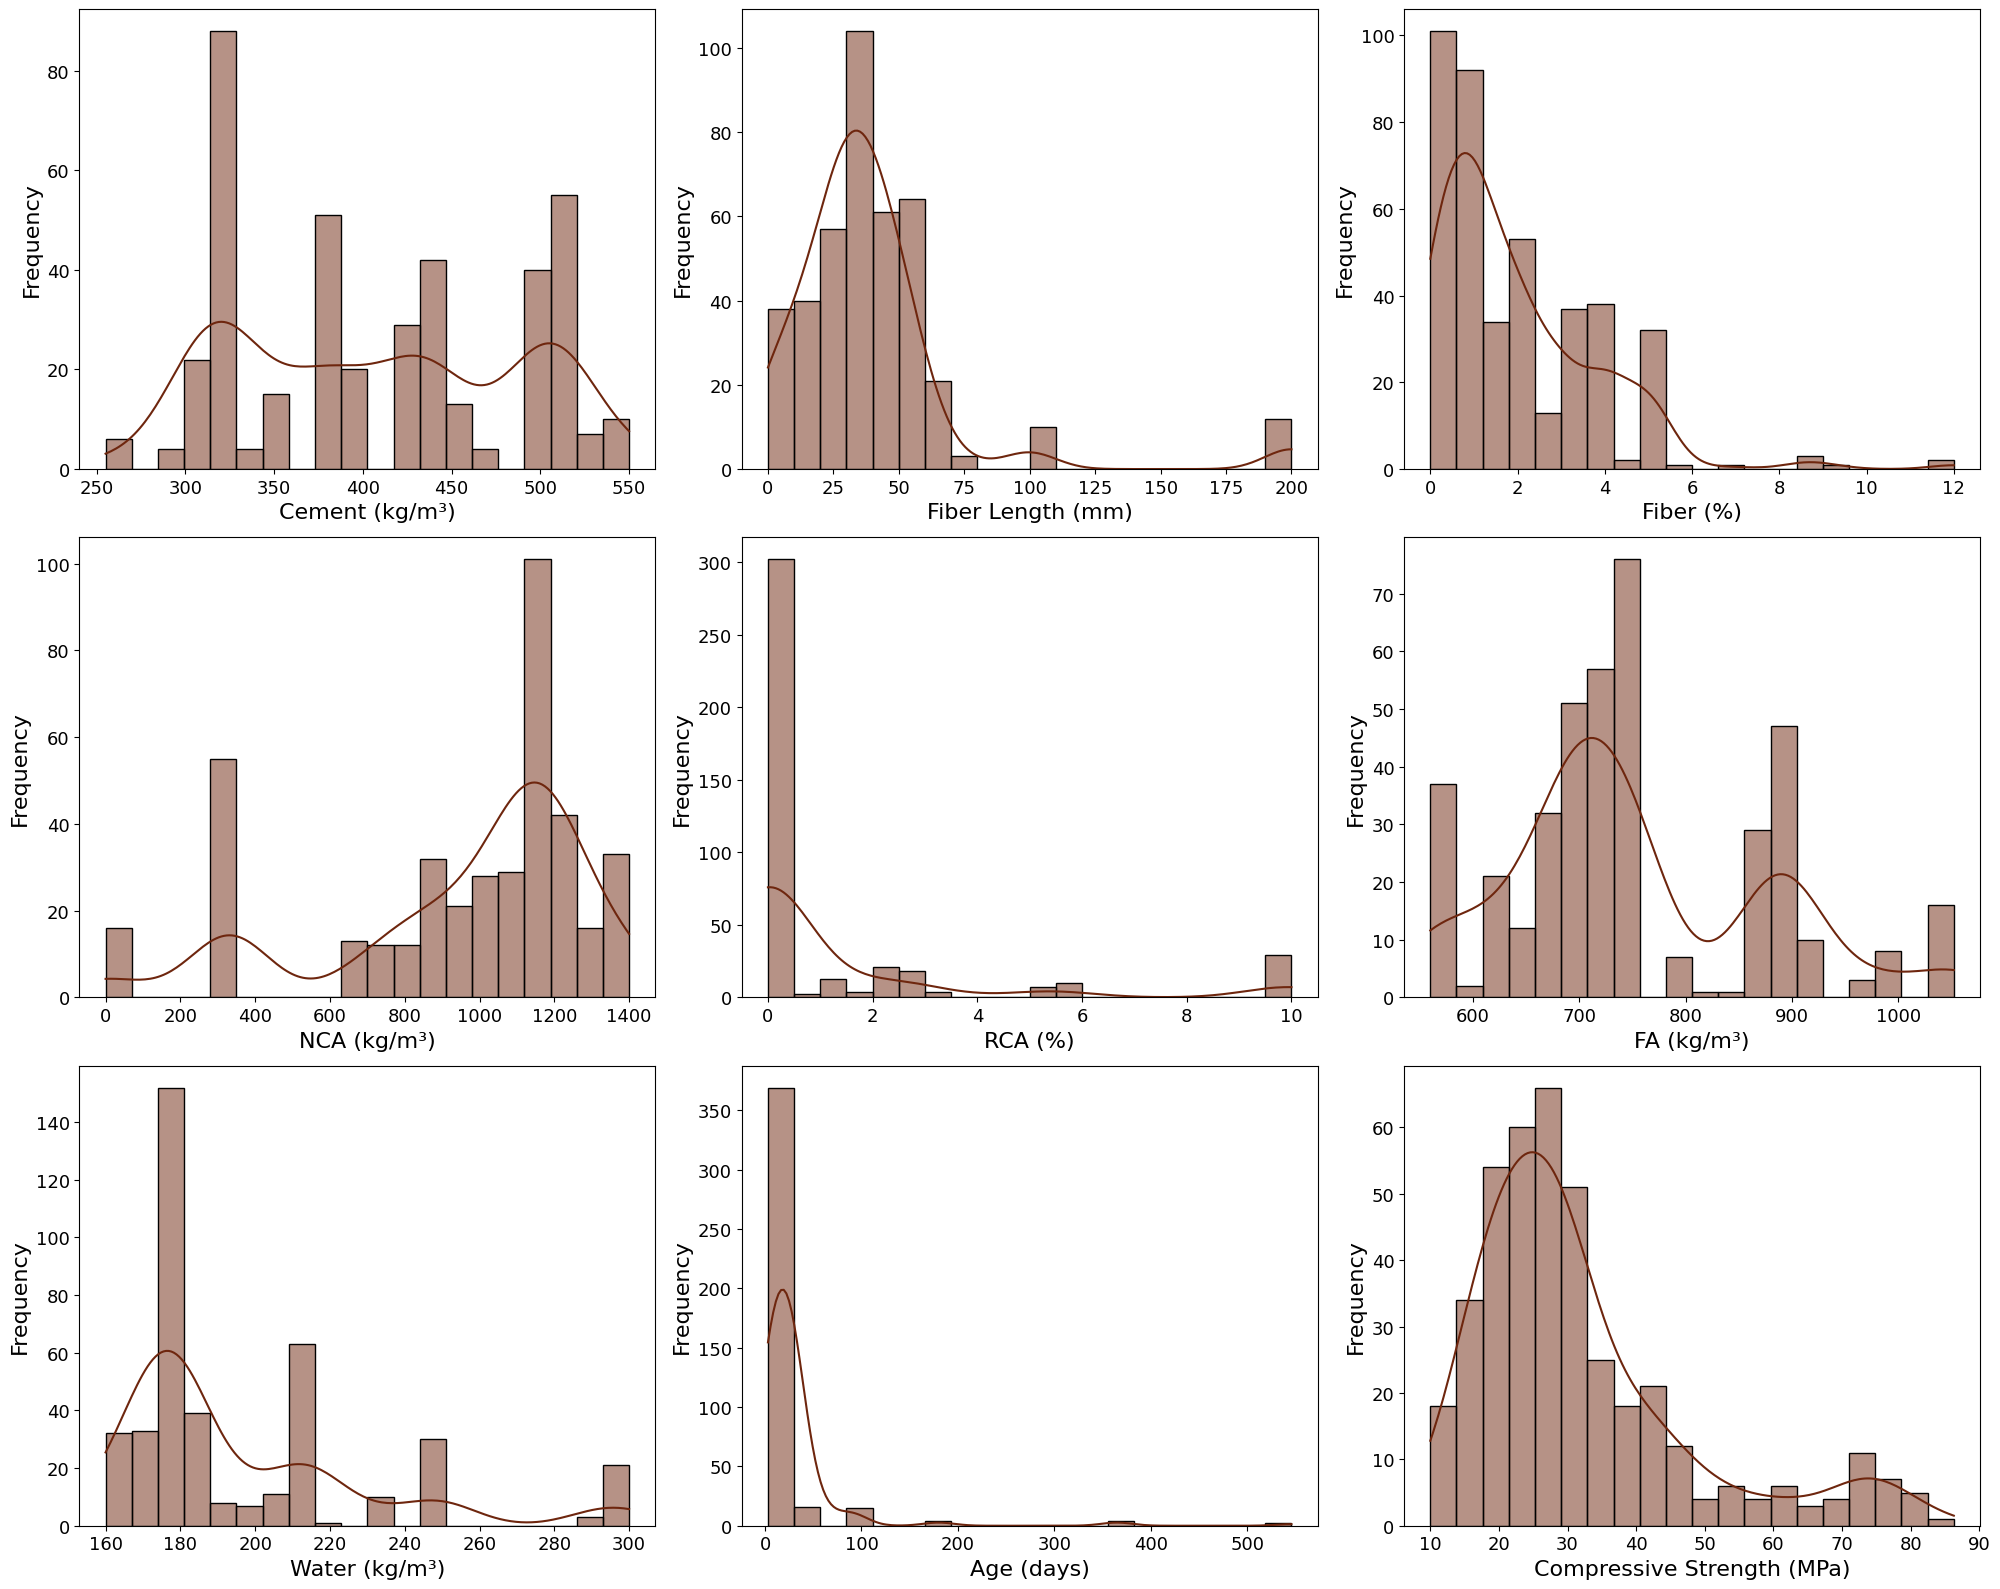

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1. Load dataset and train index
# ==============================
data = pd.read_excel("Coconut fiber data.xlsx")

train_idx = np.load("train_idx.npy")
test_idx = np.load("test_idx.npy")

# Use training/development set only
train_data = data.iloc[train_idx].copy()
test_data = data.iloc[test_idx].copy()

print("Total samples:", len(data))
print("Training/development samples:", len(train_data))
print("Locked test samples:", len(test_data))

# Optional leakage check
print("Index overlap:", len(set(train_idx).intersection(set(test_idx))))

if "Source" in data.columns:
    train_sources = set(train_data["Source"].unique())
    test_sources = set(test_data["Source"].unique())
    source_overlap = train_sources.intersection(test_sources)

    print("Training sources:", len(train_sources))
    print("Test sources:", len(test_sources))
    print("Overlapping sources:", len(source_overlap))


# ==============================
# 2. Plot training-set histograms
# ==============================

# Coconut fiber inspired color
fiber_color = "#6E260E"

features = [
    "Cement (kg/m³)", "Fiber Length (mm)", "Fiber (%)",
    "NCA (kg/m³)", "RCA (%)", "FA (kg/m³)",
    "Water (kg/m³)", "Age (days)", "Compressive Strength (MPa)"
]

# Keep only available columns
features = [col for col in features if col in train_data.columns]

# Font sizes
LABEL_FS = 16
TICK_FS = 13
TITLE_FS = 16

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.histplot(
        train_data[feature],
        kde=True,
        color=fiber_color,
        bins=20,
        ax=ax
    )

    ax.set_xlabel(feature, fontsize=LABEL_FS)
    ax.set_ylabel("Frequency", fontsize=LABEL_FS)
    ax.tick_params(axis="both", which="major", labelsize=TICK_FS)

    # Optional subplot label/title
    # ax.set_title(feature, fontsize=TITLE_FS)

# Hide unused axes if any feature is missing
for ax in axes[len(features):]:
    ax.set_visible(False)

plt.tight_layout()

plt.savefig(
    "Figure_1_Training_Set_Histograms_Coconut_Fiber.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


**Multicollinearity Analysis**

Total samples: 586
Training/development samples: 410
Locked test samples: 176
Index overlap: 0


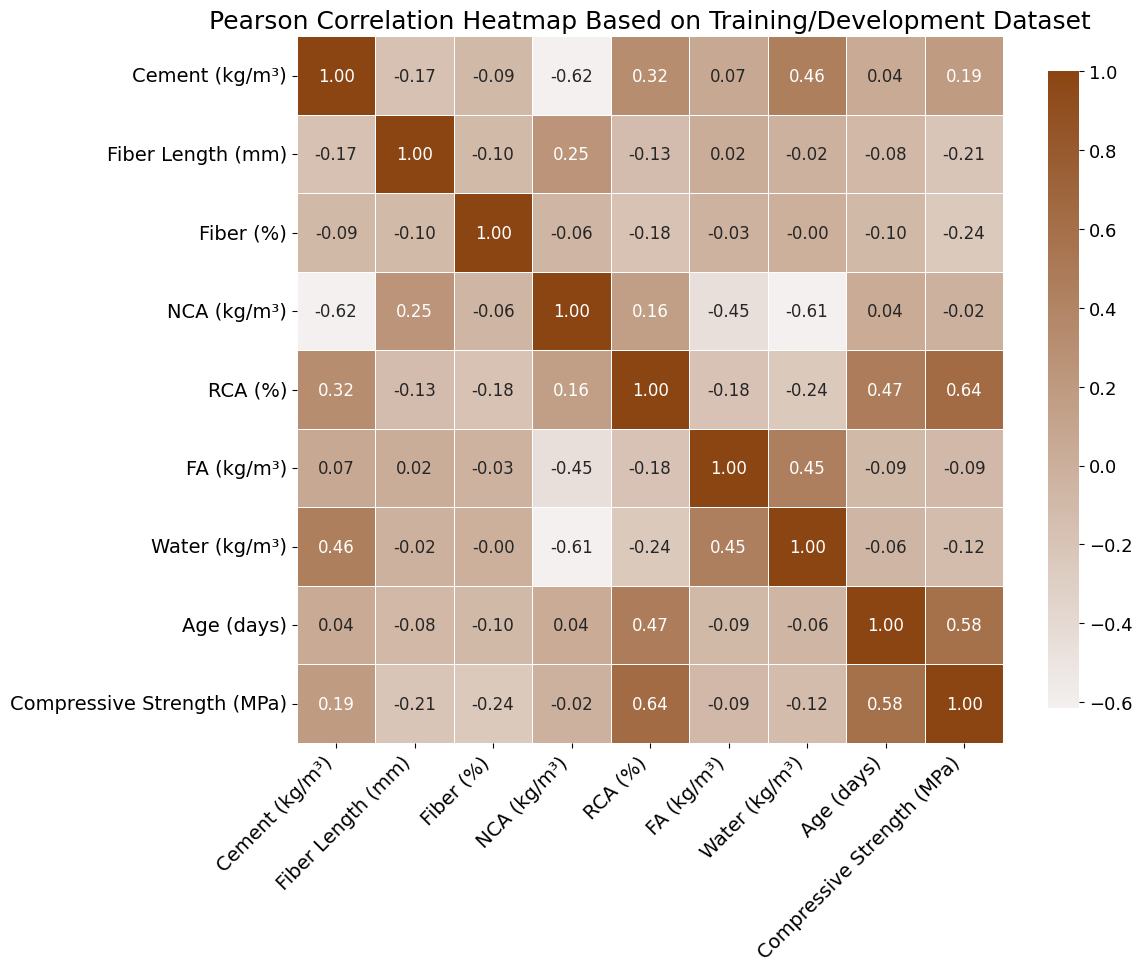

Saved heatmap as: Figure_2_Training_Set_Pearson_Correlation_Heatmap.png
Saved correlation matrix as: Training_Set_Pearson_Correlation_Matrix.xlsx


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1. Load dataset and saved split
# ==============================
data = pd.read_excel("Coconut fiber data.xlsx")

train_idx = np.load("train_idx.npy")
test_idx = np.load("test_idx.npy")

# Use training/development set only
train_data = data.iloc[train_idx].copy()
test_data = data.iloc[test_idx].copy()

print("Total samples:", len(data))
print("Training/development samples:", len(train_data))
print("Locked test samples:", len(test_data))

# Optional leakage checks
print("Index overlap:", len(set(train_idx).intersection(set(test_idx))))

if "Source" in data.columns:
    train_sources = set(train_data["Source"].unique())
    test_sources = set(test_data["Source"].unique())
    source_overlap = train_sources.intersection(test_sources)

    print("Training sources:", len(train_sources))
    print("Test sources:", len(test_sources))
    print("Overlapping sources:", len(source_overlap))


# ==========================================
# 2. Select variables for correlation analysis
# ==========================================
features = [
    "Cement (kg/m³)",
    "Fiber Length (mm)",
    "Fiber (%)",
    "NCA (kg/m³)",
    "RCA (%)",
    "FA (kg/m³)",
    "Water (kg/m³)",
    "Age (days)",
    "Compressive Strength (MPa)"
]

# Keep only available columns
features = [col for col in features if col in train_data.columns]

# Convert selected columns to numeric
corr_data = train_data[features].apply(pd.to_numeric, errors="coerce")

# Compute Pearson correlation matrix using training data only
corr_matrix = corr_data.corr(method="pearson")


# ==========================================
# 3. Plot training-set correlation heatmap
# ==========================================
# Coconut-inspired colormap: light tan to dark brown
cmap = sns.light_palette("#8B4513", as_cmap=True)

# Font size controls
TITLE_FS = 18
TICK_FS = 14
ANNOT_FS = 12
CBAR_FS = 13

plt.figure(figsize=(12, 10))

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=cmap,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.85},
    annot_kws={"size": ANNOT_FS}
)

ax.set_title(
    "Pearson Correlation Heatmap Based on Training/Development Dataset",
    fontsize=TITLE_FS
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=TICK_FS
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=TICK_FS
)

# Colorbar font size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=CBAR_FS)

plt.tight_layout()

plt.savefig(
    "Figure_2_Training_Set_Pearson_Correlation_Heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# 4. Optional: export correlation matrix
# ==========================================
corr_matrix.to_excel("Training_Set_Pearson_Correlation_Matrix.xlsx")

print("Saved heatmap as: Figure_2_Training_Set_Pearson_Correlation_Heatmap.png")
print("Saved correlation matrix as: Training_Set_Pearson_Correlation_Matrix.xlsx")


**Nested CV + Hyperparameter Selection + Ablation Curves + Regression Plots on 30% locked out Test Dataset**

**Support Vector Machine**

Total samples: 586
Training/development samples: 410
Locked test samples: 176

=== Outer Fold 1/5 ===
Stopping search: maximum iterations reached --> 25
Fold 1 PSO done in 0.85 min → C=1000, epsilon=0.001, gamma=0.07488

=== Outer Fold 2/5 ===
Stopping search: maximum iterations reached --> 25
Fold 2 PSO done in 0.84 min → C=1000, epsilon=1, gamma=0.1745

=== Outer Fold 3/5 ===
Stopping search: maximum iterations reached --> 25
Fold 3 PSO done in 0.75 min → C=626.3, epsilon=0.7782, gamma=0.337

=== Outer Fold 4/5 ===
Stopping search: maximum iterations reached --> 25
Fold 4 PSO done in 0.78 min → C=759.4, epsilon=0.8822, gamma=0.1424

=== Outer Fold 5/5 ===
Stopping search: maximum iterations reached --> 25
Fold 5 PSO done in 0.84 min → C=1000, epsilon=1, gamma=0.09196

Best parameter summary:
               C   epsilon     gamma
mean  877.151430  0.732292  0.164142
std   174.672791  0.419140  0.104455

Cross-validation summary:
  metric       mean       std      ci95  lower_bound  upp

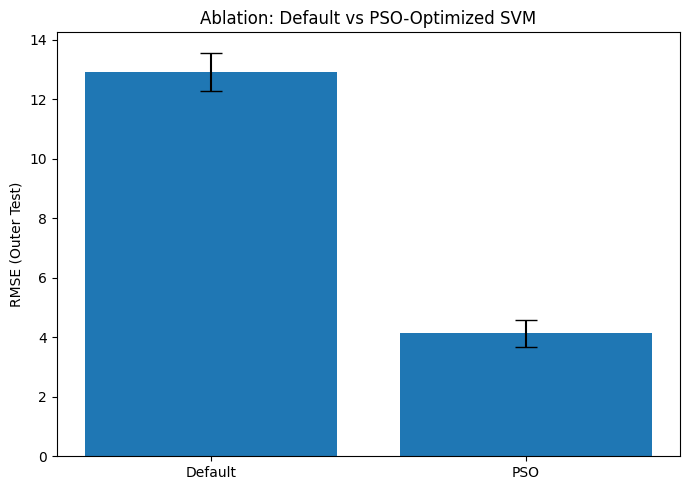


Final averaged SVM parameters:
{'C': 877.15143, 'epsilon': 0.732292, 'gamma': 0.164142}

Final Training Metrics:
R2: 0.9808
RMSE: 2.2137
RRMSE: 2.9013
NRMSE: 0.0697
MAE: 1.4433
MAPE: 5.5262
MEDAE: 0.7325

Final Locked Test Metrics:
R2: 0.9299
RMSE: 4.5403
RRMSE: 6.4401
NRMSE: 0.1387
MAE: 3.0463
MAPE: 10.9727
MEDAE: 1.9977


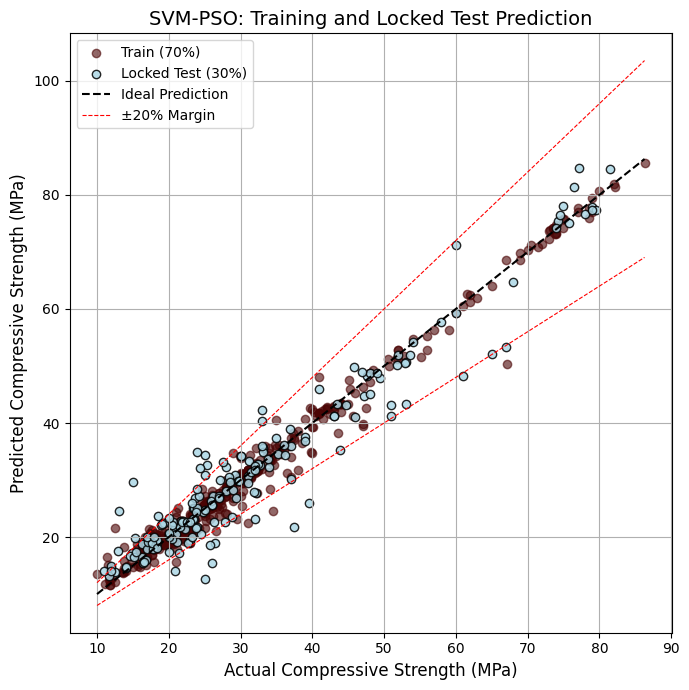

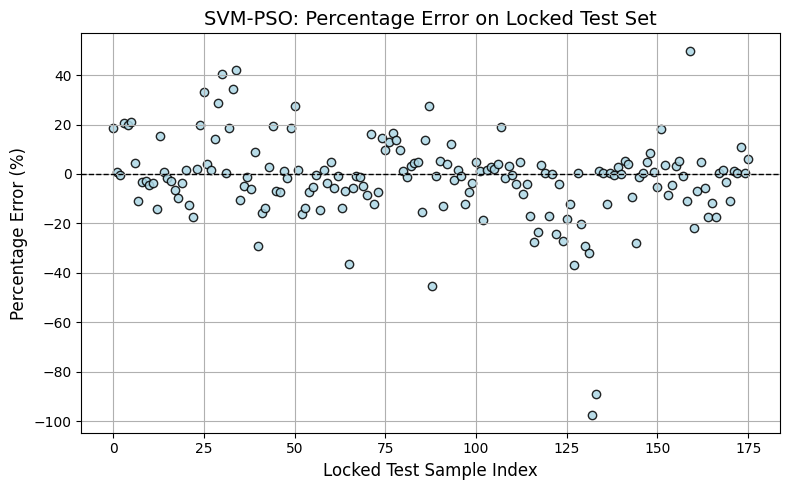


All SVM-PSO results saved in: svm_pso_grouped_nestedcv_outputs_corrected


In [ ]:
!pip -q install pyswarm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, time
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.svm import SVR
from pyswarm import pso
from scipy.stats import bootstrap

# ============================================================
# SVM-PSO Nested Grouped CV with Saved Train/Test Indices
# ============================================================

OUT_DIR = "svm_pso_grouped_nestedcv_outputs_corrected"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED = 42

# PSO meta-parameters
PSO_CONFIG = dict(
    swarmsize=20,
    maxiter=25,
    omega=0.7,
    phip=1.5,
    phig=1.5
)

# Search bounds for SVM-RBF: [C, epsilon, gamma]
LB = [1e-2, 1e-3, 1e-4]
UB = [1e+3, 1.0, 1.0]

# ============================================================
# 1. Load corrected dataset and saved indices
# ============================================================

df = pd.read_excel("Coconut fiber data.xlsx")

# Adjust target column name if needed
TARGET_COL = "Compressive Strength (MPa)"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Use Source as grouping variable
if "Source" in df.columns:
    groups = df["Source"].reset_index(drop=True)
else:
    groups = pd.Series(np.arange(len(df)))

# Load previously saved indices
train_idx = np.load("train_idx.npy")
test_idx = np.load("test_idx.npy")

# Safety checks
assert len(df) == len(train_idx) + len(test_idx), "Error: train/test indices do not cover the full dataset."
assert len(set(train_idx).intersection(set(test_idx))) == 0, "Error: train/test index overlap found."

# Create fixed training and locked test sets
X_train_all = X.iloc[train_idx].copy()
X_test_locked = X.iloc[test_idx].copy()

y_train_all = y.iloc[train_idx].copy()
y_test_locked = y.iloc[test_idx].copy()

groups_train_all = groups.iloc[train_idx].copy()
groups_test_locked = groups.iloc[test_idx].copy()

# Source-level leakage check
print("Total samples:", len(df))
print("Training/development samples:", len(X_train_all))
print("Locked test samples:", len(X_test_locked))

if "Source" in df.columns:
    train_sources = set(groups_train_all.unique())
    test_sources = set(groups_test_locked.unique())
    source_overlap = train_sources.intersection(test_sources)

    print("Training sources:", len(train_sources))
    print("Locked test sources:", len(test_sources))
    print("Overlapping sources:", len(source_overlap))

    assert len(source_overlap) == 0, f"Error: source overlap found: {source_overlap}"

# Save split verification
split_info = {
    "total_samples": len(df),
    "training_samples": len(X_train_all),
    "locked_test_samples": len(X_test_locked),
    "index_overlap": len(set(train_idx).intersection(set(test_idx)))
}

if "Source" in df.columns:
    split_info.update({
        "training_sources": len(train_sources),
        "locked_test_sources": len(test_sources),
        "source_overlap": len(source_overlap)
    })

with open(f"{OUT_DIR}/split_verification.json", "w") as f:
    json.dump(split_info, f, indent=2)

# ============================================================
# 2. Evaluation metrics
# ============================================================

def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # Avoid division by zero in MAPE
    denom = np.where(y_true == 0, np.finfo(float).eps, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100

    medae = np.median(np.abs(y_true - y_pred))

    # Additional metrics used in manuscript
    data_range = np.max(y_true) - np.min(y_true)
    mean_obs = np.mean(y_true)

    rrmse = (rmse / data_range) * 100 if data_range != 0 else np.nan
    nrmse = rmse / mean_obs if mean_obs != 0 else np.nan

    return {
        "r2": r2,
        "rmse": rmse,
        "rrmse": rrmse,
        "nrmse": nrmse,
        "mae": mae,
        "mape": mape,
        "medae": medae
    }

# ============================================================
# 3. Inner CV objective function for PSO
# ============================================================

def svr_inner_rmse(params, X_tr, y_tr, g_tr):
    C, eps, gam = params

    model = SVR(
        kernel="rbf",
        C=float(C),
        epsilon=float(eps),
        gamma=float(gam)
    )

    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []

    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        X_inner_train = X_tr.iloc[tr_i]
        X_inner_val = X_tr.iloc[val_i]

        y_inner_train = y_tr.iloc[tr_i]
        y_inner_val = y_tr.iloc[val_i]

        # Fit scaler only on inner-training data
        scaler = StandardScaler()
        X_inner_train_s = scaler.fit_transform(X_inner_train)
        X_inner_val_s = scaler.transform(X_inner_val)

        model.fit(X_inner_train_s, y_inner_train)
        preds = model.predict(X_inner_val_s)

        rmses.append(np.sqrt(mean_squared_error(y_inner_val, preds)))

    return np.mean(rmses)

# ============================================================
# 4. Outer nested grouped cross-validation
# ============================================================

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)

oof_rows = []
tr_rows = []
fold_metrics = []
per_fold_params = []

rmse_default_per_fold = []
rmse_pso_per_fold = []

for fold, (tr_idx, te_idx) in enumerate(
    outer_cv.split(X_train_all, y_train_all, groups_train_all), 1
):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")

    X_tr = X_train_all.iloc[tr_idx].copy()
    X_te = X_train_all.iloc[te_idx].copy()

    y_tr = y_train_all.iloc[tr_idx].copy()
    y_te = y_train_all.iloc[te_idx].copy()

    g_tr = groups_train_all.iloc[tr_idx].copy()
    g_te = groups_train_all.iloc[te_idx].copy()

    # Confirm no source overlap inside outer fold
    fold_source_overlap = set(g_tr.unique()).intersection(set(g_te.unique()))
    assert len(fold_source_overlap) == 0, f"Source overlap in outer fold {fold}: {fold_source_overlap}"

    # -------------------------
    # Inner PSO optimization
    # -------------------------
    t0 = time.time()

    obj = lambda p: svr_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)

    t_min = (time.time() - t0) / 60.0

    best_params = {
        "C": float(opt_params[0]),
        "epsilon": float(opt_params[1]),
        "gamma": float(opt_params[2])
    }

    print(
        f"Fold {fold} PSO done in {t_min:.2f} min → "
        f"C={best_params['C']:.4g}, "
        f"epsilon={best_params['epsilon']:.4g}, "
        f"gamma={best_params['gamma']:.4g}"
    )

    per_fold_params.append({
        "fold": fold,
        "best_params": best_params
    })

    # -------------------------
    # Train PSO model on outer-training fold
    # -------------------------
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    model_pso = SVR(kernel="rbf", **best_params)
    model_pso.fit(X_tr_s, y_tr)

    y_tr_pred = model_pso.predict(X_tr_s)
    y_te_pred = model_pso.predict(X_te_s)

    tr_rows.append(pd.DataFrame({
        "fold": fold,
        "role": "train",
        "y_true": y_tr.values,
        "y_pred": y_tr_pred
    }))

    oof_rows.append(pd.DataFrame({
        "fold": fold,
        "role": "outer_test",
        "y_true": y_te.values,
        "y_pred": y_te_pred
    }))

    metrics = evaluate(y_te, y_te_pred)
    metrics["fold"] = fold
    metrics["time_min"] = t_min

    fold_metrics.append(metrics)
    rmse_pso_per_fold.append(metrics["rmse"])

    # -------------------------
    # Default model for ablation
    # -------------------------
    model_default = SVR(kernel="rbf")
    model_default.fit(X_tr_s, y_tr)

    y_te_default = model_default.predict(X_te_s)
    default_rmse = np.sqrt(mean_squared_error(y_te, y_te_default))

    rmse_default_per_fold.append(default_rmse)

# ============================================================
# 5. Save CV predictions and fold metrics
# ============================================================

oof_df = pd.concat(oof_rows, ignore_index=True)
tr_df = pd.concat(tr_rows, ignore_index=True)

oof_df.to_csv(f"{OUT_DIR}/oof_predictions_outer_test.csv", index=False)
tr_df.to_csv(f"{OUT_DIR}/train_predictions_per_fold.csv", index=False)

fold_df = pd.DataFrame(fold_metrics)
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)

with open(f"{OUT_DIR}/best_params_per_fold.json", "w") as f:
    json.dump(per_fold_params, f, indent=2)

bp_df = pd.DataFrame([
    {"fold": d["fold"], **d["best_params"]}
    for d in per_fold_params
])

bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold_table.csv", index=False)

bp_summary = bp_df.drop(columns=["fold"]).agg(["mean", "std"]).round(6)
bp_summary.to_csv(f"{OUT_DIR}/best_params_mean_std.csv")

print("\nBest parameter summary:")
print(bp_summary)

# ============================================================
# 6. Mean ± SD and 95% CI from outer folds
# ============================================================

summary_rows = []

for metric in ["r2", "rmse", "rrmse", "nrmse", "mae", "mape", "medae"]:
    m = fold_df[metric].mean()
    s = fold_df[metric].std(ddof=1)
    ci = 1.96 * s / np.sqrt(OUTER_SPLITS)

    summary_rows.append({
        "metric": metric.upper(),
        "mean": m,
        "std": s,
        "ci95": ci,
        "lower_bound": m - ci,
        "upper_bound": m + ci
    })

cv_summary_df = pd.DataFrame(summary_rows)
cv_summary_df.to_csv(f"{OUT_DIR}/cv_mean_std_ci95_summary.csv", index=False)

print("\nCross-validation summary:")
print(cv_summary_df)

# ============================================================
# 7. Bootstrap CI using out-of-fold predictions
# ============================================================

def boot_ci(stat_fn, df_in, n_resamples=1000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(df_in))
    stats = []

    for _ in range(n_resamples):
        sampled_idx = rng.choice(idx, size=len(idx), replace=True)
        sample = df_in.iloc[sampled_idx]
        stats.append(stat_fn(sample))

    return np.quantile(stats, [0.025, 0.975])

r2_ci = boot_ci(lambda d: r2_score(d["y_true"], d["y_pred"]), oof_df)
rmse_ci = boot_ci(lambda d: np.sqrt(mean_squared_error(d["y_true"], d["y_pred"])), oof_df)
mae_ci = boot_ci(lambda d: mean_absolute_error(d["y_true"], d["y_pred"]), oof_df)
medae_ci = boot_ci(lambda d: np.median(np.abs(d["y_true"] - d["y_pred"])), oof_df)

bootstrap_ci_df = pd.DataFrame([
    {"metric": "R2", "boot_ci_lower": r2_ci[0], "boot_ci_upper": r2_ci[1]},
    {"metric": "RMSE", "boot_ci_lower": rmse_ci[0], "boot_ci_upper": rmse_ci[1]},
    {"metric": "MAE", "boot_ci_lower": mae_ci[0], "boot_ci_upper": mae_ci[1]},
    {"metric": "MedAE", "boot_ci_lower": medae_ci[0], "boot_ci_upper": medae_ci[1]},
])

bootstrap_ci_df.to_csv(f"{OUT_DIR}/ci95_bootstrap_oof.csv", index=False)

# ============================================================
# 8. Ablation study: Default vs PSO
# ============================================================

def ci95_width(values):
    values = np.asarray(values)

    b = bootstrap(
        (values,),
        np.mean,
        confidence_level=0.95,
        random_state=RANDOM_SEED
    )

    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)

err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

ablation_df = pd.DataFrame({
    "Model": ["Default SVM", "PSO-Optimized SVM"],
    "Mean RMSE": [rmse_def_mean, rmse_pso_mean],
    "CI95 Upper Width": [err_def, err_pso]
})

ablation_df.to_csv(f"{OUT_DIR}/ablation_default_vs_pso.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(
    ["Default", "PSO"],
    [rmse_def_mean, rmse_pso_mean],
    yerr=[err_def, err_pso],
    capsize=8
)

plt.ylabel("RMSE (Outer Test)")
plt.title("Ablation: Default vs PSO-Optimized SVM")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600, bbox_inches="tight")
plt.show()

# ============================================================
# 9. Final model training on full 70% training set
#    Locked test set used only here for final evaluation
# ============================================================

best_params_avg = bp_summary.loc["mean"].to_dict()

final_hp = {
    "C": float(best_params_avg["C"]),
    "epsilon": float(best_params_avg["epsilon"]),
    "gamma": float(best_params_avg["gamma"])
}

print("\nFinal averaged SVM parameters:")
print(final_hp)

# Fit scaler only on full training/development set
scaler_final = StandardScaler()
X_train_s = scaler_final.fit_transform(X_train_all)
X_test_s = scaler_final.transform(X_test_locked)

final_model = SVR(kernel="rbf", **final_hp)
final_model.fit(X_train_s, y_train_all)

y_train_pred_final = final_model.predict(X_train_s)
y_test_pred_final = final_model.predict(X_test_s)

# Final locked-test metrics
train_metrics = evaluate(y_train_all, y_train_pred_final)
test_metrics = evaluate(y_test_locked, y_test_pred_final)

print("\nFinal Training Metrics:")
for k, v in train_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

print("\nFinal Locked Test Metrics:")
for k, v in test_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

final_metrics_df = pd.DataFrame([
    {"phase": "Training", **train_metrics},
    {"phase": "Locked Test", **test_metrics}
])

final_metrics_df.to_csv(f"{OUT_DIR}/final_train_locked_test_metrics.csv", index=False)

# Save final predictions
pd.DataFrame({
    "y_true": y_train_all.values,
    "y_pred": y_train_pred_final
}).to_csv(f"{OUT_DIR}/final_train_predictions.csv", index=False)

pd.DataFrame({
    "y_true": y_test_locked.values,
    "y_pred": y_test_pred_final
}).to_csv(f"{OUT_DIR}/locked_test_predictions.csv", index=False)

# ============================================================
# 10. Regression plot: Training and locked test
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train_all,
    y_train_pred_final,
    color="#4A0404",
    alpha=0.6,
    label="Train (70%)"
)

plt.scatter(
    y_test_locked,
    y_test_pred_final,
    color="lightblue",
    edgecolor="k",
    alpha=0.85,
    label="Locked Test (30%)"
)

min_val = min(
    y_train_all.min(),
    y_test_locked.min(),
    y_train_pred_final.min(),
    y_test_pred_final.min()
)

max_val = max(
    y_train_all.max(),
    y_test_locked.max(),
    y_train_pred_final.max(),
    y_test_pred_final.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "k--",
    label="Ideal Prediction"
)

plt.plot(
    [min_val, max_val],
    [min_val * 1.2, max_val * 1.2],
    "r--",
    lw=0.8,
    label="±20% Margin"
)

plt.plot(
    [min_val, max_val],
    [min_val * 0.8, max_val * 0.8],
    "r--",
    lw=0.8
)

plt.xlabel("Actual Compressive Strength (MPa)", fontsize=12)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=12)
plt.title("SVM-PSO: Training and Locked Test Prediction", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/SVM_PSO_locked_test_regression.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 11. Percentage error plot for locked test
# ============================================================

percentage_error = ((y_test_locked.values - y_test_pred_final) / y_test_locked.values) * 100

plt.figure(figsize=(8, 5))
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.scatter(
    range(len(percentage_error)),
    percentage_error,
    color="lightblue",
    edgecolor="k",
    alpha=0.85
)

plt.xlabel("Locked Test Sample Index", fontsize=12)
plt.ylabel("Percentage Error (%)", fontsize=12)
plt.title("SVM-PSO: Percentage Error on Locked Test Set", fontsize=14)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/SVM_PSO_locked_test_percentage_error.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nAll SVM-PSO results saved in:", OUT_DIR)

**K Nearest Neighbour**

Total samples: 586
Training/development samples: 410
Locked test samples: 176

=== Outer Fold 1/5 ===
Stopping search: maximum iterations reached --> 25
Fold 1 PSO done in 0.21 min → {'n_neighbors': 1, 'weights': 'uniform', 'p': 1.0, 'leaf_size': 23, 'metric': 'minkowski', 'algorithm': 'auto'}

=== Outer Fold 2/5 ===
Stopping search: maximum iterations reached --> 25
Fold 2 PSO done in 0.24 min → {'n_neighbors': 3, 'weights': 'distance', 'p': 1.000981436801837, 'leaf_size': 10, 'metric': 'minkowski', 'algorithm': 'auto'}

=== Outer Fold 3/5 ===
Stopping search: maximum iterations reached --> 25
Fold 3 PSO done in 0.30 min → {'n_neighbors': 3, 'weights': 'distance', 'p': 1.0617556291247798, 'leaf_size': 60, 'metric': 'minkowski', 'algorithm': 'auto'}

=== Outer Fold 4/5 ===
Stopping search: maximum iterations reached --> 25
Fold 4 PSO done in 0.21 min → {'n_neighbors': 2, 'weights': 'distance', 'p': 1.0, 'leaf_size': 22, 'metric': 'minkowski', 'algorithm': 'auto'}

=== Outer Fold 5/5 ==

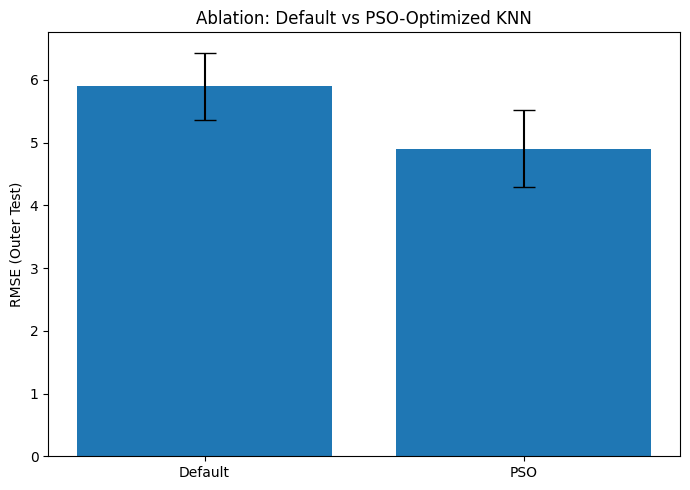


Final averaged KNN parameters:
{'n_neighbors': 2, 'weights': 'distance', 'p': 1.012547, 'leaf_size': 32, 'metric': 'minkowski', 'algorithm': 'auto'}

Final Training Metrics:
R2: 0.9984
RMSE: 0.6333
RRMSE: 0.8300
NRMSE: 0.0199
MAE: 0.1590
MAPE: 0.5719
MEDAE: 0.0000

Final Locked Test Metrics:
R2: 0.8639
RMSE: 6.3274
RRMSE: 8.9750
NRMSE: 0.1933
MAE: 4.5886
MAPE: 16.7953
MEDAE: 3.3670


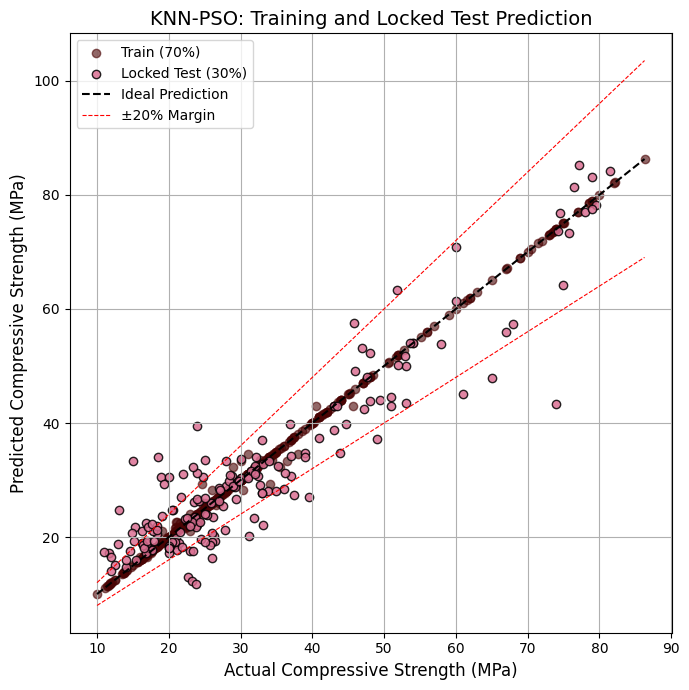

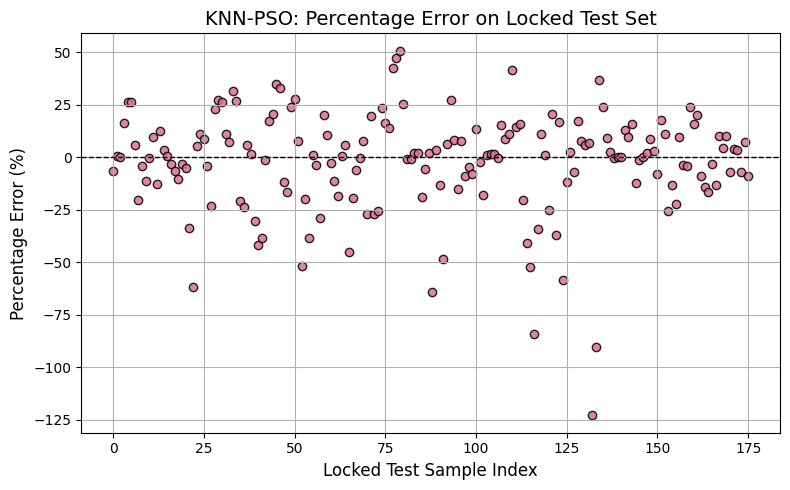


All KNN-PSO results saved in: knn_pso_grouped_nestedcv_outputs


In [ ]:
!pip -q install pyswarm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, time
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from pyswarm import pso
from scipy.stats import bootstrap

# ============================================================
# KNN-PSO Nested Grouped CV with Saved Train/Test Indices
# ============================================================

OUT_DIR = "knn_pso_grouped_nestedcv_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED = 42

# PSO meta-parameters
PSO_CONFIG = dict(
    swarmsize=20,
    maxiter=25,
    omega=0.7,
    phip=1.5,
    phig=1.5
)

# Search bounds for KNN:
# [n_neighbors, weights_flag, p, leaf_size]
LB = [1, 0.0, 1.0, 10]
UB = [60, 1.0, 3.0, 60]

# ============================================================
# 1. Load corrected dataset and saved indices
# ============================================================

df = pd.read_excel("Coconut fiber data.xlsx")

TARGET_COL = "Compressive Strength (MPa)"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Use Source as grouping variable
if "Source" in df.columns:
    groups = df["Source"].reset_index(drop=True)
else:
    groups = pd.Series(np.arange(len(df)))

# Load previously saved train/test indices
train_idx = np.load("train_idx.npy")
test_idx = np.load("test_idx.npy")

# Safety checks
assert len(df) == len(train_idx) + len(test_idx), "Error: train/test indices do not cover the full dataset."
assert len(set(train_idx).intersection(set(test_idx))) == 0, "Error: train/test index overlap found."

# Create fixed training/development and locked test sets
X_train_all = X.iloc[train_idx].copy()
X_test_locked = X.iloc[test_idx].copy()

y_train_all = y.iloc[train_idx].copy()
y_test_locked = y.iloc[test_idx].copy()

groups_train_all = groups.iloc[train_idx].copy()
groups_test_locked = groups.iloc[test_idx].copy()

# Source-level leakage check
print("Total samples:", len(df))
print("Training/development samples:", len(X_train_all))
print("Locked test samples:", len(X_test_locked))

if "Source" in df.columns:
    train_sources = set(groups_train_all.unique())
    test_sources = set(groups_test_locked.unique())
    source_overlap = train_sources.intersection(test_sources)

    print("Training sources:", len(train_sources))
    print("Locked test sources:", len(test_sources))
    print("Overlapping sources:", len(source_overlap))

    assert len(source_overlap) == 0, f"Error: source overlap found: {source_overlap}"

# Save split verification
split_info = {
    "total_samples": len(df),
    "training_samples": len(X_train_all),
    "locked_test_samples": len(X_test_locked),
    "index_overlap": len(set(train_idx).intersection(set(test_idx)))
}

if "Source" in df.columns:
    split_info.update({
        "training_sources": len(train_sources),
        "locked_test_sources": len(test_sources),
        "source_overlap": len(source_overlap)
    })

with open(f"{OUT_DIR}/split_verification.json", "w") as f:
    json.dump(split_info, f, indent=2)

# ============================================================
# 2. Evaluation metrics
# ============================================================

def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # Avoid division by zero in MAPE
    denom = np.where(y_true == 0, np.finfo(float).eps, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100

    medae = np.median(np.abs(y_true - y_pred))

    # Additional metrics used in manuscript
    data_range = np.max(y_true) - np.min(y_true)
    mean_obs = np.mean(y_true)

    rrmse = (rmse / data_range) * 100 if data_range != 0 else np.nan
    nrmse = rmse / mean_obs if mean_obs != 0 else np.nan

    return {
        "r2": r2,
        "rmse": rmse,
        "rrmse": rrmse,
        "nrmse": nrmse,
        "mae": mae,
        "mape": mape,
        "medae": medae
    }

# ============================================================
# 3. Decode KNN hyperparameters
# ============================================================

def decode_knn_params(params):
    n_neighbors = int(round(params[0]))
    weights_flag = float(params[1])
    weights = "distance" if weights_flag >= 0.5 else "uniform"
    p = float(params[2])
    leaf_size = int(round(params[3]))

    n_neighbors = max(1, n_neighbors)
    leaf_size = max(10, leaf_size)

    return dict(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p,
        leaf_size=leaf_size,
        metric="minkowski",
        algorithm="auto"
    )

# ============================================================
# 4. Inner CV objective function for PSO
# ============================================================

def knn_inner_rmse(params, X_tr, y_tr, g_tr):
    hp = decode_knn_params(params)

    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []

    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        X_inner_train = X_tr.iloc[tr_i]
        X_inner_val = X_tr.iloc[val_i]

        y_inner_train = y_tr.iloc[tr_i]
        y_inner_val = y_tr.iloc[val_i]

        # Fit scaler only on inner-training data
        scaler = StandardScaler()
        X_inner_train_s = scaler.fit_transform(X_inner_train)
        X_inner_val_s = scaler.transform(X_inner_val)

        model = KNeighborsRegressor(**hp)
        model.fit(X_inner_train_s, y_inner_train)

        preds = model.predict(X_inner_val_s)

        rmses.append(np.sqrt(mean_squared_error(y_inner_val, preds)))

    return np.mean(rmses)

# ============================================================
# 5. Outer nested grouped cross-validation
# ============================================================

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)

oof_rows = []
tr_rows = []
fold_metrics = []
per_fold_params = []

rmse_default_per_fold = []
rmse_pso_per_fold = []

for fold, (tr_idx, te_idx) in enumerate(
    outer_cv.split(X_train_all, y_train_all, groups_train_all), 1
):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")

    X_tr = X_train_all.iloc[tr_idx].copy()
    X_te = X_train_all.iloc[te_idx].copy()

    y_tr = y_train_all.iloc[tr_idx].copy()
    y_te = y_train_all.iloc[te_idx].copy()

    g_tr = groups_train_all.iloc[tr_idx].copy()
    g_te = groups_train_all.iloc[te_idx].copy()

    # Confirm no source overlap inside outer fold
    fold_source_overlap = set(g_tr.unique()).intersection(set(g_te.unique()))
    assert len(fold_source_overlap) == 0, f"Source overlap in outer fold {fold}: {fold_source_overlap}"

    # -------------------------
    # Inner PSO optimization
    # -------------------------
    t0 = time.time()

    obj = lambda p: knn_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)

    t_min = (time.time() - t0) / 60.0

    best_params = decode_knn_params(opt_params)

    print(f"Fold {fold} PSO done in {t_min:.2f} min → {best_params}")

    per_fold_params.append({
        "fold": fold,
        "best_params": best_params
    })

    # -------------------------
    # Train PSO model on outer-training fold
    # -------------------------
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    model_pso = KNeighborsRegressor(**best_params)
    model_pso.fit(X_tr_s, y_tr)

    y_tr_pred = model_pso.predict(X_tr_s)
    y_te_pred = model_pso.predict(X_te_s)

    tr_rows.append(pd.DataFrame({
        "fold": fold,
        "role": "train",
        "y_true": y_tr.values,
        "y_pred": y_tr_pred
    }))

    oof_rows.append(pd.DataFrame({
        "fold": fold,
        "role": "outer_test",
        "y_true": y_te.values,
        "y_pred": y_te_pred
    }))

    metrics = evaluate(y_te, y_te_pred)
    metrics["fold"] = fold
    metrics["time_min"] = t_min

    fold_metrics.append(metrics)
    rmse_pso_per_fold.append(metrics["rmse"])

    # -------------------------
    # Default model for ablation
    # -------------------------
    model_default = KNeighborsRegressor()
    model_default.fit(X_tr_s, y_tr)

    y_te_default = model_default.predict(X_te_s)
    default_rmse = np.sqrt(mean_squared_error(y_te, y_te_default))

    rmse_default_per_fold.append(default_rmse)

# ============================================================
# 6. Save CV predictions and fold metrics
# ============================================================

oof_df = pd.concat(oof_rows, ignore_index=True)
tr_df = pd.concat(tr_rows, ignore_index=True)

oof_df.to_csv(f"{OUT_DIR}/oof_predictions_outer_test.csv", index=False)
tr_df.to_csv(f"{OUT_DIR}/train_predictions_per_fold.csv", index=False)

fold_df = pd.DataFrame(fold_metrics)
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)

with open(f"{OUT_DIR}/best_params_per_fold.json", "w") as f:
    json.dump(per_fold_params, f, indent=2)

bp_df = pd.DataFrame([
    {"fold": d["fold"], **d["best_params"]}
    for d in per_fold_params
])

bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold_table.csv", index=False)

# Convert weights to numeric for averaging
bp_num = bp_df.copy()
bp_num["weights_num"] = (bp_num["weights"] == "distance").astype(float)

bp_summary = pd.DataFrame({
    "n_neighbors_mean": [bp_num["n_neighbors"].mean()],
    "n_neighbors_std": [bp_num["n_neighbors"].std(ddof=1)],
    "weights_mean": [bp_num["weights_num"].mean()],
    "weights_std": [bp_num["weights_num"].std(ddof=1)],
    "p_mean": [bp_num["p"].mean()],
    "p_std": [bp_num["p"].std(ddof=1)],
    "leaf_size_mean": [bp_num["leaf_size"].mean()],
    "leaf_size_std": [bp_num["leaf_size"].std(ddof=1)]
}).round(6)

bp_summary.to_csv(f"{OUT_DIR}/best_params_mean_std.csv", index=False)

print("\nBest parameter summary:")
print(bp_summary)

# ============================================================
# 7. Mean ± SD and 95% CI from outer folds
# ============================================================

summary_rows = []

for metric in ["r2", "rmse", "rrmse", "nrmse", "mae", "mape", "medae"]:
    m = fold_df[metric].mean()
    s = fold_df[metric].std(ddof=1)
    ci = 1.96 * s / np.sqrt(OUTER_SPLITS)

    summary_rows.append({
        "metric": metric.upper(),
        "mean": m,
        "std": s,
        "ci95": ci,
        "lower_bound": m - ci,
        "upper_bound": m + ci
    })

cv_summary_df = pd.DataFrame(summary_rows)
cv_summary_df.to_csv(f"{OUT_DIR}/cv_mean_std_ci95_summary.csv", index=False)

print("\nCross-validation summary:")
print(cv_summary_df)

# ============================================================
# 8. Bootstrap CI using out-of-fold predictions
# ============================================================

def boot_ci(stat_fn, df_in, n_resamples=1000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(df_in))
    stats = []

    for _ in range(n_resamples):
        sampled_idx = rng.choice(idx, size=len(idx), replace=True)
        sample = df_in.iloc[sampled_idx]
        stats.append(stat_fn(sample))

    return np.quantile(stats, [0.025, 0.975])

r2_ci = boot_ci(lambda d: r2_score(d["y_true"], d["y_pred"]), oof_df)
rmse_ci = boot_ci(lambda d: np.sqrt(mean_squared_error(d["y_true"], d["y_pred"])), oof_df)
mae_ci = boot_ci(lambda d: mean_absolute_error(d["y_true"], d["y_pred"]), oof_df)
medae_ci = boot_ci(lambda d: np.median(np.abs(d["y_true"] - d["y_pred"])), oof_df)

bootstrap_ci_df = pd.DataFrame([
    {"metric": "R2", "boot_ci_lower": r2_ci[0], "boot_ci_upper": r2_ci[1]},
    {"metric": "RMSE", "boot_ci_lower": rmse_ci[0], "boot_ci_upper": rmse_ci[1]},
    {"metric": "MAE", "boot_ci_lower": mae_ci[0], "boot_ci_upper": mae_ci[1]},
    {"metric": "MedAE", "boot_ci_lower": medae_ci[0], "boot_ci_upper": medae_ci[1]},
])

bootstrap_ci_df.to_csv(f"{OUT_DIR}/ci95_bootstrap_oof.csv", index=False)

# ============================================================
# 9. Ablation study: Default vs PSO
# ============================================================

def ci95_width(values):
    values = np.asarray(values)

    b = bootstrap(
        (values,),
        np.mean,
        confidence_level=0.95,
        random_state=RANDOM_SEED
    )

    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)

err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

ablation_df = pd.DataFrame({
    "Model": ["Default KNN", "PSO-Optimized KNN"],
    "Mean RMSE": [rmse_def_mean, rmse_pso_mean],
    "CI95 Upper Width": [err_def, err_pso]
})

ablation_df.to_csv(f"{OUT_DIR}/ablation_default_vs_pso.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(
    ["Default", "PSO"],
    [rmse_def_mean, rmse_pso_mean],
    yerr=[err_def, err_pso],
    capsize=8
)

plt.ylabel("RMSE (Outer Test)")
plt.title("Ablation: Default vs PSO-Optimized KNN")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600, bbox_inches="tight")
plt.show()

# ============================================================
# 10. Final model training on full 70% training set
#     Locked test set used only here for final evaluation
# ============================================================

best_params_avg = bp_summary.iloc[0].to_dict()

avg_weights = "distance" if float(best_params_avg["weights_mean"]) >= 0.5 else "uniform"

final_hp = dict(
    n_neighbors=int(round(float(best_params_avg["n_neighbors_mean"]))),
    weights=avg_weights,
    p=float(best_params_avg["p_mean"]),
    leaf_size=int(round(float(best_params_avg["leaf_size_mean"]))),
    metric="minkowski",
    algorithm="auto"
)

print("\nFinal averaged KNN parameters:")
print(final_hp)

# Fit scaler only on full training/development set
scaler_final = StandardScaler()
X_train_s = scaler_final.fit_transform(X_train_all)
X_test_s = scaler_final.transform(X_test_locked)

final_model = KNeighborsRegressor(**final_hp)
final_model.fit(X_train_s, y_train_all)

y_train_pred_final = final_model.predict(X_train_s)
y_test_pred_final = final_model.predict(X_test_s)

# Final metrics
train_metrics = evaluate(y_train_all, y_train_pred_final)
test_metrics = evaluate(y_test_locked, y_test_pred_final)

print("\nFinal Training Metrics:")
for k, v in train_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

print("\nFinal Locked Test Metrics:")
for k, v in test_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

final_metrics_df = pd.DataFrame([
    {"phase": "Training", **train_metrics},
    {"phase": "Locked Test", **test_metrics}
])

final_metrics_df.to_csv(f"{OUT_DIR}/final_train_locked_test_metrics.csv", index=False)

# Save final predictions
pd.DataFrame({
    "y_true": y_train_all.values,
    "y_pred": y_train_pred_final
}).to_csv(f"{OUT_DIR}/final_train_predictions.csv", index=False)

pd.DataFrame({
    "y_true": y_test_locked.values,
    "y_pred": y_test_pred_final
}).to_csv(f"{OUT_DIR}/locked_test_predictions.csv", index=False)

# ============================================================
# 11. Regression plot: Training and locked test
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train_all,
    y_train_pred_final,
    color="#4A0404",
    alpha=0.6,
    label="Train (70%)"
)

plt.scatter(
    y_test_locked,
    y_test_pred_final,
    color="palevioletred",
    edgecolor="k",
    alpha=0.85,
    label="Locked Test (30%)"
)

min_val = min(
    y_train_all.min(),
    y_test_locked.min(),
    y_train_pred_final.min(),
    y_test_pred_final.min()
)

max_val = max(
    y_train_all.max(),
    y_test_locked.max(),
    y_train_pred_final.max(),
    y_test_pred_final.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "k--",
    label="Ideal Prediction"
)

plt.plot(
    [min_val, max_val],
    [min_val * 1.2, max_val * 1.2],
    "r--",
    lw=0.8,
    label="±20% Margin"
)

plt.plot(
    [min_val, max_val],
    [min_val * 0.8, max_val * 0.8],
    "r--",
    lw=0.8
)

plt.xlabel("Actual Compressive Strength (MPa)", fontsize=12)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=12)
plt.title("KNN-PSO: Training and Locked Test Prediction", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/KNN_PSO_locked_test_regression.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 12. Percentage error plot for locked test
# ============================================================

percentage_error = ((y_test_locked.values - y_test_pred_final) / y_test_locked.values) * 100

plt.figure(figsize=(8, 5))
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.scatter(
    range(len(percentage_error)),
    percentage_error,
    color="palevioletred",
    edgecolor="k",
    alpha=0.85
)

plt.xlabel("Locked Test Sample Index", fontsize=12)
plt.ylabel("Percentage Error (%)", fontsize=12)
plt.title("KNN-PSO: Percentage Error on Locked Test Set", fontsize=14)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/KNN_PSO_locked_test_percentage_error.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nAll KNN-PSO results saved in:", OUT_DIR)

**Random Forest**

Total samples: 586
Training/development samples: 410
Locked test samples: 176

=== Outer Fold 1/5 ===
Stopping search: maximum iterations reached --> 25
Fold 1 PSO done in 8.88 min → {'n_estimators': 76, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.15381460709995096, 'random_state': 42, 'n_jobs': -1}

=== Outer Fold 2/5 ===
Stopping search: maximum iterations reached --> 25
Fold 2 PSO done in 4.54 min → {'n_estimators': 50, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5375043813395135, 'random_state': 42, 'n_jobs': -1}

=== Outer Fold 3/5 ===
Stopping search: maximum iterations reached --> 25
Fold 3 PSO done in 25.45 min → {'n_estimators': 469, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.3747173620017326, 'random_state': 42, 'n_jobs': -1}

=== Outer Fold 4/5 ===
Stopping search: Swarm best objective change less than 1e-08
Fold 4 PSO done in 2.49 min → {'n_estimators': 50, 'ma

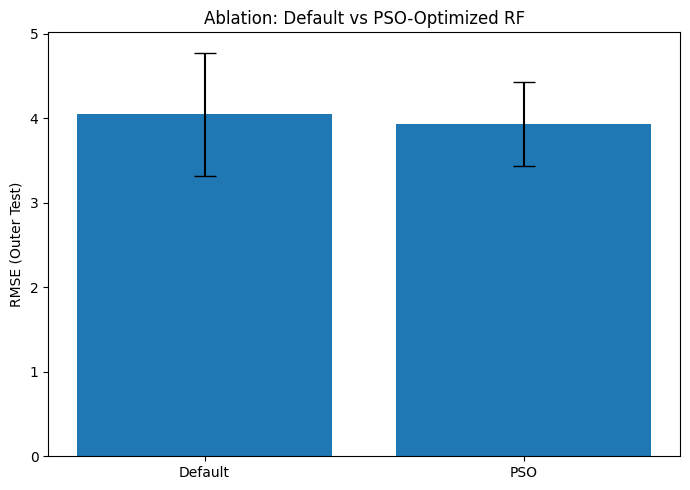


Final averaged RF parameters:
{'n_estimators': 150, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.325054, 'random_state': 42, 'n_jobs': -1}

Final Training Metrics:
R2: 0.9920
RMSE: 1.4310
RRMSE: 1.8754
NRMSE: 0.0450
MAE: 0.9919
MAPE: 3.5763
MEDAE: 0.6243

Final Locked Test Metrics:
R2: 0.9394
RMSE: 4.2225
RRMSE: 5.9893
NRMSE: 0.1290
MAE: 3.0565
MAPE: 10.5801
MEDAE: 2.0876


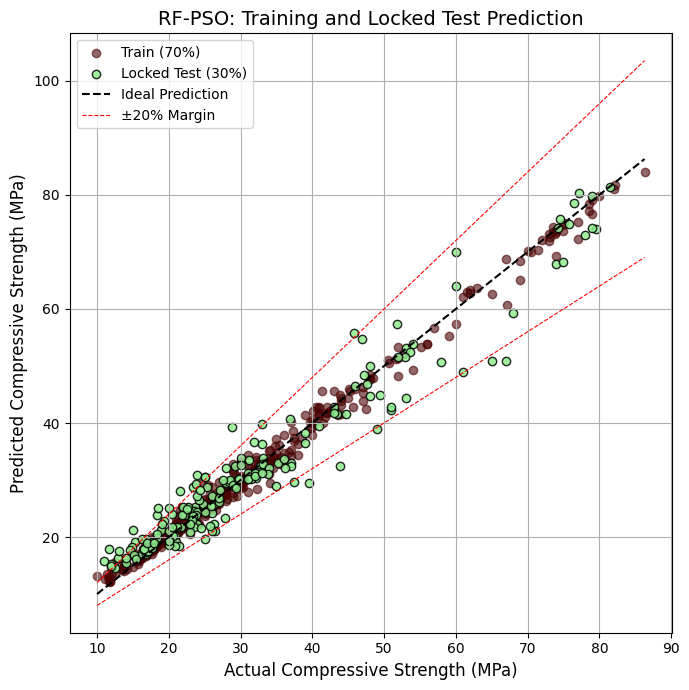

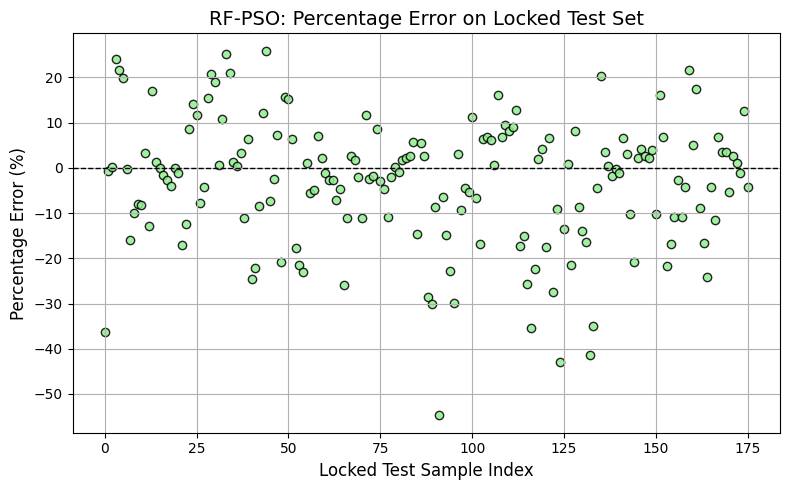


All RF-PSO results saved in: rf_pso_grouped_nestedcv_outputs_corrected


In [ ]:
# !pip -q install pyswarm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, time
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from pyswarm import pso
from scipy.stats import bootstrap

# ============================================================
# Random Forest-PSO Nested Grouped CV with Saved Train/Test Indices
# ============================================================

OUT_DIR = "rf_pso_grouped_nestedcv_outputs_corrected"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED = 42

# PSO meta-parameters
PSO_CONFIG = dict(
    swarmsize=20,
    maxiter=25,
    omega=0.7,
    phip=1.5,
    phig=1.5
)

# Search bounds for RF:
# [n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features]
LB = [50, 2, 2, 1, 0.1]
UB = [500, 30, 20, 10, 1.0]

# ============================================================
# 1. Load corrected dataset and saved indices
# ============================================================

df = pd.read_excel("Coconut fiber data.xlsx")

TARGET_COL = "Compressive Strength (MPa)"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Use Source as grouping variable
if "Source" in df.columns:
    groups = df["Source"].reset_index(drop=True)
else:
    groups = pd.Series(np.arange(len(df)))

# Load previously saved train/test indices
train_idx = np.load("train_idx.npy")
test_idx = np.load("test_idx.npy")

# Safety checks
assert len(df) == len(train_idx) + len(test_idx), "Error: train/test indices do not cover the full dataset."
assert len(set(train_idx).intersection(set(test_idx))) == 0, "Error: train/test index overlap found."

# Create fixed training/development and locked test sets
X_train_all = X.iloc[train_idx].copy()
X_test_locked = X.iloc[test_idx].copy()

y_train_all = y.iloc[train_idx].copy()
y_test_locked = y.iloc[test_idx].copy()

groups_train_all = groups.iloc[train_idx].copy()
groups_test_locked = groups.iloc[test_idx].copy()

# Source-level leakage check
print("Total samples:", len(df))
print("Training/development samples:", len(X_train_all))
print("Locked test samples:", len(X_test_locked))

if "Source" in df.columns:
    train_sources = set(groups_train_all.unique())
    test_sources = set(groups_test_locked.unique())
    source_overlap = train_sources.intersection(test_sources)

    print("Training sources:", len(train_sources))
    print("Locked test sources:", len(test_sources))
    print("Overlapping sources:", len(source_overlap))

    assert len(source_overlap) == 0, f"Error: source overlap found: {source_overlap}"

# Save split verification
split_info = {
    "total_samples": len(df),
    "training_samples": len(X_train_all),
    "locked_test_samples": len(X_test_locked),
    "index_overlap": len(set(train_idx).intersection(set(test_idx)))
}

if "Source" in df.columns:
    split_info.update({
        "training_sources": len(train_sources),
        "locked_test_sources": len(test_sources),
        "source_overlap": len(source_overlap)
    })

with open(f"{OUT_DIR}/split_verification.json", "w") as f:
    json.dump(split_info, f, indent=2)

# ============================================================
# 2. Evaluation metrics
# ============================================================

def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # Avoid division by zero in MAPE
    denom = np.where(y_true == 0, np.finfo(float).eps, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100

    medae = np.median(np.abs(y_true - y_pred))

    # Additional metrics used in manuscript
    data_range = np.max(y_true) - np.min(y_true)
    mean_obs = np.mean(y_true)

    rrmse = (rmse / data_range) * 100 if data_range != 0 else np.nan
    nrmse = rmse / mean_obs if mean_obs != 0 else np.nan

    return {
        "r2": r2,
        "rmse": rmse,
        "rrmse": rrmse,
        "nrmse": nrmse,
        "mae": mae,
        "mape": mape,
        "medae": medae
    }

# ============================================================
# 3. Decode RF hyperparameters
# ============================================================

def decode_rf_params(params):
    n_estimators = int(round(params[0]))
    max_depth = int(round(params[1]))
    min_samples_split = int(round(params[2]))
    min_samples_leaf = int(round(params[3]))
    max_features = float(params[4])

    n_estimators = max(1, n_estimators)
    min_samples_split = max(2, min_samples_split)
    min_samples_leaf = max(1, min_samples_leaf)
    max_features = min(max(max_features, 0.1), 1.0)

    max_depth = None if max_depth <= 1 else max_depth

    return dict(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

# ============================================================
# 4. Inner CV objective function for PSO
# ============================================================

def rf_inner_rmse(params, X_tr, y_tr, g_tr):
    hp = decode_rf_params(params)

    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []

    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        X_inner_train = X_tr.iloc[tr_i]
        X_inner_val = X_tr.iloc[val_i]

        y_inner_train = y_tr.iloc[tr_i]
        y_inner_val = y_tr.iloc[val_i]

        model = RandomForestRegressor(**hp)
        model.fit(X_inner_train, y_inner_train)

        preds = model.predict(X_inner_val)
        rmses.append(np.sqrt(mean_squared_error(y_inner_val, preds)))

    return np.mean(rmses)

# ============================================================
# 5. Outer nested grouped cross-validation
# ============================================================

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)

oof_rows = []
tr_rows = []
fold_metrics = []
per_fold_params = []

rmse_default_per_fold = []
rmse_pso_per_fold = []

for fold, (tr_idx, te_idx) in enumerate(
    outer_cv.split(X_train_all, y_train_all, groups_train_all), 1
):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")

    X_tr = X_train_all.iloc[tr_idx].copy()
    X_te = X_train_all.iloc[te_idx].copy()

    y_tr = y_train_all.iloc[tr_idx].copy()
    y_te = y_train_all.iloc[te_idx].copy()

    g_tr = groups_train_all.iloc[tr_idx].copy()
    g_te = groups_train_all.iloc[te_idx].copy()

    # Confirm no source overlap inside outer fold
    fold_source_overlap = set(g_tr.unique()).intersection(set(g_te.unique()))
    assert len(fold_source_overlap) == 0, f"Source overlap in outer fold {fold}: {fold_source_overlap}"

    # -------------------------
    # Inner PSO optimization
    # -------------------------
    t0 = time.time()

    obj = lambda p: rf_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)

    t_min = (time.time() - t0) / 60.0

    best_params = decode_rf_params(opt_params)

    print(f"Fold {fold} PSO done in {t_min:.2f} min → {best_params}")

    per_fold_params.append({
        "fold": fold,
        "best_params": best_params
    })

    # -------------------------
    # Train PSO model on outer-training fold
    # -------------------------
    model_pso = RandomForestRegressor(**best_params)
    model_pso.fit(X_tr, y_tr)

    y_tr_pred = model_pso.predict(X_tr)
    y_te_pred = model_pso.predict(X_te)

    tr_rows.append(pd.DataFrame({
        "fold": fold,
        "role": "train",
        "y_true": y_tr.values,
        "y_pred": y_tr_pred
    }))

    oof_rows.append(pd.DataFrame({
        "fold": fold,
        "role": "outer_test",
        "y_true": y_te.values,
        "y_pred": y_te_pred
    }))

    metrics = evaluate(y_te, y_te_pred)
    metrics["fold"] = fold
    metrics["time_min"] = t_min

    fold_metrics.append(metrics)
    rmse_pso_per_fold.append(metrics["rmse"])

    # -------------------------
    # Default model for ablation
    # -------------------------
    model_default = RandomForestRegressor(
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    model_default.fit(X_tr, y_tr)
    y_te_default = model_default.predict(X_te)

    default_rmse = np.sqrt(mean_squared_error(y_te, y_te_default))
    rmse_default_per_fold.append(default_rmse)

# ============================================================
# 6. Save CV predictions and fold metrics
# ============================================================

oof_df = pd.concat(oof_rows, ignore_index=True)
tr_df = pd.concat(tr_rows, ignore_index=True)

oof_df.to_csv(f"{OUT_DIR}/oof_predictions_outer_test.csv", index=False)
tr_df.to_csv(f"{OUT_DIR}/train_predictions_per_fold.csv", index=False)

fold_df = pd.DataFrame(fold_metrics)
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)

with open(f"{OUT_DIR}/best_params_per_fold.json", "w") as f:
    json.dump(per_fold_params, f, indent=2)

bp_df = pd.DataFrame([
    {"fold": d["fold"], **d["best_params"]}
    for d in per_fold_params
])

bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold_table.csv", index=False)

# For RF, max_depth may be None, so handle numeric averaging carefully
bp_numeric = bp_df.copy()
bp_numeric["max_depth_numeric"] = bp_numeric["max_depth"].apply(lambda x: np.nan if x is None else x)

bp_summary = pd.DataFrame({
    "n_estimators_mean": [bp_numeric["n_estimators"].mean()],
    "n_estimators_std": [bp_numeric["n_estimators"].std(ddof=1)],
    "max_depth_mean": [bp_numeric["max_depth_numeric"].mean()],
    "max_depth_std": [bp_numeric["max_depth_numeric"].std(ddof=1)],
    "min_samples_split_mean": [bp_numeric["min_samples_split"].mean()],
    "min_samples_split_std": [bp_numeric["min_samples_split"].std(ddof=1)],
    "min_samples_leaf_mean": [bp_numeric["min_samples_leaf"].mean()],
    "min_samples_leaf_std": [bp_numeric["min_samples_leaf"].std(ddof=1)],
    "max_features_mean": [bp_numeric["max_features"].mean()],
    "max_features_std": [bp_numeric["max_features"].std(ddof=1)]
}).round(6)

bp_summary.to_csv(f"{OUT_DIR}/best_params_mean_std.csv", index=False)

print("\nBest parameter summary:")
print(bp_summary)

# ============================================================
# 7. Mean ± SD and 95% CI from outer folds
# ============================================================

summary_rows = []

for metric in ["r2", "rmse", "rrmse", "nrmse", "mae", "mape", "medae"]:
    m = fold_df[metric].mean()
    s = fold_df[metric].std(ddof=1)
    ci = 1.96 * s / np.sqrt(OUTER_SPLITS)

    summary_rows.append({
        "metric": metric.upper(),
        "mean": m,
        "std": s,
        "ci95": ci,
        "lower_bound": m - ci,
        "upper_bound": m + ci
    })

cv_summary_df = pd.DataFrame(summary_rows)
cv_summary_df.to_csv(f"{OUT_DIR}/cv_mean_std_ci95_summary.csv", index=False)

print("\nCross-validation summary:")
print(cv_summary_df)

# ============================================================
# 8. Bootstrap CI using out-of-fold predictions
# ============================================================

def boot_ci(stat_fn, df_in, n_resamples=1000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(df_in))
    stats = []

    for _ in range(n_resamples):
        sampled_idx = rng.choice(idx, size=len(idx), replace=True)
        sample = df_in.iloc[sampled_idx]
        stats.append(stat_fn(sample))

    return np.quantile(stats, [0.025, 0.975])

r2_ci = boot_ci(lambda d: r2_score(d["y_true"], d["y_pred"]), oof_df)
rmse_ci = boot_ci(lambda d: np.sqrt(mean_squared_error(d["y_true"], d["y_pred"])), oof_df)
mae_ci = boot_ci(lambda d: mean_absolute_error(d["y_true"], d["y_pred"]), oof_df)
medae_ci = boot_ci(lambda d: np.median(np.abs(d["y_true"] - d["y_pred"])), oof_df)

bootstrap_ci_df = pd.DataFrame([
    {"metric": "R2", "boot_ci_lower": r2_ci[0], "boot_ci_upper": r2_ci[1]},
    {"metric": "RMSE", "boot_ci_lower": rmse_ci[0], "boot_ci_upper": rmse_ci[1]},
    {"metric": "MAE", "boot_ci_lower": mae_ci[0], "boot_ci_upper": mae_ci[1]},
    {"metric": "MedAE", "boot_ci_lower": medae_ci[0], "boot_ci_upper": medae_ci[1]},
])

bootstrap_ci_df.to_csv(f"{OUT_DIR}/ci95_bootstrap_oof.csv", index=False)

# ============================================================
# 9. Ablation study: Default vs PSO
# ============================================================

def ci95_width(values):
    values = np.asarray(values)

    b = bootstrap(
        (values,),
        np.mean,
        confidence_level=0.95,
        random_state=RANDOM_SEED
    )

    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)

err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

ablation_df = pd.DataFrame({
    "Model": ["Default RF", "PSO-Optimized RF"],
    "Mean RMSE": [rmse_def_mean, rmse_pso_mean],
    "CI95 Upper Width": [err_def, err_pso]
})

ablation_df.to_csv(f"{OUT_DIR}/ablation_default_vs_pso.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(
    ["Default", "PSO"],
    [rmse_def_mean, rmse_pso_mean],
    yerr=[err_def, err_pso],
    capsize=8
)

plt.ylabel("RMSE (Outer Test)")
plt.title("Ablation: Default vs PSO-Optimized RF")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600, bbox_inches="tight")
plt.show()

# ============================================================
# 10. Final model training on full 70% training set
#     Locked test set used only here for final evaluation
# ============================================================

best_params_avg = bp_summary.iloc[0].to_dict()

final_hp = decode_rf_params([
    best_params_avg["n_estimators_mean"],
    best_params_avg["max_depth_mean"],
    best_params_avg["min_samples_split_mean"],
    best_params_avg["min_samples_leaf_mean"],
    best_params_avg["max_features_mean"]
])

print("\nFinal averaged RF parameters:")
print(final_hp)

final_model = RandomForestRegressor(**final_hp)
final_model.fit(X_train_all, y_train_all)

y_train_pred_final = final_model.predict(X_train_all)
y_test_pred_final = final_model.predict(X_test_locked)

# Final metrics
train_metrics = evaluate(y_train_all, y_train_pred_final)
test_metrics = evaluate(y_test_locked, y_test_pred_final)

print("\nFinal Training Metrics:")
for k, v in train_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

print("\nFinal Locked Test Metrics:")
for k, v in test_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

final_metrics_df = pd.DataFrame([
    {"phase": "Training", **train_metrics},
    {"phase": "Locked Test", **test_metrics}
])

final_metrics_df.to_csv(f"{OUT_DIR}/final_train_locked_test_metrics.csv", index=False)

# Save final predictions
pd.DataFrame({
    "y_true": y_train_all.values,
    "y_pred": y_train_pred_final
}).to_csv(f"{OUT_DIR}/final_train_predictions.csv", index=False)

pd.DataFrame({
    "y_true": y_test_locked.values,
    "y_pred": y_test_pred_final
}).to_csv(f"{OUT_DIR}/locked_test_predictions.csv", index=False)

# ============================================================
# 11. Regression plot: Training and locked test
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train_all,
    y_train_pred_final,
    color="#4A0404",
    alpha=0.6,
    label="Train (70%)"
)

plt.scatter(
    y_test_locked,
    y_test_pred_final,
    color="lightgreen",
    edgecolor="k",
    alpha=0.85,
    label="Locked Test (30%)"
)

min_val = min(
    y_train_all.min(),
    y_test_locked.min(),
    y_train_pred_final.min(),
    y_test_pred_final.min()
)

max_val = max(
    y_train_all.max(),
    y_test_locked.max(),
    y_train_pred_final.max(),
    y_test_pred_final.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "k--",
    label="Ideal Prediction"
)

plt.plot(
    [min_val, max_val],
    [min_val * 1.2, max_val * 1.2],
    "r--",
    lw=0.8,
    label="±20% Margin"
)

plt.plot(
    [min_val, max_val],
    [min_val * 0.8, max_val * 0.8],
    "r--",
    lw=0.8
)

plt.xlabel("Actual Compressive Strength (MPa)", fontsize=12)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=12)
plt.title("RF-PSO: Training and Locked Test Prediction", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/RF_PSO_locked_test_regression.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 12. Percentage error plot for locked test
# ============================================================

percentage_error = ((y_test_locked.values - y_test_pred_final) / y_test_locked.values) * 100

plt.figure(figsize=(8, 5))
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.scatter(
    range(len(percentage_error)),
    percentage_error,
    color="lightgreen",
    edgecolor="k",
    alpha=0.85
)

plt.xlabel("Locked Test Sample Index", fontsize=12)
plt.ylabel("Percentage Error (%)", fontsize=12)
plt.title("RF-PSO: Percentage Error on Locked Test Set", fontsize=14)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/RF_PSO_locked_test_percentage_error.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nAll RF-PSO results saved in:", OUT_DIR)

**Light Gradient Boosting**

Total samples: 586
Training/development samples: 410
Locked test samples: 176

=== Outer Fold 1/5 ===
Stopping search: maximum iterations reached --> 25
Fold 1 PSO done in 1.95 min → {'boosting_type': 'gbdt', 'objective': 'regression', 'metric': 'rmse', 'num_leaves': 42, 'max_depth': 3, 'learning_rate': 0.2935891658386194, 'n_estimators': 500, 'feature_fraction': 0.6162280380826892, 'min_child_samples': 5, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}

=== Outer Fold 2/5 ===
Stopping search: maximum iterations reached --> 25
Fold 2 PSO done in 2.10 min → {'boosting_type': 'gbdt', 'objective': 'regression', 'metric': 'rmse', 'num_leaves': 68, 'max_depth': 3, 'learning_rate': 0.29448524352739264, 'n_estimators': 500, 'feature_fraction': 0.5043222267292327, 'min_child_samples': 8, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}

=== Outer Fold 3/5 ===
Stopping search: maximum iterations reached --> 25
Fold 3 PSO done in 2.16 min → {'boosting_type': 'gbdt', 'objective': 'regression', '

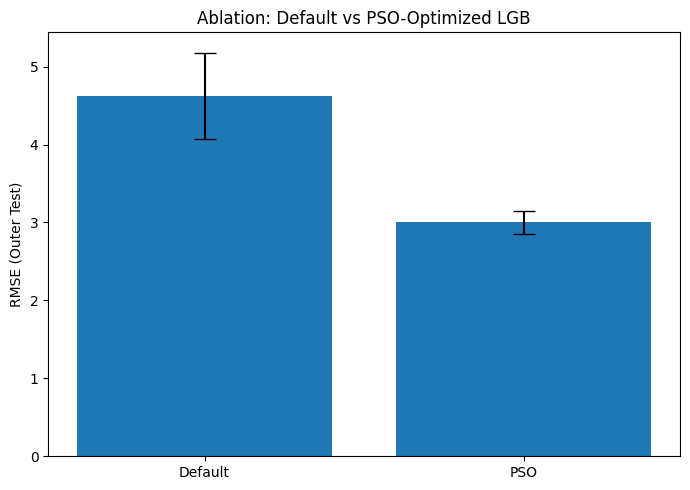


Final averaged LGB parameters:
{'boosting_type': 'gbdt', 'objective': 'regression', 'metric': 'rmse', 'num_leaves': 36, 'max_depth': 7, 'learning_rate': 0.297615, 'n_estimators': 477, 'feature_fraction': 0.624849, 'min_child_samples': 7, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}

Final Training Metrics:
R2: 0.9974
RMSE: 0.8207
RRMSE: 1.0756
NRMSE: 0.0258
MAE: 0.4244
MAPE: 1.5460
MEDAE: 0.1928

Final Locked Test Metrics:
R2: 0.9502
RMSE: 3.8275
RRMSE: 5.4291
NRMSE: 0.1169
MAE: 2.6618
MAPE: 9.0718
MEDAE: 1.7706


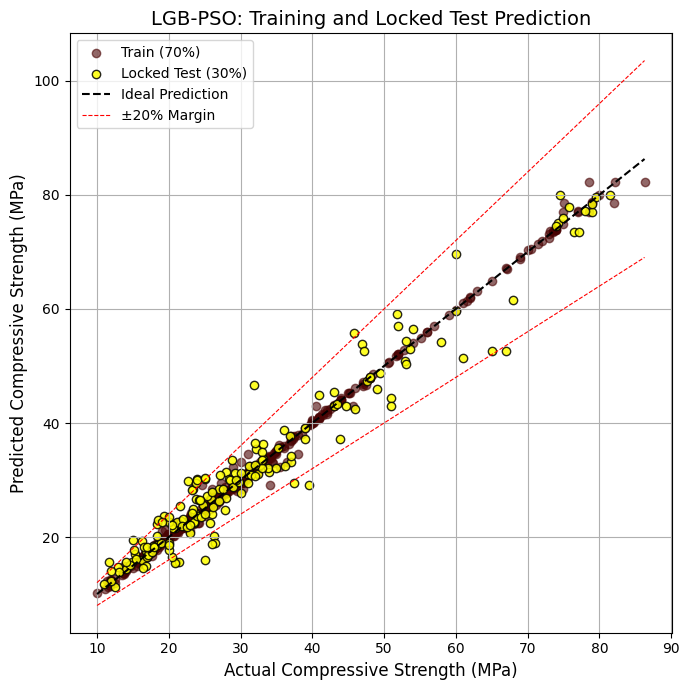

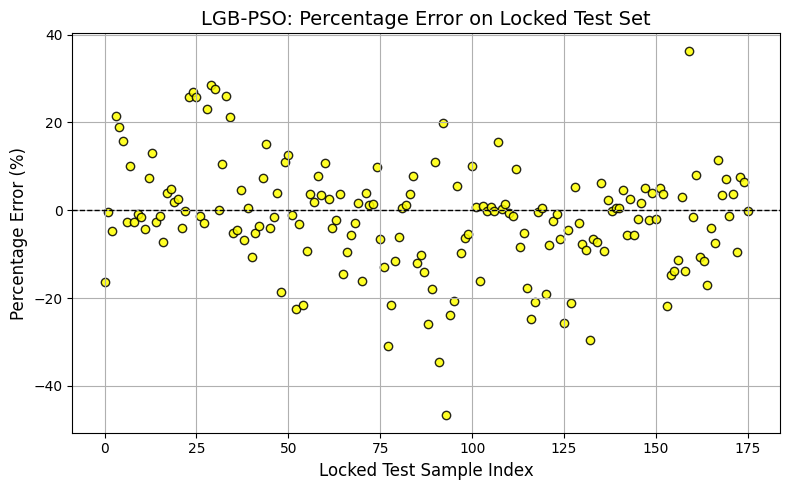


All LGB-PSO results saved in: lgb_pso_grouped_nestedcv_outputs_corrected


In [ ]:
# !pip -q install lightgbm pyswarm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, time
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from pyswarm import pso
from scipy.stats import bootstrap
import lightgbm as lgb

# ============================================================
# LightGBM-PSO Nested Grouped CV with Saved Train/Test Indices
# ============================================================

OUT_DIR = "lgb_pso_grouped_nestedcv_outputs_corrected"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED = 42

# PSO meta-parameters
PSO_CONFIG = dict(
    swarmsize=20,
    maxiter=25,
    omega=0.7,
    phip=1.5,
    phig=1.5
)

# Search bounds for LGB:
# [num_leaves, max_depth, learning_rate, n_estimators, feature_fraction, min_child_samples]
LB = [10, 3, 0.01, 50, 0.5, 5]
UB = [80, 30, 0.3, 500, 1.0, 50]

# ============================================================
# 1. Load corrected dataset and saved indices
# ============================================================

df = pd.read_excel("Coconut fiber data.xlsx")

TARGET_COL = "Compressive Strength (MPa)"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Use Source as grouping variable
if "Source" in df.columns:
    groups = df["Source"].reset_index(drop=True)
else:
    groups = pd.Series(np.arange(len(df)))

# Load previously saved train/test indices
train_idx = np.load("train_idx.npy")
test_idx = np.load("test_idx.npy")

# Safety checks
assert len(df) == len(train_idx) + len(test_idx), "Error: train/test indices do not cover the full dataset."
assert len(set(train_idx).intersection(set(test_idx))) == 0, "Error: train/test index overlap found."

# Create fixed training/development and locked test sets
X_train_all = X.iloc[train_idx].copy()
X_test_locked = X.iloc[test_idx].copy()

y_train_all = y.iloc[train_idx].copy()
y_test_locked = y.iloc[test_idx].copy()

groups_train_all = groups.iloc[train_idx].copy()
groups_test_locked = groups.iloc[test_idx].copy()

# Source-level leakage check
print("Total samples:", len(df))
print("Training/development samples:", len(X_train_all))
print("Locked test samples:", len(X_test_locked))

if "Source" in df.columns:
    train_sources = set(groups_train_all.unique())
    test_sources = set(groups_test_locked.unique())
    source_overlap = train_sources.intersection(test_sources)

    print("Training sources:", len(train_sources))
    print("Locked test sources:", len(test_sources))
    print("Overlapping sources:", len(source_overlap))

    assert len(source_overlap) == 0, f"Error: source overlap found: {source_overlap}"

# Save split verification
split_info = {
    "total_samples": len(df),
    "training_samples": len(X_train_all),
    "locked_test_samples": len(X_test_locked),
    "index_overlap": len(set(train_idx).intersection(set(test_idx)))
}

if "Source" in df.columns:
    split_info.update({
        "training_sources": len(train_sources),
        "locked_test_sources": len(test_sources),
        "source_overlap": len(source_overlap)
    })

with open(f"{OUT_DIR}/split_verification.json", "w") as f:
    json.dump(split_info, f, indent=2)

# ============================================================
# 2. Evaluation metrics
# ============================================================

def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # Avoid division by zero in MAPE
    denom = np.where(y_true == 0, np.finfo(float).eps, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100

    medae = np.median(np.abs(y_true - y_pred))

    # Additional metrics used in manuscript
    data_range = np.max(y_true) - np.min(y_true)
    mean_obs = np.mean(y_true)

    rrmse = (rmse / data_range) * 100 if data_range != 0 else np.nan
    nrmse = rmse / mean_obs if mean_obs != 0 else np.nan

    return {
        "r2": r2,
        "rmse": rmse,
        "rrmse": rrmse,
        "nrmse": nrmse,
        "mae": mae,
        "mape": mape,
        "medae": medae
    }

# ============================================================
# 3. Decode LGB hyperparameters
# ============================================================

def decode_lgb_params(params):
    num_leaves = int(round(params[0]))
    max_depth = int(round(params[1]))
    learning_rate = float(params[2])
    n_estimators = int(round(params[3]))
    feature_fraction = float(params[4])
    min_child_samples = int(round(params[5]))

    num_leaves = max(2, num_leaves)
    max_depth = max(1, max_depth)
    learning_rate = min(max(learning_rate, 0.001), 1.0)
    n_estimators = max(10, n_estimators)
    feature_fraction = min(max(feature_fraction, 0.1), 1.0)
    min_child_samples = max(1, min_child_samples)

    return dict(
        boosting_type="gbdt",
        objective="regression",
        metric="rmse",
        num_leaves=num_leaves,
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        feature_fraction=feature_fraction,
        min_child_samples=min_child_samples,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=-1
    )

# ============================================================
# 4. Inner CV objective function for PSO
# ============================================================

def lgb_inner_rmse(params, X_tr, y_tr, g_tr):
    hp = decode_lgb_params(params)

    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []

    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        X_inner_train = X_tr.iloc[tr_i]
        X_inner_val = X_tr.iloc[val_i]

        y_inner_train = y_tr.iloc[tr_i]
        y_inner_val = y_tr.iloc[val_i]

        model = lgb.LGBMRegressor(**hp)

        # Early stopping is allowed here because this is inner-validation data,
        # not the locked test set.
        model.fit(
            X_inner_train,
            y_inner_train,
            eval_set=[(X_inner_val, y_inner_val)],
            eval_metric="rmse",
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(0)
            ]
        )

        preds = model.predict(X_inner_val)
        rmses.append(np.sqrt(mean_squared_error(y_inner_val, preds)))

    return np.mean(rmses)

# ============================================================
# 5. Outer nested grouped cross-validation
# ============================================================

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)

oof_rows = []
tr_rows = []
fold_metrics = []
per_fold_params = []

rmse_default_per_fold = []
rmse_pso_per_fold = []

for fold, (tr_idx, te_idx) in enumerate(
    outer_cv.split(X_train_all, y_train_all, groups_train_all), 1
):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")

    X_tr = X_train_all.iloc[tr_idx].copy()
    X_te = X_train_all.iloc[te_idx].copy()

    y_tr = y_train_all.iloc[tr_idx].copy()
    y_te = y_train_all.iloc[te_idx].copy()

    g_tr = groups_train_all.iloc[tr_idx].copy()
    g_te = groups_train_all.iloc[te_idx].copy()

    # Confirm no source overlap inside outer fold
    fold_source_overlap = set(g_tr.unique()).intersection(set(g_te.unique()))
    assert len(fold_source_overlap) == 0, f"Source overlap in outer fold {fold}: {fold_source_overlap}"

    # -------------------------
    # Inner PSO optimization
    # -------------------------
    t0 = time.time()

    obj = lambda p: lgb_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)

    t_min = (time.time() - t0) / 60.0

    best_params = decode_lgb_params(opt_params)

    print(f"Fold {fold} PSO done in {t_min:.2f} min → {best_params}")

    per_fold_params.append({
        "fold": fold,
        "best_params": best_params
    })

    # -------------------------
    # Train PSO model on outer-training fold
    # No early stopping here, because outer-test fold should remain evaluation-only.
    # -------------------------
    model_pso = lgb.LGBMRegressor(**best_params)
    model_pso.fit(X_tr, y_tr)

    y_tr_pred = model_pso.predict(X_tr)
    y_te_pred = model_pso.predict(X_te)

    tr_rows.append(pd.DataFrame({
        "fold": fold,
        "role": "train",
        "y_true": y_tr.values,
        "y_pred": y_tr_pred
    }))

    oof_rows.append(pd.DataFrame({
        "fold": fold,
        "role": "outer_test",
        "y_true": y_te.values,
        "y_pred": y_te_pred
    }))

    metrics = evaluate(y_te, y_te_pred)
    metrics["fold"] = fold
    metrics["time_min"] = t_min

    fold_metrics.append(metrics)
    rmse_pso_per_fold.append(metrics["rmse"])

    # -------------------------
    # Default model for ablation
    # -------------------------
    model_default = lgb.LGBMRegressor(
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=-1
    )

    model_default.fit(X_tr, y_tr)
    y_te_default = model_default.predict(X_te)

    default_rmse = np.sqrt(mean_squared_error(y_te, y_te_default))
    rmse_default_per_fold.append(default_rmse)

# ============================================================
# 6. Save CV predictions and fold metrics
# ============================================================

oof_df = pd.concat(oof_rows, ignore_index=True)
tr_df = pd.concat(tr_rows, ignore_index=True)

oof_df.to_csv(f"{OUT_DIR}/oof_predictions_outer_test.csv", index=False)
tr_df.to_csv(f"{OUT_DIR}/train_predictions_per_fold.csv", index=False)

fold_df = pd.DataFrame(fold_metrics)
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)

with open(f"{OUT_DIR}/best_params_per_fold.json", "w") as f:
    json.dump(per_fold_params, f, indent=2)

TUNED_KEYS = [
    "num_leaves",
    "max_depth",
    "learning_rate",
    "n_estimators",
    "feature_fraction",
    "min_child_samples"
]

bp_df = pd.DataFrame([
    {"fold": d["fold"], **{k: d["best_params"][k] for k in TUNED_KEYS}}
    for d in per_fold_params
])

bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold_table.csv", index=False)

bp_summary = bp_df.drop(columns=["fold"]).agg(["mean", "std"]).round(6)
bp_summary.to_csv(f"{OUT_DIR}/best_params_mean_std.csv")

print("\nBest parameter summary:")
print(bp_summary)

# ============================================================
# 7. Mean ± SD and 95% CI from outer folds
# ============================================================

summary_rows = []

for metric in ["r2", "rmse", "rrmse", "nrmse", "mae", "mape", "medae"]:
    m = fold_df[metric].mean()
    s = fold_df[metric].std(ddof=1)
    ci = 1.96 * s / np.sqrt(OUTER_SPLITS)

    summary_rows.append({
        "metric": metric.upper(),
        "mean": m,
        "std": s,
        "ci95": ci,
        "lower_bound": m - ci,
        "upper_bound": m + ci
    })

cv_summary_df = pd.DataFrame(summary_rows)
cv_summary_df.to_csv(f"{OUT_DIR}/cv_mean_std_ci95_summary.csv", index=False)

print("\nCross-validation summary:")
print(cv_summary_df)

# ============================================================
# 8. Bootstrap CI using out-of-fold predictions
# ============================================================

def boot_ci(stat_fn, df_in, n_resamples=1000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(df_in))
    stats = []

    for _ in range(n_resamples):
        sampled_idx = rng.choice(idx, size=len(idx), replace=True)
        sample = df_in.iloc[sampled_idx]
        stats.append(stat_fn(sample))

    return np.quantile(stats, [0.025, 0.975])

r2_ci = boot_ci(lambda d: r2_score(d["y_true"], d["y_pred"]), oof_df)
rmse_ci = boot_ci(lambda d: np.sqrt(mean_squared_error(d["y_true"], d["y_pred"])), oof_df)
mae_ci = boot_ci(lambda d: mean_absolute_error(d["y_true"], d["y_pred"]), oof_df)
medae_ci = boot_ci(lambda d: np.median(np.abs(d["y_true"] - d["y_pred"])), oof_df)

bootstrap_ci_df = pd.DataFrame([
    {"metric": "R2", "boot_ci_lower": r2_ci[0], "boot_ci_upper": r2_ci[1]},
    {"metric": "RMSE", "boot_ci_lower": rmse_ci[0], "boot_ci_upper": rmse_ci[1]},
    {"metric": "MAE", "boot_ci_lower": mae_ci[0], "boot_ci_upper": mae_ci[1]},
    {"metric": "MedAE", "boot_ci_lower": medae_ci[0], "boot_ci_upper": medae_ci[1]},
])

bootstrap_ci_df.to_csv(f"{OUT_DIR}/ci95_bootstrap_oof.csv", index=False)

# ============================================================
# 9. Ablation study: Default vs PSO
# ============================================================

def ci95_width(values):
    values = np.asarray(values)

    b = bootstrap(
        (values,),
        np.mean,
        confidence_level=0.95,
        random_state=RANDOM_SEED
    )

    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)

err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

ablation_df = pd.DataFrame({
    "Model": ["Default LGB", "PSO-Optimized LGB"],
    "Mean RMSE": [rmse_def_mean, rmse_pso_mean],
    "CI95 Upper Width": [err_def, err_pso]
})

ablation_df.to_csv(f"{OUT_DIR}/ablation_default_vs_pso.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(
    ["Default", "PSO"],
    [rmse_def_mean, rmse_pso_mean],
    yerr=[err_def, err_pso],
    capsize=8
)

plt.ylabel("RMSE (Outer Test)")
plt.title("Ablation: Default vs PSO-Optimized LGB")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600, bbox_inches="tight")
plt.show()

# ============================================================
# 10. Final model training on full 70% training set
#     Locked test set used only after training for final evaluation
# ============================================================

best_params_avg = bp_summary.loc["mean"].to_dict()

final_hp = decode_lgb_params([
    best_params_avg["num_leaves"],
    best_params_avg["max_depth"],
    best_params_avg["learning_rate"],
    best_params_avg["n_estimators"],
    best_params_avg["feature_fraction"],
    best_params_avg["min_child_samples"]
])

print("\nFinal averaged LGB parameters:")
print(final_hp)

final_model = lgb.LGBMRegressor(**final_hp)

# IMPORTANT:
# Do NOT use X_test_locked or y_test_locked in eval_set here.
# The locked test set must remain untouched until final evaluation.
final_model.fit(X_train_all, y_train_all)

y_train_pred_final = final_model.predict(X_train_all)
y_test_pred_final = final_model.predict(X_test_locked)

# Final metrics
train_metrics = evaluate(y_train_all, y_train_pred_final)
test_metrics = evaluate(y_test_locked, y_test_pred_final)

print("\nFinal Training Metrics:")
for k, v in train_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

print("\nFinal Locked Test Metrics:")
for k, v in test_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

final_metrics_df = pd.DataFrame([
    {"phase": "Training", **train_metrics},
    {"phase": "Locked Test", **test_metrics}
])

final_metrics_df.to_csv(f"{OUT_DIR}/final_train_locked_test_metrics.csv", index=False)

# Save final predictions
pd.DataFrame({
    "y_true": y_train_all.values,
    "y_pred": y_train_pred_final
}).to_csv(f"{OUT_DIR}/final_train_predictions.csv", index=False)

pd.DataFrame({
    "y_true": y_test_locked.values,
    "y_pred": y_test_pred_final
}).to_csv(f"{OUT_DIR}/locked_test_predictions.csv", index=False)

# ============================================================
# 11. Regression plot: Training and locked test
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train_all,
    y_train_pred_final,
    color="#4A0404",
    alpha=0.6,
    label="Train (70%)"
)

plt.scatter(
    y_test_locked,
    y_test_pred_final,
    color="yellow",
    edgecolor="k",
    alpha=0.85,
    label="Locked Test (30%)"
)

min_val = min(
    y_train_all.min(),
    y_test_locked.min(),
    y_train_pred_final.min(),
    y_test_pred_final.min()
)

max_val = max(
    y_train_all.max(),
    y_test_locked.max(),
    y_train_pred_final.max(),
    y_test_pred_final.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "k--",
    label="Ideal Prediction"
)

plt.plot(
    [min_val, max_val],
    [min_val * 1.2, max_val * 1.2],
    "r--",
    lw=0.8,
    label="±20% Margin"
)

plt.plot(
    [min_val, max_val],
    [min_val * 0.8, max_val * 0.8],
    "r--",
    lw=0.8
)

plt.xlabel("Actual Compressive Strength (MPa)", fontsize=12)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=12)
plt.title("LGB-PSO: Training and Locked Test Prediction", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/LGB_PSO_locked_test_regression.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 12. Percentage error plot for locked test
# ============================================================

percentage_error = ((y_test_locked.values - y_test_pred_final) / y_test_locked.values) * 100

plt.figure(figsize=(8, 5))
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.scatter(
    range(len(percentage_error)),
    percentage_error,
    color="yellow",
    edgecolor="k",
    alpha=0.85
)

plt.xlabel("Locked Test Sample Index", fontsize=12)
plt.ylabel("Percentage Error (%)", fontsize=12)
plt.title("LGB-PSO: Percentage Error on Locked Test Set", fontsize=14)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/LGB_PSO_locked_test_percentage_error.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nAll LGB-PSO results saved in:", OUT_DIR)

Extreme Gradient Boosting

Total samples: 586
Training/development samples: 410
Locked test samples: 176

=== Outer Fold 1/5 ===
Stopping search: maximum iterations reached --> 25
Fold 1 PSO done in 5.04 min → {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 4, 'learning_rate': 0.08266261169094917, 'n_estimators': 500, 'subsample': 0.727159068913763, 'colsample_bytree': 0.5017870173834691, 'min_child_weight': 2, 'random_state': 42, 'n_jobs': -1}

=== Outer Fold 2/5 ===
Stopping search: maximum iterations reached --> 25
Fold 2 PSO done in 3.63 min → {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 5, 'learning_rate': 0.10999325904010963, 'n_estimators': 467, 'subsample': 0.5785911465560405, 'colsample_bytree': 0.7119024197596144, 'min_child_weight': 2, 'random_state': 42, 'n_jobs': -1}

=== Outer Fold 3/5 ===
Stopping search: maximum iterations reached --> 25
Fold 3 PSO done in 2.87 min → {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 7, 'learning_r

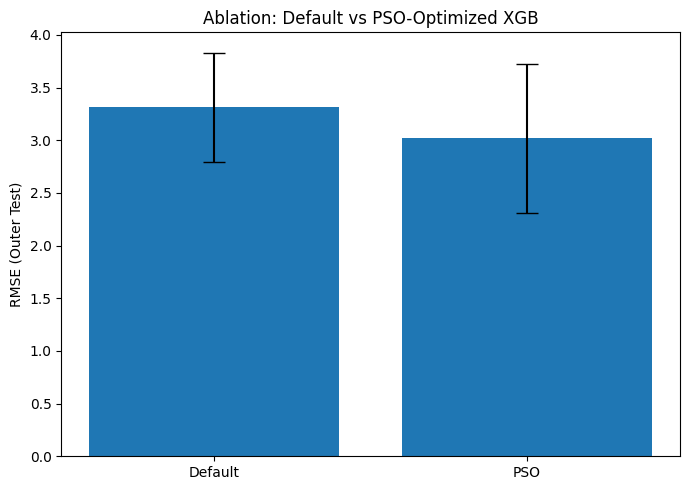


Final averaged XGB parameters:
{'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'max_depth': 8, 'learning_rate': 0.120069, 'n_estimators': 428, 'subsample': 0.586978, 'colsample_bytree': 0.583778, 'min_child_weight': 2, 'random_state': 42, 'n_jobs': -1}

Final Training Metrics:
R2: 0.9976
RMSE: 0.7811
RRMSE: 1.0238
NRMSE: 0.0246
MAE: 0.4596
MAPE: 1.7530
MEDAE: 0.2590

Final Locked Test Metrics:
R2: 0.9532
RMSE: 3.7109
RRMSE: 5.2638
NRMSE: 0.1134
MAE: 2.5820
MAPE: 8.8755
MEDAE: 1.4315


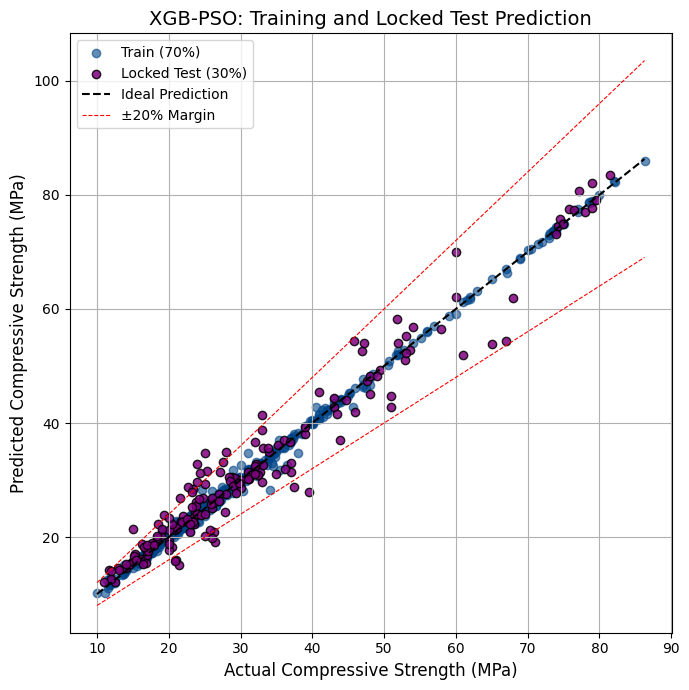

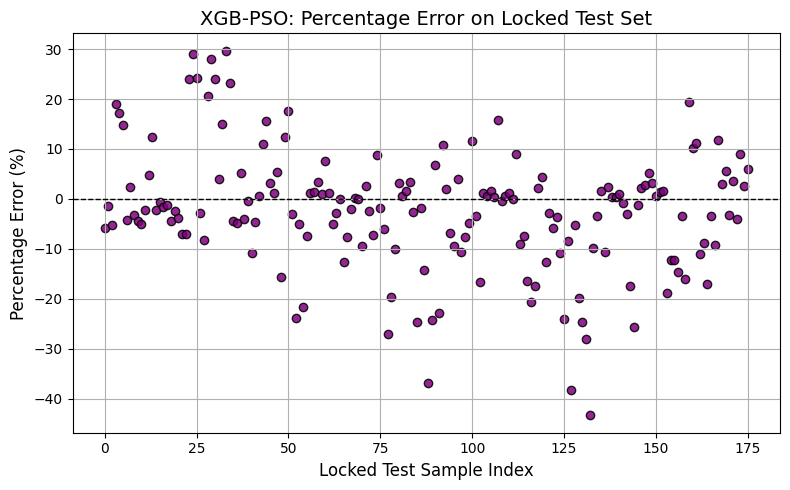


All XGB-PSO results saved in: xgb_pso_grouped_nestedcv_outputs_corrected


In [ ]:
!pip -q install xgboost pyswarm openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, time, warnings
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from pyswarm import pso
from scipy.stats import bootstrap
import xgboost as xgb

warnings.filterwarnings("ignore")

# ============================================================
# XGBoost-PSO Nested Grouped CV with Saved Train/Test Indices
# ============================================================

OUT_DIR = "xgb_pso_grouped_nestedcv_outputs_corrected"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED = 42

# PSO meta-parameters
PSO_CONFIG = dict(
    swarmsize=20,
    maxiter=25,
    omega=0.7,
    phip=1.5,
    phig=1.5
)

# Search bounds for XGB:
# [max_depth, learning_rate, n_estimators, subsample, colsample_bytree, min_child_weight]
LB = [3, 0.01, 50, 0.5, 0.5, 1]
UB = [15, 0.30, 500, 1.0, 1.0, 10]

# ============================================================
# 1. Load corrected dataset and saved indices
# ============================================================

df = pd.read_excel("Coconut fiber data.xlsx")

TARGET_COL = "Compressive Strength (MPa)"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Use Source as grouping variable
if "Source" in df.columns:
    groups = df["Source"].reset_index(drop=True)
else:
    groups = pd.Series(np.arange(len(df)))

# Load previously saved train/test indices
train_idx = np.load("train_idx.npy")
test_idx = np.load("test_idx.npy")

# Safety checks
assert len(df) == len(train_idx) + len(test_idx), "Error: train/test indices do not cover the full dataset."
assert len(set(train_idx).intersection(set(test_idx))) == 0, "Error: train/test index overlap found."

# Create fixed training/development and locked test sets
X_train_all = X.iloc[train_idx].copy()
X_test_locked = X.iloc[test_idx].copy()

y_train_all = y.iloc[train_idx].copy()
y_test_locked = y.iloc[test_idx].copy()

groups_train_all = groups.iloc[train_idx].copy()
groups_test_locked = groups.iloc[test_idx].copy()

# Source-level leakage check
print("Total samples:", len(df))
print("Training/development samples:", len(X_train_all))
print("Locked test samples:", len(X_test_locked))

if "Source" in df.columns:
    train_sources = set(groups_train_all.unique())
    test_sources = set(groups_test_locked.unique())
    source_overlap = train_sources.intersection(test_sources)

    print("Training sources:", len(train_sources))
    print("Locked test sources:", len(test_sources))
    print("Overlapping sources:", len(source_overlap))

    assert len(source_overlap) == 0, f"Error: source overlap found: {source_overlap}"

# Save split verification
split_info = {
    "total_samples": len(df),
    "training_samples": len(X_train_all),
    "locked_test_samples": len(X_test_locked),
    "index_overlap": len(set(train_idx).intersection(set(test_idx)))
}

if "Source" in df.columns:
    split_info.update({
        "training_sources": len(train_sources),
        "locked_test_sources": len(test_sources),
        "source_overlap": len(source_overlap)
    })

with open(f"{OUT_DIR}/split_verification.json", "w") as f:
    json.dump(split_info, f, indent=2)

# ============================================================
# 2. Evaluation metrics
# ============================================================

def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # Avoid division by zero in MAPE
    denom = np.where(y_true == 0, np.finfo(float).eps, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100

    medae = np.median(np.abs(y_true - y_pred))

    # Additional metrics used in manuscript
    data_range = np.max(y_true) - np.min(y_true)
    mean_obs = np.mean(y_true)

    rrmse = (rmse / data_range) * 100 if data_range != 0 else np.nan
    nrmse = rmse / mean_obs if mean_obs != 0 else np.nan

    return {
        "r2": r2,
        "rmse": rmse,
        "rrmse": rrmse,
        "nrmse": nrmse,
        "mae": mae,
        "mape": mape,
        "medae": medae
    }

# ============================================================
# 3. Decode XGB hyperparameters
# ============================================================

def decode_xgb_params(params):
    max_depth = int(round(params[0]))
    learning_rate = float(params[1])
    n_estimators = int(round(params[2]))
    subsample = float(params[3])
    colsample_bytree = float(params[4])
    min_child_weight = int(round(params[5]))

    max_depth = max(1, max_depth)
    learning_rate = min(max(learning_rate, 0.001), 1.0)
    n_estimators = max(10, n_estimators)
    subsample = min(max(subsample, 0.1), 1.0)
    colsample_bytree = min(max(colsample_bytree, 0.1), 1.0)
    min_child_weight = max(1, min_child_weight)

    return dict(
        objective="reg:squarederror",
        eval_metric="rmse",
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

# ============================================================
# 4. Inner CV objective function for PSO
# ============================================================

def xgb_inner_rmse(params, X_tr, y_tr, g_tr):
    hp = decode_xgb_params(params)

    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []

    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        X_inner_train = X_tr.iloc[tr_i]
        X_inner_val = X_tr.iloc[val_i]

        y_inner_train = y_tr.iloc[tr_i]
        y_inner_val = y_tr.iloc[val_i]

        model = xgb.XGBRegressor(**hp)
        model.fit(X_inner_train, y_inner_train)

        preds = model.predict(X_inner_val)
        rmses.append(np.sqrt(mean_squared_error(y_inner_val, preds)))

    return np.mean(rmses)

# ============================================================
# 5. Outer nested grouped cross-validation
# ============================================================

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)

oof_rows = []
tr_rows = []
fold_metrics = []
per_fold_params = []

rmse_default_per_fold = []
rmse_pso_per_fold = []

for fold, (tr_idx, te_idx) in enumerate(
    outer_cv.split(X_train_all, y_train_all, groups_train_all), 1
):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")

    X_tr = X_train_all.iloc[tr_idx].copy()
    X_te = X_train_all.iloc[te_idx].copy()

    y_tr = y_train_all.iloc[tr_idx].copy()
    y_te = y_train_all.iloc[te_idx].copy()

    g_tr = groups_train_all.iloc[tr_idx].copy()
    g_te = groups_train_all.iloc[te_idx].copy()

    # Confirm no source overlap inside outer fold
    fold_source_overlap = set(g_tr.unique()).intersection(set(g_te.unique()))
    assert len(fold_source_overlap) == 0, f"Source overlap in outer fold {fold}: {fold_source_overlap}"

    # -------------------------
    # Inner PSO optimization
    # -------------------------
    t0 = time.time()

    obj = lambda p: xgb_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)

    t_min = (time.time() - t0) / 60.0

    best_params = decode_xgb_params(opt_params)

    print(f"Fold {fold} PSO done in {t_min:.2f} min → {best_params}")

    per_fold_params.append({
        "fold": fold,
        "best_params": best_params
    })

    # -------------------------
    # Train PSO model on outer-training fold
    # -------------------------
    model_pso = xgb.XGBRegressor(**best_params)
    model_pso.fit(X_tr, y_tr)

    y_tr_pred = model_pso.predict(X_tr)
    y_te_pred = model_pso.predict(X_te)

    tr_rows.append(pd.DataFrame({
        "fold": fold,
        "role": "train",
        "y_true": y_tr.values,
        "y_pred": y_tr_pred
    }))

    oof_rows.append(pd.DataFrame({
        "fold": fold,
        "role": "outer_test",
        "y_true": y_te.values,
        "y_pred": y_te_pred
    }))

    metrics = evaluate(y_te, y_te_pred)
    metrics["fold"] = fold
    metrics["time_min"] = t_min

    fold_metrics.append(metrics)
    rmse_pso_per_fold.append(metrics["rmse"])

    # -------------------------
    # Default model for ablation
    # -------------------------
    model_default = xgb.XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    model_default.fit(X_tr, y_tr)
    y_te_default = model_default.predict(X_te)

    default_rmse = np.sqrt(mean_squared_error(y_te, y_te_default))
    rmse_default_per_fold.append(default_rmse)

# ============================================================
# 6. Save CV predictions and fold metrics
# ============================================================

oof_df = pd.concat(oof_rows, ignore_index=True)
tr_df = pd.concat(tr_rows, ignore_index=True)

oof_df.to_csv(f"{OUT_DIR}/oof_predictions_outer_test.csv", index=False)
tr_df.to_csv(f"{OUT_DIR}/train_predictions_per_fold.csv", index=False)

fold_df = pd.DataFrame(fold_metrics)
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)

with open(f"{OUT_DIR}/best_params_per_fold.json", "w") as f:
    json.dump(per_fold_params, f, indent=2)

TUNED_KEYS = [
    "max_depth",
    "learning_rate",
    "n_estimators",
    "subsample",
    "colsample_bytree",
    "min_child_weight"
]

bp_df = pd.DataFrame([
    {"fold": d["fold"], **{k: d["best_params"][k] for k in TUNED_KEYS}}
    for d in per_fold_params
])

bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold_table.csv", index=False)

bp_summary = bp_df.drop(columns=["fold"]).agg(["mean", "std"]).round(6)
bp_summary.to_csv(f"{OUT_DIR}/best_params_mean_std.csv")

print("\nBest parameter summary:")
print(bp_summary)

# ============================================================
# 7. Mean ± SD and 95% CI from outer folds
# ============================================================

summary_rows = []

for metric in ["r2", "rmse", "rrmse", "nrmse", "mae", "mape", "medae"]:
    m = fold_df[metric].mean()
    s = fold_df[metric].std(ddof=1)
    ci = 1.96 * s / np.sqrt(OUTER_SPLITS)

    summary_rows.append({
        "metric": metric.upper(),
        "mean": m,
        "std": s,
        "ci95": ci,
        "lower_bound": m - ci,
        "upper_bound": m + ci
    })

cv_summary_df = pd.DataFrame(summary_rows)
cv_summary_df.to_csv(f"{OUT_DIR}/cv_mean_std_ci95_summary.csv", index=False)

print("\nCross-validation summary:")
print(cv_summary_df)

# ============================================================
# 8. Bootstrap CI using out-of-fold predictions
# ============================================================

def boot_ci(stat_fn, df_in, n_resamples=1000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(df_in))
    stats = []

    for _ in range(n_resamples):
        sampled_idx = rng.choice(idx, size=len(idx), replace=True)
        sample = df_in.iloc[sampled_idx]
        stats.append(stat_fn(sample))

    return np.quantile(stats, [0.025, 0.975])

r2_ci = boot_ci(lambda d: r2_score(d["y_true"], d["y_pred"]), oof_df)
rmse_ci = boot_ci(lambda d: np.sqrt(mean_squared_error(d["y_true"], d["y_pred"])), oof_df)
mae_ci = boot_ci(lambda d: mean_absolute_error(d["y_true"], d["y_pred"]), oof_df)
medae_ci = boot_ci(lambda d: np.median(np.abs(d["y_true"] - d["y_pred"])), oof_df)

bootstrap_ci_df = pd.DataFrame([
    {"metric": "R2", "boot_ci_lower": r2_ci[0], "boot_ci_upper": r2_ci[1]},
    {"metric": "RMSE", "boot_ci_lower": rmse_ci[0], "boot_ci_upper": rmse_ci[1]},
    {"metric": "MAE", "boot_ci_lower": mae_ci[0], "boot_ci_upper": mae_ci[1]},
    {"metric": "MedAE", "boot_ci_lower": medae_ci[0], "boot_ci_upper": medae_ci[1]},
])

bootstrap_ci_df.to_csv(f"{OUT_DIR}/ci95_bootstrap_oof.csv", index=False)

# ============================================================
# 9. Ablation study: Default vs PSO
# ============================================================

def ci95_width(values):
    values = np.asarray(values)

    b = bootstrap(
        (values,),
        np.mean,
        confidence_level=0.95,
        random_state=RANDOM_SEED
    )

    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)

err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

ablation_df = pd.DataFrame({
    "Model": ["Default XGB", "PSO-Optimized XGB"],
    "Mean RMSE": [rmse_def_mean, rmse_pso_mean],
    "CI95 Upper Width": [err_def, err_pso]
})

ablation_df.to_csv(f"{OUT_DIR}/ablation_default_vs_pso.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(
    ["Default", "PSO"],
    [rmse_def_mean, rmse_pso_mean],
    yerr=[err_def, err_pso],
    capsize=8
)

plt.ylabel("RMSE (Outer Test)")
plt.title("Ablation: Default vs PSO-Optimized XGB")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600, bbox_inches="tight")
plt.show()

# ============================================================
# 10. Final model training on full 70% training set
#     Locked test set used only after training for final evaluation
# ============================================================

best_params_avg = bp_summary.loc["mean"].to_dict()

final_hp = decode_xgb_params([
    best_params_avg["max_depth"],
    best_params_avg["learning_rate"],
    best_params_avg["n_estimators"],
    best_params_avg["subsample"],
    best_params_avg["colsample_bytree"],
    best_params_avg["min_child_weight"]
])

print("\nFinal averaged XGB parameters:")
print(final_hp)

final_model = xgb.XGBRegressor(**final_hp)
final_model.fit(X_train_all, y_train_all)

y_train_pred_final = final_model.predict(X_train_all)
y_test_pred_final = final_model.predict(X_test_locked)

# Final metrics
train_metrics = evaluate(y_train_all, y_train_pred_final)
test_metrics = evaluate(y_test_locked, y_test_pred_final)

print("\nFinal Training Metrics:")
for k, v in train_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

print("\nFinal Locked Test Metrics:")
for k, v in test_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

final_metrics_df = pd.DataFrame([
    {"phase": "Training", **train_metrics},
    {"phase": "Locked Test", **test_metrics}
])

final_metrics_df.to_csv(f"{OUT_DIR}/final_train_locked_test_metrics.csv", index=False)

# Save final predictions
pd.DataFrame({
    "y_true": y_train_all.values,
    "y_pred": y_train_pred_final
}).to_csv(f"{OUT_DIR}/final_train_predictions.csv", index=False)

pd.DataFrame({
    "y_true": y_test_locked.values,
    "y_pred": y_test_pred_final
}).to_csv(f"{OUT_DIR}/locked_test_predictions.csv", index=False)

# ============================================================
# 11. Regression plot: Training and locked test
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train_all,
    y_train_pred_final,
    color="#004488",
    alpha=0.6,
    label="Train (70%)"
)

plt.scatter(
    y_test_locked,
    y_test_pred_final,
    color="purple",
    edgecolor="k",
    alpha=0.85,
    label="Locked Test (30%)"
)

min_val = min(
    y_train_all.min(),
    y_test_locked.min(),
    y_train_pred_final.min(),
    y_test_pred_final.min()
)

max_val = max(
    y_train_all.max(),
    y_test_locked.max(),
    y_train_pred_final.max(),
    y_test_pred_final.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "k--",
    label="Ideal Prediction"
)

plt.plot(
    [min_val, max_val],
    [min_val * 1.2, max_val * 1.2],
    "r--",
    lw=0.8,
    label="±20% Margin"
)

plt.plot(
    [min_val, max_val],
    [min_val * 0.8, max_val * 0.8],
    "r--",
    lw=0.8
)

plt.xlabel("Actual Compressive Strength (MPa)", fontsize=12)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=12)
plt.title("XGB-PSO: Training and Locked Test Prediction", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/XGB_PSO_locked_test_regression.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 12. Percentage error plot for locked test
# ============================================================

percentage_error = ((y_test_locked.values - y_test_pred_final) / y_test_locked.values) * 100

plt.figure(figsize=(8, 5))
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.scatter(
    range(len(percentage_error)),
    percentage_error,
    color="purple",
    edgecolor="k",
    alpha=0.85
)

plt.xlabel("Locked Test Sample Index", fontsize=12)
plt.ylabel("Percentage Error (%)", fontsize=12)
plt.title("XGB-PSO: Percentage Error on Locked Test Set", fontsize=14)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/XGB_PSO_locked_test_percentage_error.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nAll XGB-PSO results saved in:", OUT_DIR)

**Artificial Neural Network**

Total samples: 586
Training/development samples: 410
Locked test samples: 176

=== Outer Fold 1/5 ===
Stopping search: maximum iterations reached --> 25
Fold 1 PSO done in 16.26 min → Neurons=85, LR=0.00568, Alpha=0.000010

=== Outer Fold 2/5 ===
Stopping search: maximum iterations reached --> 25
Fold 2 PSO done in 14.95 min → Neurons=61, LR=0.00950, Alpha=0.000897

=== Outer Fold 3/5 ===
Stopping search: maximum iterations reached --> 25
Fold 3 PSO done in 11.50 min → Neurons=49, LR=0.01874, Alpha=0.000010

=== Outer Fold 4/5 ===
Stopping search: maximum iterations reached --> 25
Fold 4 PSO done in 11.87 min → Neurons=43, LR=0.01770, Alpha=0.001000

=== Outer Fold 5/5 ===
Stopping search: maximum iterations reached --> 25
Fold 5 PSO done in 13.63 min → Neurons=86, LR=0.00895, Alpha=0.000987

Best parameter summary:
       neurons        lr     alpha
mean  64.80000  0.012112  0.000581
std   19.97999  0.005771  0.000522

Cross-validation summary:
  metric       mean       std      ci95 

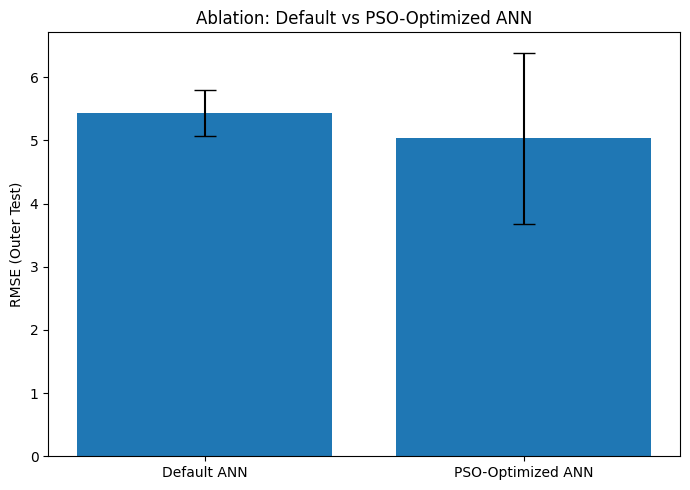


Final averaged ANN parameters:
Neurons=65, Learning rate=0.012112, Alpha=0.00058065

Final Training Metrics:
R2: 0.9738
RMSE: 2.5832
RRMSE: 3.3856
NRMSE: 0.0813
MAE: 1.9339
MAPE: 7.2581
MEDAE: 1.4458

Final Locked Test Metrics:
R2: 0.9275
RMSE: 4.6169
RRMSE: 6.5488
NRMSE: 0.1410
MAE: 3.3103
MAPE: 11.6247
MEDAE: 2.2463


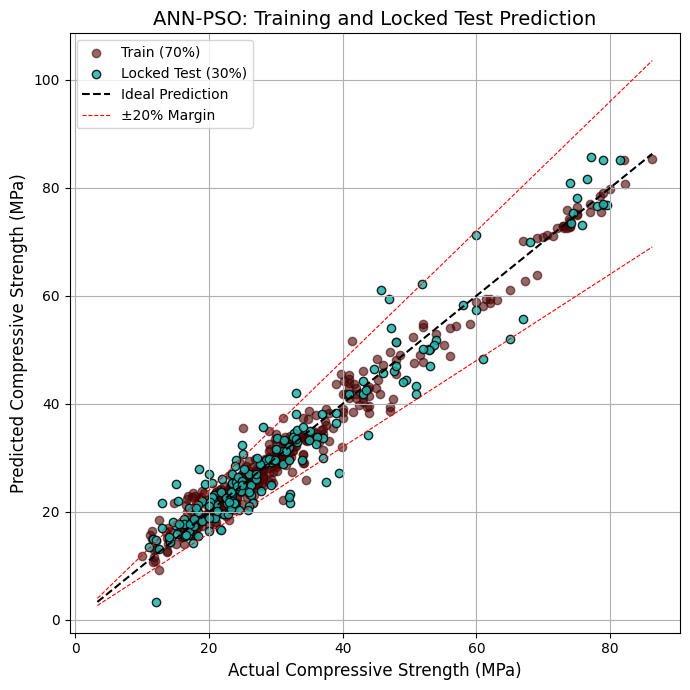

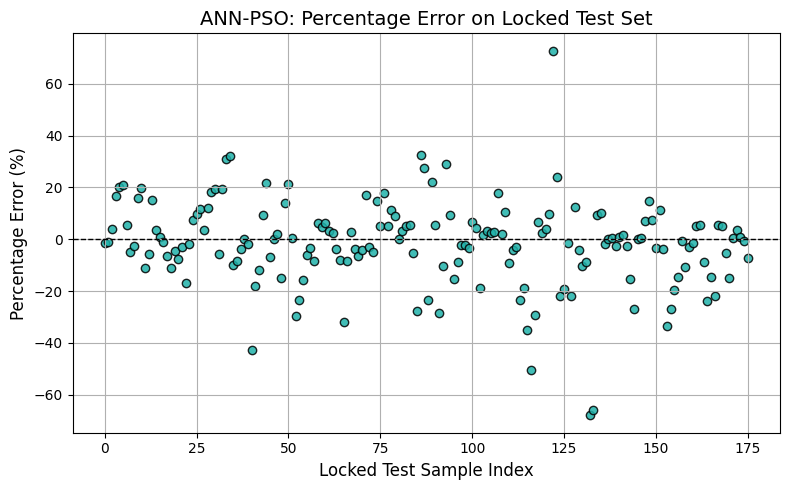


All ANN-PSO results saved in: ann_pso_grouped_nestedcv_outputs_corrected


In [ ]:
!pip -q install pyswarm openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, time, warnings
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error
from sklearn.neural_network import MLPRegressor
from pyswarm import pso
from scipy.stats import bootstrap

warnings.filterwarnings("ignore")

# ============================================================
# ANN-PSO Nested Grouped CV with Saved Train/Test Indices
# ============================================================

OUT_DIR = "ann_pso_grouped_nestedcv_outputs_corrected"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED = 42

# PSO meta-parameters
PSO_CONFIG = dict(
    swarmsize=20,
    maxiter=25,
    omega=0.7,
    phip=1.5,
    phig=1.5
)

# Search bounds for ANN:
# [hidden_layer_neurons, learning_rate_init, alpha]
LB = [20, 0.001, 1e-5]
UB = [100, 0.02, 1e-3]

# ============================================================
# 1. Load corrected dataset and saved indices
# ============================================================

df = pd.read_excel("Coconut fiber data.xlsx")

TARGET_COL = "Compressive Strength (MPa)"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Use Source as grouping variable
if "Source" in df.columns:
    groups = df["Source"].reset_index(drop=True)
else:
    groups = pd.Series(np.arange(len(df)))

# Load previously saved train/test indices
train_idx = np.load("train_idx.npy")
test_idx = np.load("test_idx.npy")

# Safety checks
assert len(df) == len(train_idx) + len(test_idx), "Error: train/test indices do not cover the full dataset."
assert len(set(train_idx).intersection(set(test_idx))) == 0, "Error: train/test index overlap found."

# Create fixed training/development and locked test sets
X_train_all = X.iloc[train_idx].copy()
X_test_locked = X.iloc[test_idx].copy()

y_train_all = y.iloc[train_idx].copy()
y_test_locked = y.iloc[test_idx].copy()

groups_train_all = groups.iloc[train_idx].copy()
groups_test_locked = groups.iloc[test_idx].copy()

# Source-level leakage check
print("Total samples:", len(df))
print("Training/development samples:", len(X_train_all))
print("Locked test samples:", len(X_test_locked))

if "Source" in df.columns:
    train_sources = set(groups_train_all.unique())
    test_sources = set(groups_test_locked.unique())
    source_overlap = train_sources.intersection(test_sources)

    print("Training sources:", len(train_sources))
    print("Locked test sources:", len(test_sources))
    print("Overlapping sources:", len(source_overlap))

    assert len(source_overlap) == 0, f"Error: source overlap found: {source_overlap}"

# Save split verification
split_info = {
    "total_samples": len(df),
    "training_samples": len(X_train_all),
    "locked_test_samples": len(X_test_locked),
    "index_overlap": len(set(train_idx).intersection(set(test_idx)))
}

if "Source" in df.columns:
    split_info.update({
        "training_sources": len(train_sources),
        "locked_test_sources": len(test_sources),
        "source_overlap": len(source_overlap)
    })

with open(f"{OUT_DIR}/split_verification.json", "w") as f:
    json.dump(split_info, f, indent=2)

# ============================================================
# 2. Evaluation metrics
# ============================================================

def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    denom = np.where(y_true == 0, np.finfo(float).eps, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100

    medae = median_absolute_error(y_true, y_pred)

    data_range = np.max(y_true) - np.min(y_true)
    mean_obs = np.mean(y_true)

    rrmse = (rmse / data_range) * 100 if data_range != 0 else np.nan
    nrmse = rmse / mean_obs if mean_obs != 0 else np.nan

    return {
        "r2": r2,
        "rmse": rmse,
        "rrmse": rrmse,
        "nrmse": nrmse,
        "mae": mae,
        "mape": mape,
        "medae": medae
    }

# ============================================================
# 3. Decode ANN hyperparameters
# ============================================================

def decode_ann_params(params):
    hidden_layer_size = int(round(params[0]))
    learning_rate_init = float(params[1])
    alpha = float(params[2])

    hidden_layer_size = max(1, hidden_layer_size)
    learning_rate_init = min(max(learning_rate_init, 1e-5), 1.0)
    alpha = max(alpha, 1e-8)

    return hidden_layer_size, learning_rate_init, alpha

# ============================================================
# 4. Inner CV objective function for PSO
# ============================================================

def ann_inner_rmse(params, X_tr, y_tr, g_tr):
    hidden_layer_size, learning_rate_init, alpha = decode_ann_params(params)

    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []

    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        X_inner_train = X_tr.iloc[tr_i]
        X_inner_val = X_tr.iloc[val_i]

        y_inner_train = y_tr.iloc[tr_i]
        y_inner_val = y_tr.iloc[val_i]

        # Fit scaler only on inner-training data
        scaler = StandardScaler()
        X_inner_train_s = scaler.fit_transform(X_inner_train)
        X_inner_val_s = scaler.transform(X_inner_val)

        model = MLPRegressor(
            hidden_layer_sizes=(hidden_layer_size,),
            learning_rate_init=learning_rate_init,
            alpha=alpha,
            activation="relu",
            solver="adam",
            max_iter=2000,
            random_state=RANDOM_SEED,
            early_stopping=True,
            n_iter_no_change=30,
            tol=1e-4
        )

        model.fit(X_inner_train_s, y_inner_train)
        preds = model.predict(X_inner_val_s)

        rmses.append(np.sqrt(mean_squared_error(y_inner_val, preds)))

    return np.mean(rmses)

# ============================================================
# 5. Outer nested grouped cross-validation
# ============================================================

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)

oof_rows = []
tr_rows = []
fold_metrics = []
per_fold_params = []

rmse_default_per_fold = []
rmse_pso_per_fold = []

for fold, (tr_idx, te_idx) in enumerate(
    outer_cv.split(X_train_all, y_train_all, groups_train_all), 1
):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")

    X_tr = X_train_all.iloc[tr_idx].copy()
    X_te = X_train_all.iloc[te_idx].copy()

    y_tr = y_train_all.iloc[tr_idx].copy()
    y_te = y_train_all.iloc[te_idx].copy()

    g_tr = groups_train_all.iloc[tr_idx].copy()
    g_te = groups_train_all.iloc[te_idx].copy()

    # Confirm no source overlap inside outer fold
    fold_source_overlap = set(g_tr.unique()).intersection(set(g_te.unique()))
    assert len(fold_source_overlap) == 0, f"Source overlap in outer fold {fold}: {fold_source_overlap}"

    # -------------------------
    # Inner PSO optimization
    # -------------------------
    t0 = time.time()

    obj = lambda p: ann_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)

    t_min = (time.time() - t0) / 60.0

    hidden_layer_opt, lr_opt, alpha_opt = decode_ann_params(opt_params)

    print(
        f"Fold {fold} PSO done in {t_min:.2f} min → "
        f"Neurons={hidden_layer_opt}, LR={lr_opt:.5f}, Alpha={alpha_opt:.6f}"
    )

    best_params = {
        "neurons": hidden_layer_opt,
        "lr": lr_opt,
        "alpha": alpha_opt
    }

    per_fold_params.append({
        "fold": fold,
        **best_params
    })

    # -------------------------
    # Train PSO model on outer-training fold
    # -------------------------
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    model_pso = MLPRegressor(
        hidden_layer_sizes=(hidden_layer_opt,),
        learning_rate_init=lr_opt,
        alpha=alpha_opt,
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=RANDOM_SEED,
        early_stopping=True,
        n_iter_no_change=30,
        tol=1e-4
    )

    model_pso.fit(X_tr_s, y_tr)

    y_tr_pred = model_pso.predict(X_tr_s)
    y_te_pred = model_pso.predict(X_te_s)

    tr_rows.append(pd.DataFrame({
        "fold": fold,
        "role": "train",
        "y_true": y_tr.values,
        "y_pred": y_tr_pred
    }))

    oof_rows.append(pd.DataFrame({
        "fold": fold,
        "role": "outer_test",
        "y_true": y_te.values,
        "y_pred": y_te_pred
    }))

    metrics = evaluate(y_te, y_te_pred)
    metrics["fold"] = fold
    metrics["time_min"] = t_min

    fold_metrics.append(metrics)
    rmse_pso_per_fold.append(metrics["rmse"])

    # -------------------------
    # Default ANN for ablation
    # -------------------------
    model_default = MLPRegressor(
        hidden_layer_sizes=(50,),
        learning_rate_init=0.001,
        alpha=0.0001,
        activation="relu",
        solver="adam",
        max_iter=3000,
        random_state=RANDOM_SEED,
        early_stopping=True,
        n_iter_no_change=30,
        tol=1e-4
    )

    model_default.fit(X_tr_s, y_tr)
    y_te_default = model_default.predict(X_te_s)

    default_rmse = np.sqrt(mean_squared_error(y_te, y_te_default))
    rmse_default_per_fold.append(default_rmse)

# ============================================================
# 6. Save CV predictions and fold metrics
# ============================================================

oof_df = pd.concat(oof_rows, ignore_index=True)
tr_df = pd.concat(tr_rows, ignore_index=True)

oof_df.to_csv(f"{OUT_DIR}/oof_predictions_outer_test.csv", index=False)
tr_df.to_csv(f"{OUT_DIR}/train_predictions_per_fold.csv", index=False)

fold_df = pd.DataFrame(fold_metrics)
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)

bp_df = pd.DataFrame(per_fold_params)
bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold.csv", index=False)

bp_summary = bp_df.drop(columns=["fold"]).agg(["mean", "std"]).round(6)
bp_summary.to_csv(f"{OUT_DIR}/best_params_mean_std.csv")

print("\nBest parameter summary:")
print(bp_summary)

with open(f"{OUT_DIR}/best_params_per_fold.json", "w") as f:
    json.dump(per_fold_params, f, indent=2)

# ============================================================
# 7. Mean ± SD and 95% CI from outer folds
# ============================================================

summary_rows = []

for metric in ["r2", "rmse", "rrmse", "nrmse", "mae", "mape", "medae"]:
    m = fold_df[metric].mean()
    s = fold_df[metric].std(ddof=1)
    ci = 1.96 * s / np.sqrt(OUTER_SPLITS)

    summary_rows.append({
        "metric": metric.upper(),
        "mean": m,
        "std": s,
        "ci95": ci,
        "lower_bound": m - ci,
        "upper_bound": m + ci
    })

cv_summary_df = pd.DataFrame(summary_rows)
cv_summary_df.to_csv(f"{OUT_DIR}/cv_mean_std_ci95_summary.csv", index=False)

print("\nCross-validation summary:")
print(cv_summary_df)

# ============================================================
# 8. Bootstrap CI using out-of-fold predictions
# ============================================================

def boot_ci(stat_fn, df_in, n_resamples=1000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(df_in))
    stats = []

    for _ in range(n_resamples):
        sampled_idx = rng.choice(idx, size=len(idx), replace=True)
        sample = df_in.iloc[sampled_idx]
        stats.append(stat_fn(sample))

    return np.quantile(stats, [0.025, 0.975])

r2_ci = boot_ci(lambda d: r2_score(d["y_true"], d["y_pred"]), oof_df)
rmse_ci = boot_ci(lambda d: np.sqrt(mean_squared_error(d["y_true"], d["y_pred"])), oof_df)
mae_ci = boot_ci(lambda d: mean_absolute_error(d["y_true"], d["y_pred"]), oof_df)
medae_ci = boot_ci(lambda d: median_absolute_error(d["y_true"], d["y_pred"]), oof_df)

bootstrap_ci_df = pd.DataFrame([
    {"metric": "R2", "boot_ci_lower": r2_ci[0], "boot_ci_upper": r2_ci[1]},
    {"metric": "RMSE", "boot_ci_lower": rmse_ci[0], "boot_ci_upper": rmse_ci[1]},
    {"metric": "MAE", "boot_ci_lower": mae_ci[0], "boot_ci_upper": mae_ci[1]},
    {"metric": "MedAE", "boot_ci_lower": medae_ci[0], "boot_ci_upper": medae_ci[1]},
])

bootstrap_ci_df.to_csv(f"{OUT_DIR}/ci95_bootstrap_oof.csv", index=False)

# ============================================================
# 9. Ablation study: Default vs PSO
# ============================================================

def ci95_width(values):
    values = np.asarray(values)

    b = bootstrap(
        (values,),
        np.mean,
        confidence_level=0.95,
        random_state=RANDOM_SEED
    )

    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)

err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

ablation_df = pd.DataFrame({
    "Model": ["Default ANN", "PSO-Optimized ANN"],
    "Mean RMSE": [rmse_def_mean, rmse_pso_mean],
    "CI95 Upper Width": [err_def, err_pso]
})

ablation_df.to_csv(f"{OUT_DIR}/ablation_default_vs_pso.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(
    ["Default ANN", "PSO-Optimized ANN"],
    [rmse_def_mean, rmse_pso_mean],
    yerr=[err_def, err_pso],
    capsize=8
)

plt.ylabel("RMSE (Outer Test)")
plt.title("Ablation: Default vs PSO-Optimized ANN")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600, bbox_inches="tight")
plt.show()

# ============================================================
# 10. Final model training on full 70% training set
#     Locked test set used only after training for final evaluation
# ============================================================

best_params_avg = bp_df[["neurons", "lr", "alpha"]].mean().to_dict()

hidden_layer_final = int(round(best_params_avg["neurons"]))
lr_final = float(best_params_avg["lr"])
alpha_final = float(best_params_avg["alpha"])

print("\nFinal averaged ANN parameters:")
print(
    f"Neurons={hidden_layer_final}, "
    f"Learning rate={lr_final:.6f}, "
    f"Alpha={alpha_final:.8f}"
)

# Fit scaler only on full training/development set
scaler_final = StandardScaler()
X_train_s = scaler_final.fit_transform(X_train_all)
X_test_s = scaler_final.transform(X_test_locked)

final_model = MLPRegressor(
    hidden_layer_sizes=(hidden_layer_final,),
    learning_rate_init=lr_final,
    alpha=alpha_final,
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=RANDOM_SEED,
    early_stopping=True,
    n_iter_no_change=30,
    tol=1e-4
)

final_model.fit(X_train_s, y_train_all)

y_train_pred_final = final_model.predict(X_train_s)
y_test_pred_final = final_model.predict(X_test_s)

# Final metrics
train_metrics = evaluate(y_train_all, y_train_pred_final)
test_metrics = evaluate(y_test_locked, y_test_pred_final)

print("\nFinal Training Metrics:")
for k, v in train_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

print("\nFinal Locked Test Metrics:")
for k, v in test_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

final_metrics_df = pd.DataFrame([
    {"phase": "Training", **train_metrics},
    {"phase": "Locked Test", **test_metrics}
])

final_metrics_df.to_csv(f"{OUT_DIR}/final_train_locked_test_metrics.csv", index=False)

# Save final predictions
pd.DataFrame({
    "y_true": y_train_all.values,
    "y_pred": y_train_pred_final
}).to_csv(f"{OUT_DIR}/final_train_predictions.csv", index=False)

pd.DataFrame({
    "y_true": y_test_locked.values,
    "y_pred": y_test_pred_final
}).to_csv(f"{OUT_DIR}/locked_test_predictions.csv", index=False)

# ============================================================
# 11. Regression plot: Training and locked test
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train_all,
    y_train_pred_final,
    color="#4A0404",
    alpha=0.6,
    label="Train (70%)"
)

plt.scatter(
    y_test_locked,
    y_test_pred_final,
    color="lightseagreen",
    edgecolor="k",
    alpha=0.85,
    label="Locked Test (30%)"
)

min_val = min(
    y_train_all.min(),
    y_test_locked.min(),
    y_train_pred_final.min(),
    y_test_pred_final.min()
)

max_val = max(
    y_train_all.max(),
    y_test_locked.max(),
    y_train_pred_final.max(),
    y_test_pred_final.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "k--",
    label="Ideal Prediction"
)

plt.plot(
    [min_val, max_val],
    [min_val * 1.2, max_val * 1.2],
    "r--",
    lw=0.8,
    label="±20% Margin"
)

plt.plot(
    [min_val, max_val],
    [min_val * 0.8, max_val * 0.8],
    "r--",
    lw=0.8
)

plt.xlabel("Actual Compressive Strength (MPa)", fontsize=12)
plt.ylabel("Predicted Compressive Strength (MPa)", fontsize=12)
plt.title("ANN-PSO: Training and Locked Test Prediction", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/ANN_PSO_locked_test_regression.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 12. Percentage error plot for locked test
# ============================================================

percentage_error = ((y_test_locked.values - y_test_pred_final) / y_test_locked.values) * 100

plt.figure(figsize=(8, 5))
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.scatter(
    range(len(percentage_error)),
    percentage_error,
    color="lightseagreen",
    edgecolor="k",
    alpha=0.85
)

plt.xlabel("Locked Test Sample Index", fontsize=12)
plt.ylabel("Percentage Error (%)", fontsize=12)
plt.title("ANN-PSO: Percentage Error on Locked Test Set", fontsize=14)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/ANN_PSO_locked_test_percentage_error.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nAll ANN-PSO results saved in:", OUT_DIR)


**Error Plots Code**

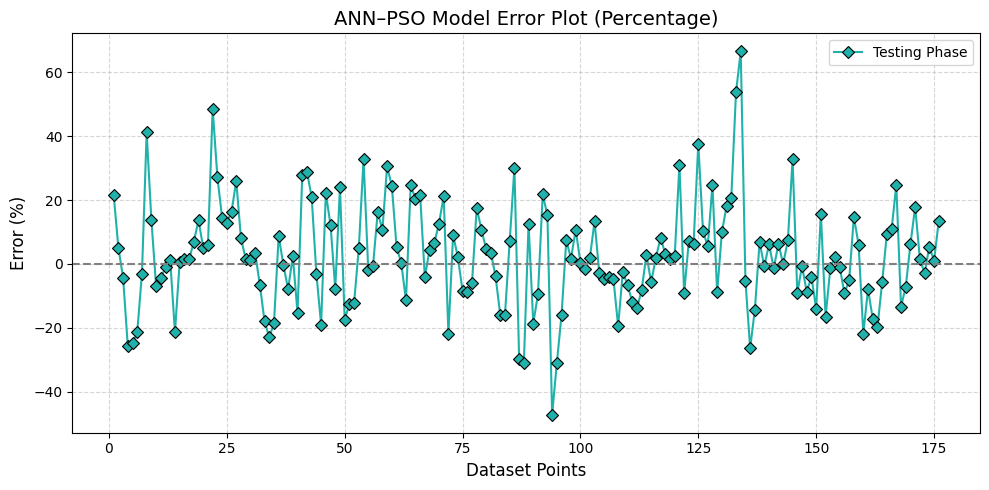

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
file_path = "/content/ANN Locked Test Predictions.xlsx"
test_df = pd.read_excel(file_path)

test_df['Error (%)'] = ((test_df['y_pred'] - test_df['y_true']) / test_df['y_true']) * 100

test_df['Sample'] = np.arange(1, len(test_df) + 1)

plt.figure(figsize=(10, 5))
plt.plot(test_df['Sample'], test_df['Error (%)'], 'D-',
         color='lightseagreen', label='Testing Phase',
         markersize=6, markeredgecolor='black', markeredgewidth=0.8)

plt.axhline(y=0, color='gray', linestyle='--')
plt.title("ANN–PSO Model Error Plot (Percentage)", fontsize=14)
plt.xlabel("Dataset Points", fontsize=12)
plt.ylabel("Error (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("ANN_PSO_Test_Error_Percentage_Plot.png", dpi=600)
plt.show()


**SHAP Analysis**

In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
OUT_DIR = "xgb_pso_shap_final"
os.makedirs(OUT_DIR, exist_ok=True)

DF_PATH = "Coconut fiber data.xlsx"
TARGET_COL = "Compressive Strength (MPa)"
df = pd.read_excel(DF_PATH)
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

train_idx = np.load("train_idx.npy")
test_idx  = np.load("test_idx.npy")
X_train_all = X.loc[train_idx]
X_test_locked = X.loc[test_idx]
y_train_all = y.loc[train_idx]
y_test_locked = y.loc[test_idx]

final_hp = dict(
    objective="reg:squarederror",
    eval_metric="rmse",
    max_depth=6,
    learning_rate=0.15029952891079157,
    n_estimators=438,
    subsample=0.7134969688114298,
    colsample_bytree=0.6316935627272379,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

final_model = xgb.XGBRegressor(**final_hp)
final_model.fit(X_train_all, y_train_all)

def eval_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    medae = float(np.median(np.abs(y_true - y_pred)))
    return r2, rmse, mae, mape, medae

y_test_pred = final_model.predict(X_test_locked)
r2_t, rmse_t, mae_t, mape_t, medae_t = eval_metrics(y_test_locked, y_test_pred)
print(f"\n=== Locked Test (exact split) ===\nR²={r2_t:.4f}, RMSE={rmse_t:.3f} MPa, "
      f"MAE={mae_t:.3f} MPa, MAPE={mape_t:.2f}%, MedAE={medae_t:.3f} MPa")

explainer = shap.Explainer(final_model, X_train_all)
shap_test = explainer(X_test_locked)

np.savetxt(f"{OUT_DIR}/shap_base_values.csv",
           np.atleast_1d(shap_test.base_values), delimiter=",", header="base_value", comments="")
pd.DataFrame(shap_test.values, columns=shap_test.feature_names).to_csv(
    f"{OUT_DIR}/shap_values_test.csv", index=False
)
pd.DataFrame({"y_true": y_test_locked.values, "y_pred": y_test_pred}).to_csv(
    f"{OUT_DIR}/shap_test_targets_preds.csv", index=False
)

#Beeswarm
fig = plt.figure()
shap.plots.beeswarm(shap_test, max_display=10, color=plt.cm.copper, show=False)
plt.title("SHAP Summary (Locked Test) – Contributions in MPa", fontsize=12)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/shap_beeswarm_test.png", dpi=600, bbox_inches="tight")
plt.close(fig)

#Mean SHAP bar
mean_abs = shap_test.abs.mean(0).values
feat_names = np.array(shap_test.feature_names)
order = np.argsort(mean_abs)
custom_color = '#8B5A2B'
plt.figure(figsize=(8, 6))
plt.barh(range(len(order)), mean_abs[order], color=custom_color)
plt.yticks(range(len(order)), feat_names[order])
plt.xlabel("Mean |SHAP| (MPa)", fontsize=12)
plt.title("Global Feature Importance (XGB, Test SHAP in MPa)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_importance_bar_test.png", dpi=600, bbox_inches="tight")
plt.close()

pd.DataFrame({
    "feature": feat_names[order],
    "mean_abs_shap_MPa": mean_abs[order]
}).to_csv(f"{OUT_DIR}/shap_importance_mean_abs_test.csv", index=False)

#Dependence plots
TOP_K = min(8, len(feat_names))
top_feats = feat_names[np.argsort(mean_abs)[-TOP_K:]][::-1]

for feat in top_feats:
    shap.plots.scatter(
        shap_test[:, feat],
        color=shap_test[:, feat],
        cmap=plt.cm.copper,
        show=False
    )
    plt.title(f"SHAP Dependence: {feat} (MPa contribution)", fontsize=11)
    plt.tight_layout()
    plt.gcf().savefig(
        f"{OUT_DIR}/shap_dependence_test_{re.sub(r'[^A-Za-z0-9._-]+','_', feat)}.png",
        dpi=600, bbox_inches="tight"
    )
    plt.close(plt.gcf())


=== Locked Test (exact split) ===
R²=0.9501, RMSE=3.830 MPa, MAE=2.578 MPa, MAPE=8.56%, MedAE=1.505 MPa


In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
OUT_DIR = "xgb_pso_shap_final"
os.makedirs(OUT_DIR, exist_ok=True)

DF_PATH = "Coconut fiber data.xlsx"
TARGET_COL = "Compressive Strength (MPa)"
df = pd.read_excel(DF_PATH)
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

#Load PSO Indices
train_idx = np.load("train_idx.npy")
test_idx  = np.load("test_idx.npy")
X_train_all = X.loc[train_idx]
X_test_locked = X.loc[test_idx]
y_train_all = y.loc[train_idx]
y_test_locked = y.loc[test_idx]

final_hp = dict(
    objective="reg:squarederror",
    eval_metric="rmse",
    max_depth=7.6,
    learning_rate=0.120069,
    n_estimators=428.2,
    subsample=0.586978,
    colsample_bytree=0.583778,
    min_child_weight=1.6,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

final_model = xgb.XGBRegressor(**final_hp)
final_model.fit(X_train_all, y_train_all)

def eval_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    medae = float(np.median(np.abs(y_true - y_pred)))
    return r2, rmse, mae, mape, medae

y_test_pred = final_model.predict(X_test_locked)
r2_t, rmse_t, mae_t, mape_t, medae_t = eval_metrics(y_test_locked, y_test_pred)
print(f"\n=== Locked Test (exact split) ===\nR²={r2_t:.4f}, RMSE={rmse_t:.3f} MPa, "
      f"MAE={mae_t:.3f} MPa, MAPE={mape_t:.2f}%, MedAE={medae_t:.3f} MPa")

pd.DataFrame({"y_true": y_test_locked.values, "y_pred": y_test_pred}).to_csv(
    f"{OUT_DIR}/locked_test_predictions.csv", index=False
)

explainer = shap.Explainer(final_model, X_train_all)
shap_test = explainer(X_test_locked)

N_TEST = len(X_test_locked)
SHAP_YLIM = (-16, 16)

np.savetxt(
    f"{OUT_DIR}/shap_base_values.csv",
    np.atleast_1d(shap_test.base_values),
    delimiter=",",
    header="base_value",
    comments=""
)
pd.DataFrame(shap_test.values, columns=shap_test.feature_names).to_csv(
    f"{OUT_DIR}/shap_values_test.csv", index=False
)
pd.DataFrame({"y_true": y_test_locked.values, "y_pred": y_test_pred}).to_csv(
    f"{OUT_DIR}/shap_test_targets_preds.csv", index=False
)

#Beeswarm
shap.plots.beeswarm(shap_test, max_display=10, color=plt.cm.copper, show=False)
plt.xlabel("SHAP value (MPa)")                           # unit on x-axis
plt.title(f"SHAP Summary (Locked Test, n={N_TEST})", fontsize=12)
plt.tight_layout()
plt.gcf().savefig(f"{OUT_DIR}/shap_beeswarm_test.png", dpi=600, bbox_inches="tight")
plt.close(plt.gcf())

#Mean SHAP bar
mean_abs = shap_test.abs.mean(0).values
feat_names = np.array(shap_test.feature_names)
order = np.argsort(mean_abs)

custom_color = '#8B5A2B'
plt.figure(figsize=(8, 6))
plt.barh(range(len(order)), mean_abs[order], color=custom_color)
plt.yticks(range(len(order)), feat_names[order])
plt.xlabel("Mean |SHAP| (MPa)", fontsize=12)
plt.title("SHAP bar plot of top features ranked by Feature Importance", fontsize=12)
plt.tight_layout()
plt.gcf().savefig(f"{OUT_DIR}/shap_importance_bar_test.png", dpi=600, bbox_inches="tight")
plt.close(plt.gcf())

pd.DataFrame({
    "feature": feat_names[order],
    "mean_abs_shap_MPa": mean_abs[order]
}).to_csv(f"{OUT_DIR}/shap_importance_mean_abs_test.csv", index=False)

#Dependence plots
TOP_K = min(8, len(feat_names))
top_feats = feat_names[np.argsort(mean_abs)[-TOP_K:]][::-1]

for feat in top_feats:
    shap.plots.scatter(
        shap_test[:, feat],
        color=shap_test[:, feat],
        cmap=plt.cm.copper,
        show=False
    )
    plt.ylim(SHAP_YLIM)
    plt.ylabel("SHAP value (MPa)")
    plt.title(f"SHAP Dependence: {feat} (contribution, n={N_TEST})", fontsize=11)

    fig = plt.gcf()
    axes = fig.get_axes()
    if len(axes) > 1:
        cb_ax = axes[-1]
        cb_ax.set_ylabel("")
        for txt in cb_ax.texts:
            txt.set_visible(False)

    plt.tight_layout()
    fig.savefig(
        f"{OUT_DIR}/shap_dependence_test_{re.sub(r'[^A-Za-z0-9._-]+','_', feat)}.png",
        dpi=600, bbox_inches="tight"
    )
    plt.close(fig)

#Interaction dependence plots
pairs = [
    ("RCA (%)", "Water (kg/m³)"),
    ("Fiber (%)", "Cement (kg/m³)"),
    ("Cement (kg/m³)", "Water (kg/m³)"),
    ("RCA (%)", "NCA (kg/m³)")
]

for main_feat, interact_feat in pairs:
    if (main_feat in X_test_locked.columns) and (interact_feat in X_test_locked.columns):
        shap.plots.scatter(
            shap_test[:, main_feat],
            color=shap_test[:, interact_feat],
            cmap=plt.cm.copper,
            show=False
        )
        plt.ylim(SHAP_YLIM)
        plt.ylabel("SHAP value (MPa)")
        plt.title(f"SHAP Interaction: {main_feat} × {interact_feat} (MPa, n={N_TEST})", fontsize=11)

        fig = plt.gcf()
        axes = fig.get_axes()
        if len(axes) > 1:
            cb_ax = axes[-1]
            cb_ax.set_ylabel("")
            for txt in cb_ax.texts:
                txt.set_visible(False)
            cb_ax.set_ylabel(interact_feat)

        plt.tight_layout()
        fig.savefig(
            f"{OUT_DIR}/shap_interaction_{re.sub(r'[^A-Za-z0-9._-]+','_', main_feat)}"
            f"_X_{re.sub(r'[^A-Za-z0-9._-]+','_', interact_feat)}.png",
            dpi=600, bbox_inches="tight"
        )
        plt.close(fig)

print("\n[SHAP] Done. Outputs saved in:", OUT_DIR)


TypeError: 'float' object cannot be interpreted as an integer

In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
OUT_DIR = "xgb_pso_shap_final"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# Publication-ready font settings
# -----------------------------
mpl.rcParams.update({
    "font.size": 14,          # base font size
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

FIG_W, FIG_H = 6.8, 5.0  # adjust if needed for your journal layout

def format_axes(ax):
    ax.tick_params(axis="both", which="major", labelsize=13)
    ax.xaxis.label.set_size(15)
    ax.yaxis.label.set_size(15)
    ax.title.set_size(16)

def format_colorbar(fig):
    axes = fig.get_axes()
    if len(axes) > 1:
        cb_ax = axes[-1]
        cb_ax.tick_params(labelsize=13)
        cb_ax.yaxis.label.set_size(14)
        return cb_ax
    return None
# -----------------------------

DF_PATH = "Coconut fiber data.xlsx"
TARGET_COL = "Compressive Strength (MPa)"
df = pd.read_excel(DF_PATH)
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Load PSO Indices
train_idx = np.load("train_idx.npy")
test_idx  = np.load("test_idx.npy")
X_train_all = X.loc[train_idx]
X_test_locked = X.loc[test_idx]
y_train_all = y.loc[train_idx]
y_test_locked = y.loc[test_idx]

final_hp = dict(
    objective="reg:squarederror",
    eval_metric="rmse",
    max_depth=8,
    learning_rate=0.120069,
    n_estimators=428,
    subsample=0.586978,
    colsample_bytree=0.583778,
    min_child_weight=2,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

final_model = xgb.XGBRegressor(**final_hp)
final_model.fit(X_train_all, y_train_all)

def eval_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    medae = float(np.median(np.abs(y_true - y_pred)))
    return r2, rmse, mae, mape, medae

y_test_pred = final_model.predict(X_test_locked)
r2_t, rmse_t, mae_t, mape_t, medae_t = eval_metrics(y_test_locked, y_test_pred)
print(f"\n=== Locked Test (exact split) ===\nR²={r2_t:.4f}, RMSE={rmse_t:.3f} MPa, "
      f"MAE={mae_t:.3f} MPa, MAPE={mape_t:.2f}%, MedAE={medae_t:.3f} MPa")

pd.DataFrame({"y_true": y_test_locked.values, "y_pred": y_test_pred}).to_csv(
    f"{OUT_DIR}/locked_test_predictions.csv", index=False
)

explainer = shap.Explainer(final_model, X_train_all)
shap_test = explainer(X_test_locked)

N_TEST = len(X_test_locked)
SHAP_YLIM = (-16, 16)

np.savetxt(
    f"{OUT_DIR}/shap_base_values.csv",
    np.atleast_1d(shap_test.base_values),
    delimiter=",",
    header="base_value",
    comments=""
)
pd.DataFrame(shap_test.values, columns=shap_test.feature_names).to_csv(
    f"{OUT_DIR}/shap_values_test.csv", index=False
)
pd.DataFrame({"y_true": y_test_locked.values, "y_pred": y_test_pred}).to_csv(
    f"{OUT_DIR}/shap_test_targets_preds.csv", index=False
)

# Beeswarm
shap.plots.beeswarm(shap_test, max_display=10, color=plt.cm.copper, show=False)
fig = plt.gcf()
fig.set_size_inches(FIG_W, FIG_H)
ax = plt.gca()
plt.xlabel("SHAP value (MPa)")
plt.title(f"SHAP Summary (Locked Test, n={N_TEST})")  # rcParams controls fontsize
format_axes(ax)
format_colorbar(fig)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/shap_beeswarm_test.png", dpi=600, bbox_inches="tight")
plt.close(fig)

# Mean SHAP bar
mean_abs = shap_test.abs.mean(0).values
feat_names = np.array(shap_test.feature_names)
order = np.argsort(mean_abs)

custom_color = '#8B5A2B'
fig, ax = plt.subplots(figsize=(8.2, 6.2))
ax.barh(range(len(order)), mean_abs[order], color=custom_color)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(feat_names[order])
ax.set_xlabel("Mean |SHAP| (MPa)")
ax.set_title("SHAP feature importance (mean |SHAP|)")
format_axes(ax)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/shap_importance_bar_test.png", dpi=600, bbox_inches="tight")
plt.close(fig)

pd.DataFrame({
    "feature": feat_names[order],
    "mean_abs_shap_MPa": mean_abs[order]
}).to_csv(f"{OUT_DIR}/shap_importance_mean_abs_test.csv", index=False)

# Dependence plots
TOP_K = min(8, len(feat_names))
top_feats = feat_names[np.argsort(mean_abs)[-TOP_K:]][::-1]

for feat in top_feats:
    shap.plots.scatter(
        shap_test[:, feat],
        color=shap_test[:, feat],
        cmap=plt.cm.copper,
        show=False
    )
    fig = plt.gcf()
    fig.set_size_inches(FIG_W, FIG_H)
    ax = plt.gca()

    plt.ylim(SHAP_YLIM)
    plt.ylabel("SHAP value (MPa)")
    plt.title(f"SHAP Dependence: {feat} (n={N_TEST})")

    format_axes(ax)
    cb_ax = format_colorbar(fig)
    if cb_ax is not None:
        # optional: remove any extra texts if present
        for txt in cb_ax.texts:
            txt.set_visible(False)

    plt.tight_layout()
    fig.savefig(
        f"{OUT_DIR}/shap_dependence_test_{re.sub(r'[^A-Za-z0-9._-]+','_', feat)}.png",
        dpi=600, bbox_inches="tight"
    )
    plt.close(fig)

# Interaction dependence plots
pairs = [
    ("RCA (%)", "Water (kg/m³)"),
    ("Fiber (%)", "Cement (kg/m³)"),
    ("Cement (kg/m³)", "Water (kg/m³)"),
    ("RCA (%)", "NCA (kg/m³)")
]

for main_feat, interact_feat in pairs:
    if (main_feat in X_test_locked.columns) and (interact_feat in X_test_locked.columns):
        shap.plots.scatter(
            shap_test[:, main_feat],
            color=shap_test[:, interact_feat],
            cmap=plt.cm.copper,
            show=False
        )
        fig = plt.gcf()
        fig.set_size_inches(FIG_W, FIG_H)
        ax = plt.gca()

        plt.ylim(SHAP_YLIM)
        plt.ylabel("SHAP value (MPa)")
        plt.title(f"SHAP Interaction: {main_feat} × {interact_feat} (n={N_TEST})")

        format_axes(ax)
        cb_ax = format_colorbar(fig)
        if cb_ax is not None:
            cb_ax.set_ylabel(interact_feat, fontsize=14)
            for txt in cb_ax.texts:
                txt.set_visible(False)

        plt.tight_layout()
        fig.savefig(
            f"{OUT_DIR}/shap_interaction_{re.sub(r'[^A-Za-z0-9._-]+','_', main_feat)}"
            f"_X_{re.sub(r'[^A-Za-z0-9._-]+','_', interact_feat)}.png",
            dpi=600, bbox_inches="tight"
        )
        plt.close(fig)

print("\n[SHAP] Done. Outputs saved in:", OUT_DIR)



=== Locked Test (exact split) ===
R²=0.9532, RMSE=3.711 MPa, MAE=2.582 MPa, MAPE=8.88%, MedAE=1.431 MPa


 98%|===================| 173/176 [00:11<00:00]       


[SHAP] Done. Outputs saved in: xgb_pso_shap_final


**SHAP Rank Stability**

In [ ]:
#!pip install pyswarm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, time, warnings, re
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from pyswarm import pso
from scipy.stats import bootstrap, kendalltau
import shap
import xgboost as xgb

warnings.filterwarnings("ignore")

OUT_DIR = "xgb_pso_cv_stability"
os.makedirs(OUT_DIR, exist_ok=True)

OUTER_SPLITS = 5
INNER_SPLITS = 3
RANDOM_SEED  = 42

PSO_CONFIG = dict(swarmsize=20, maxiter=25, omega=0.7, phip=1.5, phig=1.5)
LB = [3, 0.01, 50, 0.5, 0.5, 1]
UB = [15, 0.30, 500, 1.0, 1.0, 10]

df = pd.read_excel("Coconut fiber data.xlsx")
TARGET_COL = "Compressive Strength (MPa)"
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]
groups = df["Source"].reset_index(drop=True) if "Source" in df.columns else pd.Series(np.arange(len(df)))

gss = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_all, X_test_locked = X.iloc[train_idx], X.iloc[test_idx]
y_train_all, y_test_locked = y.iloc[train_idx], y.iloc[test_idx]
groups_train_all, groups_test_locked = groups.iloc[train_idx], groups.iloc[test_idx]

np.save("train_idx.npy", X_train_all.index.values)
np.save("test_idx.npy",  X_test_locked.index.values)

def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    medae = np.median(np.abs(y_true - y_pred))
    return r2, rmse, mae, mape, medae

def decode_xgb_params(params):
    max_depth        = int(round(params[0]))
    learning_rate    = float(params[1])
    n_estimators     = int(round(params[2]))
    subsample        = float(params[3])
    colsample_bytree = float(params[4])
    min_child_weight = int(round(params[5]))
    return dict(
        objective='reg:squarederror',
        eval_metric='rmse',
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=0
    )

def xgb_inner_rmse(params, X_tr, y_tr, g_tr):
    hp = decode_xgb_params(params)
    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    rmses = []
    for tr_i, val_i in inner_cv.split(X_tr, y_tr, g_tr):
        X_t, X_v = X_tr.iloc[tr_i], X_tr.iloc[val_i]
        y_t, y_v = y_tr.iloc[tr_i], y_tr.iloc[val_i]
        model = xgb.XGBRegressor(**hp)
        model.fit(X_t, y_t)
        preds = model.predict(X_v)
        rmses.append(np.sqrt(mean_squared_error(y_v, preds)))
    return np.mean(rmses)

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)
oof_rows, tr_rows, fold_metrics, per_fold_params = [], [], [], []
rmse_default_per_fold, rmse_pso_per_fold = [], []

for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_train_all, y_train_all, groups_train_all), 1):
    print(f"\n=== Outer Fold {fold}/{OUTER_SPLITS} ===")
    X_tr, X_te = X_train_all.iloc[tr_idx], X_train_all.iloc[te_idx]
    y_tr, y_te = y_train_all.iloc[tr_idx], y_train_all.iloc[te_idx]
    g_tr, g_te = groups_train_all.iloc[tr_idx], groups_train_all.iloc[te_idx]

    t0 = time.time()
    obj = lambda p: xgb_inner_rmse(p, X_tr, y_tr, g_tr)
    opt_params, _ = pso(obj, LB, UB, **PSO_CONFIG)
    t_min = (time.time() - t0) / 60.0
    hp = decode_xgb_params(opt_params)
    print(f"Fold {fold} PSO done in {t_min:.2f} min → {hp}")

    per_fold_params.append({"fold": fold, **hp})

    model = xgb.XGBRegressor(**hp)
    model.fit(X_tr, y_tr)
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    tr_rows.append(pd.DataFrame({"fold": fold, "role": "train", "y_true": y_tr, "y_pred": y_tr_pred}))
    oof_rows.append(pd.DataFrame({"fold": fold, "role": "test",  "y_true": y_te, "y_pred": y_te_pred}))

    r2t, rmset, maet, mapet, medaet = evaluate(y_te, y_te_pred)
    fold_metrics.append({
        "fold": fold, "r2": r2t, "rmse": rmset, "mae": maet,
        "mape": mapet, "medae": medaet, "time_min": t_min
    })
    rmse_pso_per_fold.append(rmset)

    xgb_def = xgb.XGBRegressor(random_state=RANDOM_SEED)
    xgb_def.fit(X_tr, y_tr)
    y_def = xgb_def.predict(X_te)
    rmse_default_per_fold.append(np.sqrt(mean_squared_error(y_te, y_def)))

    try:
        expl_fold = shap.Explainer(model, X_tr)
    except Exception:
        expl_fold = shap.TreeExplainer(model, X_tr)
    shap_fold = expl_fold(X_te)

    mean_abs_fold = shap_fold.abs.mean(0).values
    feat_names_fold = np.array(shap_fold.feature_names)

    fold_shap_df = pd.DataFrame({
        "fold": fold,
        "feature": feat_names_fold,
        "mean_abs_shap": mean_abs_fold
    })
    fold_shap_df.to_csv(f"{OUT_DIR}/fold_{fold}_mean_abs_shap.csv", index=False)

oof_df = pd.concat(oof_rows)
tr_df  = pd.concat(tr_rows)
oof_df.to_csv(f"{OUT_DIR}/oof_predictions.csv", index=False)
tr_df.to_csv (f"{OUT_DIR}/train_predictions.csv", index=False)

fold_df = pd.DataFrame(fold_metrics)
fold_df.to_csv(f"{OUT_DIR}/metrics_per_fold.csv", index=False)

bp_df = pd.DataFrame(per_fold_params)
bp_df.to_csv(f"{OUT_DIR}/best_params_per_fold.csv", index=False)

summary_rows = []
for metric in ["r2","rmse","mae","mape","medae"]:
    m = fold_df[metric].mean()
    s = fold_df[metric].std(ddof=1)
    ci = 1.96 * s / np.sqrt(OUTER_SPLITS)
    summary_rows.append({"metric": metric.upper(), "mean": m, "std": s, "ci95": ci})
pd.DataFrame(summary_rows).to_csv(f"{OUT_DIR}/ci95_from_outer_folds.csv", index=False)

def ci95_width(values):
    b = bootstrap((np.array(values),), np.mean, confidence_level=0.95, random_state=RANDOM_SEED)
    return b.confidence_interval[1] - np.mean(values)

rmse_def_mean = np.mean(rmse_default_per_fold)
rmse_pso_mean = np.mean(rmse_pso_per_fold)
err_def = ci95_width(rmse_default_per_fold)
err_pso = ci95_width(rmse_pso_per_fold)

plt.figure(figsize=(7,5))
plt.bar(["Default", "PSO"], [rmse_def_mean, rmse_pso_mean],
        yerr=[err_def, err_pso], capsize=8)
plt.ylabel("RMSE (outer test)")
plt.title("Ablation: Default vs PSO (mean ± 95% CI) – XGBoost")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ablation_rmse_bar.png", dpi=600)
plt.close()

#NEW: Rank Stability Aggregation
shap_list = []
for f in range(1, OUTER_SPLITS + 1):
    df_f = pd.read_csv(f"{OUT_DIR}/fold_{f}_mean_abs_shap.csv")
    shap_list.append(df_f)

all_shap = pd.concat(shap_list, ignore_index=True)

stab_mat = all_shap.pivot_table(index="feature", columns="fold", values="mean_abs_shap", aggfunc="mean").fillna(0.0)

rank_mat = stab_mat.rank(axis=0, ascending=False, method="average")

# Kendall's tau
tau_rows = []
folds = rank_mat.columns.tolist()
for i in range(len(folds)):
    for j in range(i+1, len(folds)):
        tau, p = kendalltau(rank_mat[folds[i]], rank_mat[folds[j]])
        tau_rows.append({"fold_i": int(folds[i]), "fold_j": int(folds[j]), "kendall_tau": float(tau), "p_value": float(p)})
tau_df = pd.DataFrame(tau_rows)
tau_df.to_csv(f"{OUT_DIR}/rank_stability_pairwise_kendall_tau.csv", index=False)

# Top-K overlap (Jaccard)
K = min(5, stab_mat.shape[0])
topk_rows = []
for i in range(len(folds)):
    Fi = set(rank_mat[folds[i]].sort_values().index[:K])
    for j in range(i+1, len(folds)):
        Fj = set(rank_mat[folds[j]].sort_values().index[:K])
        jacc = len(Fi & Fj) / len(Fi | Fj) if len(Fi | Fj) else 1.0
        topk_rows.append({"fold_i": int(folds[i]), "fold_j": int(folds[j]), "topK": K, "jaccard": float(jacc)})
pd.DataFrame(topk_rows).to_csv(f"{OUT_DIR}/rank_stability_top{K}_jaccard.csv", index=False)

# Summary (mean ± SD of ranks per feature)
rank_summary = pd.DataFrame({
    "feature": rank_mat.index,
    "mean_rank": rank_mat.mean(axis=1).values,
    "std_rank": rank_mat.std(axis=1, ddof=1).values
}).sort_values("mean_rank")
rank_summary.to_csv(f"{OUT_DIR}/rank_stability_summary.csv", index=False)

print("\n[STABILITY] Saved:")
print(" - rank_stability_pairwise_kendall_tau.csv")
print(f" - rank_stability_top{K}_jaccard.csv")
print(" - rank_stability_summary.csv")

numeric_cols = ["max_depth","learning_rate","n_estimators","subsample","colsample_bytree","min_child_weight"]
best_params_avg = bp_df[numeric_cols].mean().to_dict()

def decode_from_avg(avg_dict):
    return dict(
        objective='reg:squarederror', eval_metric='rmse',
        max_depth=int(round(avg_dict["max_depth"])),
        learning_rate=float(avg_dict["learning_rate"]),
        n_estimators=int(round(avg_dict["n_estimators"])),
        subsample=float(avg_dict["subsample"]),
        colsample_bytree=float(avg_dict["colsample_bytree"]),
        min_child_weight=int(round(avg_dict["min_child_weight"])),
        random_state=RANDOM_SEED, n_jobs=-1, verbosity=0
    )

final_hp = decode_from_avg(best_params_avg)
final_model = xgb.XGBRegressor(**final_hp)
final_model.fit(X_train_all, y_train_all)
y_test_pred  = final_model.predict(X_test_locked)

def evaluate_pack(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    medae = float(np.median(np.abs(y_true - y_pred)))
    return r2, rmse, mae, mape, medae

r2_t, rmse_t, mae_t, mape_t, medae_t = evaluate_pack(y_test_locked, y_test_pred)
print(f"\n[FINAL] Locked Test:\nR²={r2_t:.4f}, RMSE={rmse_t:.3f}, MAE={mae_t:.3f}, MAPE={mape_t:.2f}%, MedAE={medae_t:.3f}")
pd.DataFrame({"y_true": y_test_locked.values, "y_pred": y_test_pred}).to_csv(f"{OUT_DIR}/locked_test_predictions.csv", index=False)
print("\nAll results saved in:", OUT_DIR)



=== Outer Fold 1/5 ===


KeyboardInterrupt: 

**SHAP Rank Stability Plots (Kendall)**

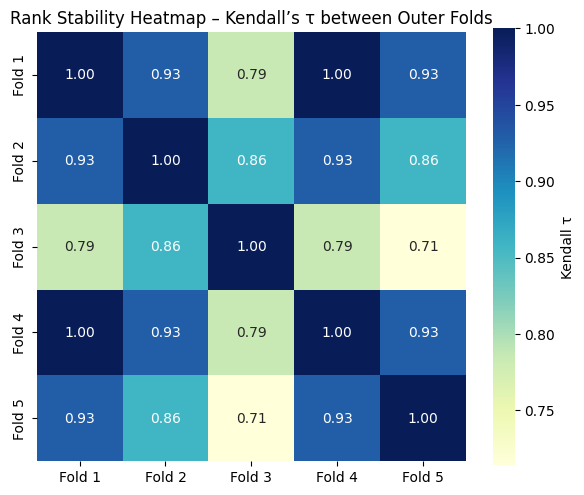

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

tau_df = pd.read_csv("rank_stability_pairwise_kendall_tau.csv")
folds = sorted(set(tau_df["fold_i"]).union(set(tau_df["fold_j"])))
n = len(folds)

tau_mat = np.ones((n, n))
for _, row in tau_df.iterrows():
    i, j = int(row["fold_i"]) - 1, int(row["fold_j"]) - 1
    tau_mat[i, j] = row["kendall_tau"]
    tau_mat[j, i] = row["kendall_tau"]

tau_matrix = pd.DataFrame(tau_mat, index=[f"Fold {i}" for i in folds], columns=[f"Fold {i}" for i in folds])

plt.figure(figsize=(6,5))
sns.heatmap(tau_matrix, annot=True, fmt=".2f", cmap="YlGnBu", square=True,
            cbar_kws={'label':"Kendall τ"})
plt.title("Rank Stability Heatmap – Kendall’s τ between Outer Folds")
plt.tight_layout()
plt.savefig("rank_stability_heatmap_tau.png", dpi=600)
plt.show()


**SHAP Rank Stability Plots (Jaccard)**

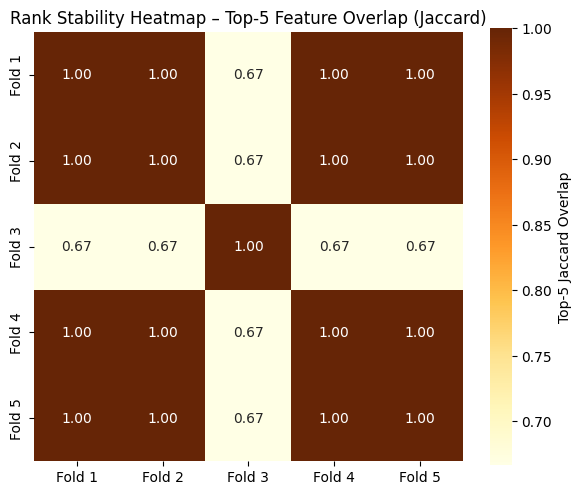

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

jac_df = pd.read_csv("rank_stability_top5_jaccard.csv")
folds = sorted(set(jac_df["fold_i"]).union(set(jac_df["fold_j"])))
n = len(folds)

jac_mat = np.ones((n, n))
for _, row in jac_df.iterrows():
    i, j = int(row["fold_i"]) - 1, int(row["fold_j"]) - 1
    jac_mat[i, j] = row["jaccard"]
    jac_mat[j, i] = row["jaccard"]

jac_matrix = pd.DataFrame(jac_mat, index=[f"Fold {i}" for i in folds], columns=[f"Fold {i}" for i in folds])

plt.figure(figsize=(6,5))
sns.heatmap(jac_matrix, annot=True, fmt=".2f", cmap="YlOrBr", square=True,
            cbar_kws={'label':"Top-5 Jaccard Overlap"})
plt.title("Rank Stability Heatmap – Top-5 Feature Overlap (Jaccard)")
plt.tight_layout()
plt.savefig("rank_stability_heatmap_jaccard.png", dpi=600)
plt.show()


**SHAP Rank Stability Plots (Summary)**

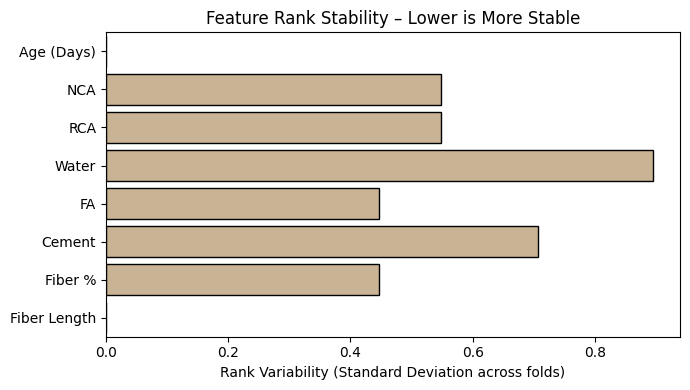

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
summary = pd.read_csv("rank_stability_summary.csv")
summary = summary.sort_values("mean_rank")

plt.figure(figsize=(7,4))
sns.barplot(x="std_rank", y="feature", data=summary, color="tan", edgecolor="black")
plt.xlabel("Rank Variability (Standard Deviation across folds)")
plt.ylabel("")
plt.title("Feature Rank Stability – Lower is More Stable")
plt.tight_layout()
plt.savefig("rank_variability_barplot.png", dpi=600)
plt.show()


**PDP and ALE plots**

  Cloning https://github.com/blent-ai/alepython.git to /tmp/pip-req-build-shvrlq_1
  Running command git clone --filter=blob:none --quiet https://github.com/blent-ai/alepython.git /tmp/pip-req-build-shvrlq_1
  Resolved https://github.com/blent-ai/alepython.git to commit 286350ab674980a32270db2a0b5ccca1380312a7
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.4 MB/s eta 0:00:00
  Created wheel for alepython: filename=alepython-0.1.dev17+g286350ab6-py3-none-any.whl size=15166 sha256=01ef6ea7db35ff2598c97536378da8cce529e6835c9762992268cafe085bdf0a
  Stored in directory: /tmp/pip-ephem-wheel-cache-pzzf7jod/wheels/d2/e1/e3/33b45167b4ec4d2c323f275b00b998330ca43c81c9266a63be
Successfully built alepython
Locked 30% Test — R²=0.9532, RMSE=3.711 MPa, MAE=2.582 MPa
Saved PDP figure: xgb_pso_pdp_all/pdp_all_features.png


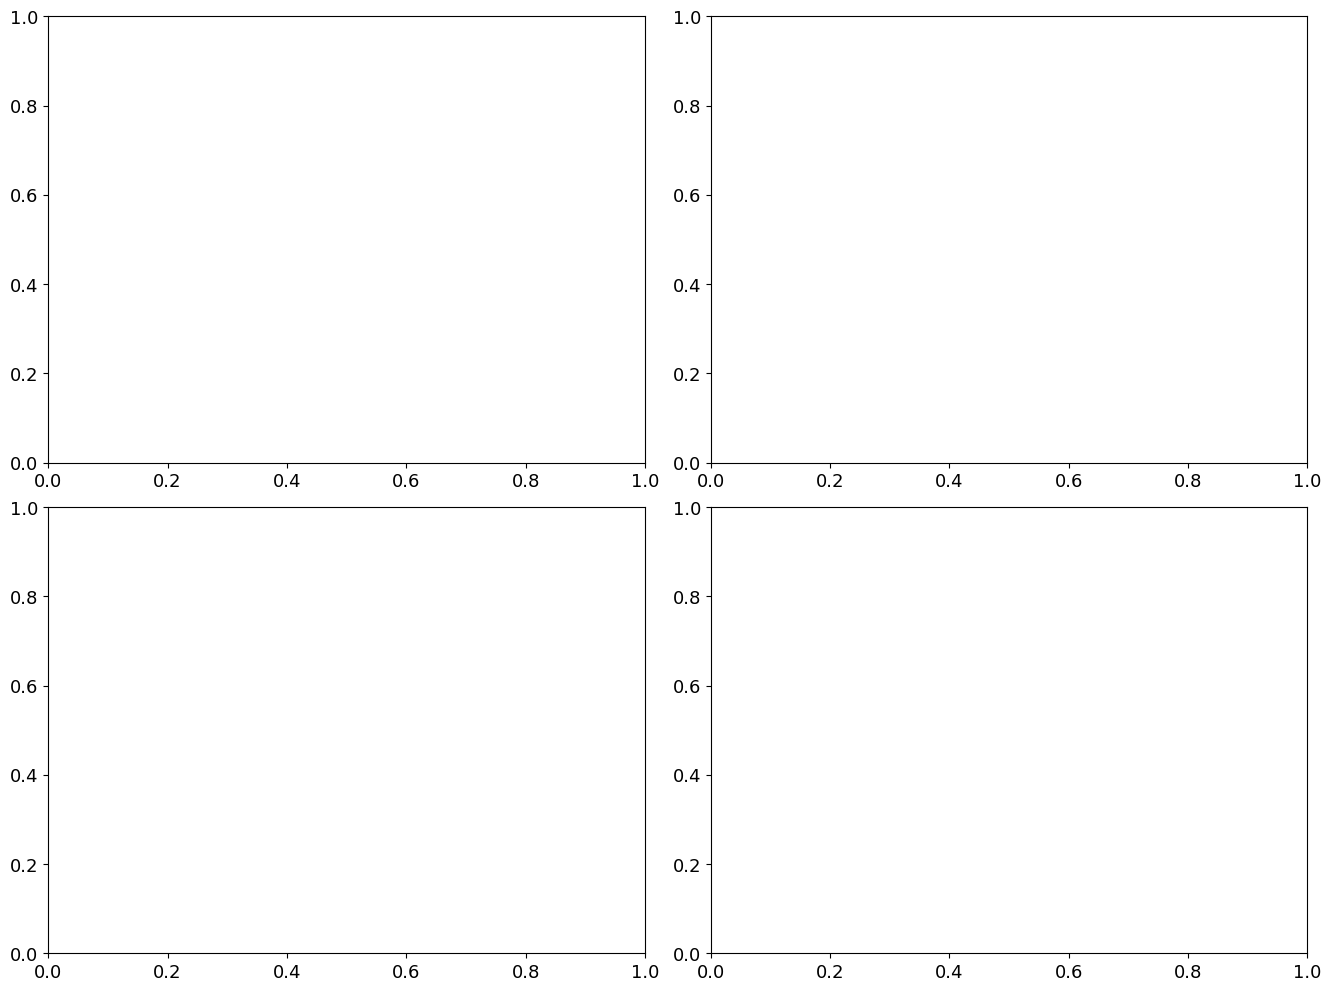

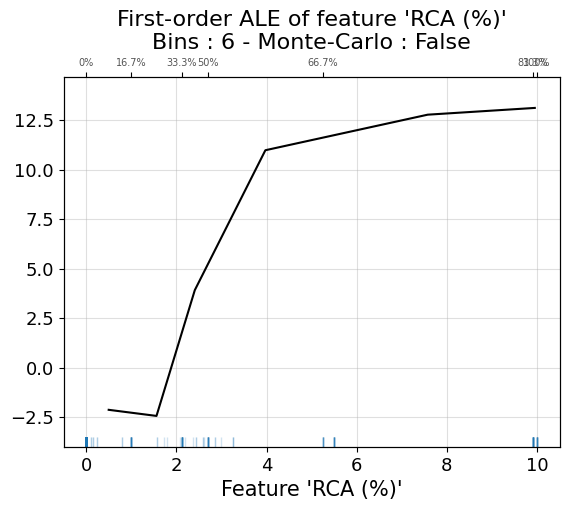

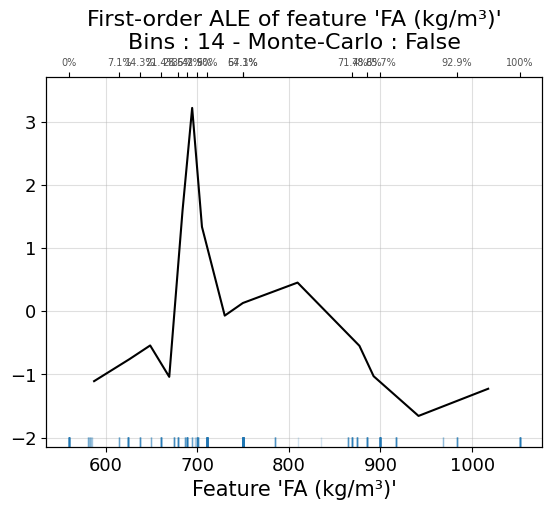

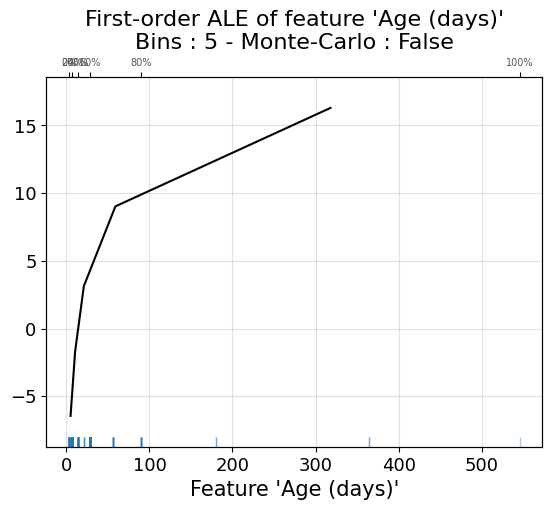

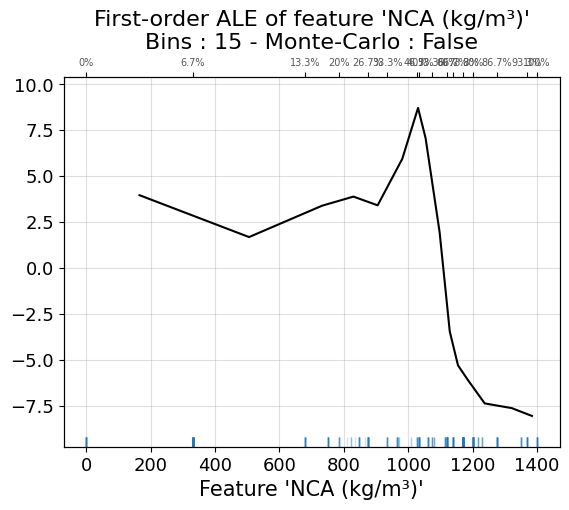

Saved: xgb_pso_pdp_all/pdp_all_features.png and xgb_pso_pdp_all/ale_top4.png


In [ ]:
!pip install git+https://github.com/blent-ai/alepython.git  # if needed for alepython

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay

try:
    from alepython import ale_plot
except ImportError as e:
    raise ImportError("alepython is not installed. Uncomment the pip line at the top and run it.") from e

OUT_DIR = "xgb_pso_pdp_all"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# Publication-ready font settings
# -----------------------------
mpl.rcParams.update({
    "font.size": 14,          # base
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})
# -----------------------------

FINAL_HP = dict(
    objective="reg:squarederror",
    eval_metric="rmse",
    max_depth=8,
    learning_rate=0.120069,
    n_estimators=428,
    subsample=0.586978,
    colsample_bytree=0.583778,
    min_child_weight=2,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

DF_PATH = "Coconut fiber data.xlsx"
TARGET_CANDIDATES = ["Compressive Strength (MPa)", "Compressive Strength"]

df = pd.read_excel(DF_PATH)

TARGET = None
for c in TARGET_CANDIDATES:
    if c in df.columns:
        TARGET = c
        break
if TARGET is None:
    raise ValueError("Couldn't find target column. Checked: " + ", ".join(TARGET_CANDIDATES))

X = df.drop(columns=[TARGET])
y = df[TARGET]

train_idx = np.load("train_idx.npy")
test_idx  = np.load("test_idx.npy")
X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

model = xgb.XGBRegressor(**FINAL_HP)
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
r2  = r2_score(y_test, y_pred_test)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred_test)))
mae  = mean_absolute_error(y_test, y_pred_test)
print(f"Locked 30% Test — R²={r2:.4f}, RMSE={rmse:.3f} MPa, MAE={mae:.3f} MPa")

def format_ax(ax):
    ax.tick_params(axis="both", which="major", labelsize=13)
    ax.xaxis.label.set_size(15)
    ax.yaxis.label.set_size(15)
    ax.title.set_size(16)

# -----------------------------
# PDP (All features)
# -----------------------------
features = list(X_train.columns)

n_features = len(features)
n_cols = 2 if n_features <= 8 else 3
n_rows = math.ceil(n_features / n_cols)

# Slightly larger panels for print
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6.6*n_cols, 4.6*n_rows),
    constrained_layout=True
)
axes = np.atleast_1d(axes).ravel()

BROWN = "#8B5A2B"
line_style = {"color": BROWN, "linewidth": 2.5}

for ax, feat in zip(axes, features):
    PartialDependenceDisplay.from_estimator(
        model,
        X_train,
        features=[feat],
        ax=ax,
        line_kw=line_style
    )
    ax.set_title(f"PDP: {feat}")  # rcParams controls fontsize
    ax.set_ylabel("Partial dependence (MPa)")
    ax.grid(alpha=0.25)
    format_ax(ax)

for k in range(len(features), len(axes)):
    fig.delaxes(axes[k])

# Harmonize y-limits
ymins, ymaxs = [], []
for ax in fig.get_axes():
    if len(ax.lines) > 0:
        y0, y1 = ax.get_ylim()
        ymins.append(y0); ymaxs.append(y1)
if ymins and ymaxs:
    common_min, common_max = min(ymins), max(ymaxs)
    for ax in fig.get_axes():
        if len(ax.lines) > 0:
            ax.set_ylim(common_min, common_max)

fig.suptitle("Partial Dependence Plots", fontsize=18)
pdp_path = f"{OUT_DIR}/pdp_all_features.png"
fig.savefig(pdp_path, dpi=600, bbox_inches="tight")
plt.close(fig)
print("Saved PDP figure:", pdp_path)

# -----------------------------
# ALE (Top 4 by feature importance)
# -----------------------------
importances = model.feature_importances_
order = np.argsort(importances)[::-1]
top_n = min(4, len(features))
TOP4 = [features[i] for i in order[:top_n]]

fig, axes = plt.subplots(2, 2, figsize=(13.2, 9.8), constrained_layout=True)
axes = axes.ravel()

for i, ax in enumerate(axes):
    if i < len(TOP4):
        feat = TOP4[i]
        tmp_ax = ale_plot(model, X_train, feat, bins=20)
        tmp_fig = tmp_ax.figure

        if tmp_ax.lines:
            xdata = tmp_ax.lines[0].get_xdata()
            ydata = tmp_ax.lines[0].get_ydata()
            ax.plot(xdata, ydata, color=BROWN, linewidth=2.5)
        else:
            print(f"[WARN] No ALE line found for feature '{feat}'.")

        ax.set_title(f"ALE: {feat}")  # rcParams controls fontsize
        ax.set_xlabel(feat)
        ax.set_ylabel("ALE effect (MPa)")
        ax.grid(alpha=0.25)
        format_ax(ax)

        plt.close(tmp_fig)
    else:
        fig.delaxes(ax)

# Harmonize y-limits across valid axes
valid_axes = [ax for ax in fig.get_axes() if len(ax.lines) > 0]
if valid_axes:
    ymins, ymaxs = zip(*[ax.get_ylim() for ax in valid_axes])
    ymin_common, ymax_common = min(ymins), max(ymaxs)
    for ax in valid_axes:
        ax.set_ylim(ymin_common, ymax_common)

fig.suptitle("Accumulated Local Effects", fontsize=18)
ale_path = f"{OUT_DIR}/ale_top4.png"
fig.savefig(ale_path, dpi=600, bbox_inches="tight")
plt.close(fig)

print("Saved:", pdp_path, "and", ale_path)


**ICE Plots**

In [ ]:
import os, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.inspection import PartialDependenceDisplay
import xgboost as xgb

OUT_DIR = "xgb_pso_ice_final"
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# Publication-ready font settings
# -----------------------------
mpl.rcParams.update({
    "font.size": 14,          # base
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})
# -----------------------------

DF_PATH = "Coconut fiber data.xlsx"
TARGET = "Compressive Strength (MPa)"

df = pd.read_excel(DF_PATH)
X = df.drop(columns=[TARGET])
y = df[TARGET]

train_idx = np.load("train_idx.npy")
test_idx  = np.load("test_idx.npy")

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

FINAL_HP = dict(
    objective="reg:squarederror",
    eval_metric="rmse",
    max_depth=8,
    learning_rate=0.120069,
    n_estimators=428,
    subsample=0.586978,
    colsample_bytree=0.583778,
    min_child_weight=2,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)


model = xgb.XGBRegressor(**FINAL_HP)
model.fit(X_train, y_train)

features = list(X_train.columns)
n = len(features)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.8*nrows))
axes = np.array(axes).reshape(-1)

brown = "#8B5A2B"
subsample = min(200, len(X_train))

ymins, ymaxs = [], []

for i, feat in enumerate(features):
    PartialDependenceDisplay.from_estimator(
        model,
        X_train,
        features=[feat],
        kind="individual",
        subsample=subsample,
        grid_resolution=100,
        line_kw={"color": brown, "alpha": 0.35, "linewidth": 1.2},
        ax=axes[i]
    )

    # Larger, print-friendly text
    axes[i].set_title(f"ICE: {feat}")  # rcParams controls size
    axes[i].set_ylabel("Predicted CS (MPa)")
    axes[i].set_xlabel(feat)

    # Ensure tick labels are readable
    axes[i].tick_params(axis="both", which="major", labelsize=13)

    axes[i].grid(alpha=0.2)
    ymins.append(axes[i].get_ylim()[0])
    ymaxs.append(axes[i].get_ylim()[1])

# remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# common y-limits for comparability
common_ymin, common_ymax = min(ymins), max(ymaxs)
for k in range(i + 1):
    axes[k].set_ylim(common_ymin, common_ymax)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(f"{OUT_DIR}/ice_all_features.png", dpi=600, bbox_inches="tight")
plt.close(fig)

print("Saved:", f"{OUT_DIR}/ice_all_features.png")


Saved: xgb_pso_ice_final/ice_all_features.png


**Taylor Diagram**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.grid_finder as gf
import mpl_toolkits.axisartist.floating_axes as fa

class TaylorDiagram:
    def __init__(self, obs_std, fig=None, rect=111, label='Actual'):
        self.obs_std = float(obs_std)

        tr = PolarAxes.PolarTransform()

        rlocs = np.array([0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99,1.0])
        tlocs = np.arccos(rlocs)                # polar angle
        gl1 = gf.FixedLocator(tlocs)
        tf1 = gf.DictFormatter(dict(zip(tlocs, [f"{r:.2g}" for r in rlocs])))

        self.smin, self.smax = 0, 1.6*self.obs_std

        gh = fa.GridHelperCurveLinear(
            tr, extremes=(0, np.pi/2, self.smin, self.smax),
            grid_locator1=gl1, tick_formatter1=tf1
        )

        if fig is None:
            fig = plt.figure(figsize=(8.8, 8.0))
        ax = fa.FloatingSubplot(fig, rect, grid_helper=gh)
        fig.add_subplot(ax)

        # angle axis (correlation)
        ax.axis['top'].set_axis_direction('bottom')
        ax.axis['top'].toggle(ticklabels=True, label=True)
        ax.axis['top'].major_ticklabels.set_axis_direction('top')
        ax.axis['top'].label.set_axis_direction('top')
        ax.axis['top'].label.set_text("Correlation coefficient")
        ax.axis['top'].label.set_fontsize(16)
        ax.axis['top'].major_ticklabels.set_fontsize(12)

        # measured SD (x) and simulated SD (y)
        ax.axis['left'].set_axis_direction('bottom')
        ax.axis['left'].toggle(ticklabels=True, label=True)
        ax.axis['left'].label.set_text("Measured Standard Deviation")
        ax.axis['left'].label.set_fontsize(15)
        ax.axis['left'].major_ticklabels.set_fontsize(12)

        ax.axis['right'].set_axis_direction('top')
        ax.axis['right'].toggle(ticklabels=True, label=True)
        ax.axis['right'].label.set_text("Simulated Standard Deviation")
        ax.axis['right'].label.set_fontsize(15)
        ax.axis['right'].major_ticklabels.set_fontsize(12)

        ax.axis['bottom'].set_visible(False)
        ax.grid(alpha=0.25)
        self._ax = ax
        self.ax = ax.get_aux_axes(tr)

        # reference star (observed) and its SD arc
        self.ref, = self.ax.plot([0], [self.obs_std], 'k*', ms=12, label=label)
        t = np.linspace(0, np.pi/2, 200)
        self.ax.plot(t, np.full_like(t, self.obs_std), 'k--', lw=1.0)
        self.ax.text(0.04, self.obs_std * 1.21, "Reference (Actual)",
             fontsize=12, ha='center', va='center')

        self.samplePoints = [self.ref]

    def add_sample(self, std, corr, **kwargs):
        l, = self.ax.plot(np.arccos(corr), std, **kwargs)
        self.samplePoints.append(l)
        return l

    def add_rmse_contours(self, levels=(4, 6, 9, 12, 18, 24, 30), **kwargs):
        rs, ts = np.meshgrid(
            np.linspace(self.smin, self.smax, 200),
            np.linspace(0, np.pi/2, 200)
        )
        rmse = np.sqrt(self.obs_std**2 + rs**2 - 2*self.obs_std*rs*np.cos(ts))
        cs = self.ax.contour(ts, rs, rmse, levels=levels,
                             colors='0.35', linewidths=1.2, **kwargs)

        self.ax.clabel(cs, inline=True, fmt=r"RMSE=%g", fontsize=11)
        return cs

def draw_taylor(obs_std, series, title="Taylor Diagram — Test Set", outfile="taylor_test.png"):
    """
    series: list of dicts with keys:
      name, std, corr, marker, mfc, mec
    """
    fig = plt.figure(figsize=(8.8, 8.0))
    dia = TaylorDiagram(obs_std, fig=fig, rect=111, label="Actual")

    dia.add_rmse_contours()
    handles = []
    labels  = []
    for s in series:
        h = dia.add_sample(
            std=s["std"], corr=s["corr"],
            marker=s.get("marker", "o"),
            ms=10, mfc=s.get("mfc","none"), mec=s.get("mec","k"),
            mew=2.0, linestyle=''
        )
        handles.append(h); labels.append(s["name"])

    leg = fig.legend(handles, labels, loc='upper right',
                     bbox_to_anchor=(0.98, 0.98), frameon=True,
                     framealpha=0.9, facecolor='white', edgecolor='0.7',
                     fontsize=12, ncol=1, borderpad=0.6, labelspacing=0.4)

    fig.suptitle(title, fontsize=18, y=0.95)
    plt.savefig(outfile, dpi=600, bbox_inches="tight")
    plt.close(fig)
    print(f"saved: {outfile}")

obsSTD = 17.20
series = [
    {"name":"SVM-PSO", "std":16.81, "corr":0.964, "marker":"^", "mfc":"none", "mec":"#7db0ff"},
    {"name":"KNN-PSO", "std":16.36, "corr":0.930, "marker":"o", "mfc":"none", "mec":"#ff8fb1"},
    {"name":"RF-PSO",  "std":15.92, "corr":0.970, "marker":"s", "mfc":"none", "mec":"lightgreen"},
    {"name":"LGB-PSO", "std":16.88, "corr":0.972, "marker":"v", "mfc":"none", "mec":"yellow"},
    {"name":"XGB-PSO", "std":17.00, "corr":0.976, "marker":"+", "mfc":"none", "mec":"purple"},
    {"name":"ANN-PSO", "std":17.34, "corr":0.964, "marker":">", "mfc":"none", "mec":"lightseagreen"},
]
draw_taylor(obsSTD, series, outfile="taylor_locked_test.png")

/tmp/ipykernel_12027/2360919893.py:11: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  tr = PolarAxes.PolarTransform()
/tmp/ipykernel_12027/2360919893.py:80: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  self.ax.clabel(cs, inline=True, fmt=r"RMSE=%g", fontsize=11)


saved: taylor_locked_test.png


In [ ]:
!pip freeze > requirements.txt

In [ ]:
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>